# **Forecasting NHS 111 Daily Call Demand in England Using Machine Learning**

This project aims to answer the following:

**Can machine learning models using flu rates, weather conditions and seasonal factors forecast daily NHS 111 call demand in England, and which factors have the greatest influence on demand?**

This notebook prepares and checks the datasets before modelling. The NHS 111 target is kept as originally reported. Missing contract contributions are investigated and flagged, but no target values are estimated or replaced before the time-series split.

# **0. Setup**

Additional Python packages needed for this project are installed here.

In [1]:
# Install required packages

!pip install -q xgboost lightgbm catboost prophet shap optuna odfpy streamlit

print("Installation complete.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 717.0/717.0 kB 9.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 27.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 442.4/442.4 kB 40.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 108.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 267.4/267.4 kB 29.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 112.9 MB/s eta 0:00:00
Installation complete.


# **1. Importing Libraries**

Every library needed for the project is imported here. Google Drive is also mounted and a folder is created so that all prepared outputs can be saved.

In [2]:
import os
import glob
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

from google.colab import drive
drive.mount("/content/drive")

Saved_Outputs = Path("/content/drive/MyDrive/NHS111_Dissertation_Outputs")
Saved_Outputs.mkdir(parents=True, exist_ok=True)
Figures = Saved_Outputs / "Figures"
Models = Saved_Outputs / "Models"
Figures.mkdir(exist_ok=True)
Models.mkdir(exist_ok=True)

from statsmodels.tsa.seasonal import STL
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.stats.multitest import multipletests
from prophet import Prophet

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance

import optuna
import shap
import joblib

optuna.logging.set_verbosity(optuna.logging.WARNING)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

plt.rcParams.update({"figure.dpi": 120, "figure.figsize": (10, 5), "font.size": 11})

sns.set_theme(style="whitegrid")

print("Imports complete.")
print(f"Outputs will be saved to: {Saved_Outputs}")

Mounted at /content/drive
Imports complete.
Outputs will be saved to: /content/drive/MyDrive/NHS111_Dissertation_Outputs


# **2. Preparing the Weather Dataset**

In this section, we will be preparing the weather dataset before joining.

In [3]:
# Load the weather dataset

weather = pd.read_csv("/content/drive/MyDrive/Datasets for Project/Weather Dataset/meantemp_daily_totals.txt", sep=r"\s+")

# Rename columns and convert data types

weather = weather.rename(columns={"Value": "temp_c"})
weather["Date"] = pd.to_datetime(weather["Date"], errors="coerce")
weather["temp_c"] = pd.to_numeric(weather["temp_c"], errors="coerce")

# Keep the project period

weather = weather[(weather["Date"] >= "2022-07-04") & (weather["Date"] <= "2026-05-31")].copy()

weather = weather.sort_values("Date").reset_index(drop=True)

# Check the dataset

print("Dataset shape:")
print(weather.shape)

print("\nDate range:")
print(weather["Date"].min(), "to", weather["Date"].max())

print("\nMissing values:")
print(weather.isna().sum())

print("\nDuplicate dates:")
print(weather["Date"].duplicated().sum())

display(weather.head())

# Save

weather.to_csv(Saved_Outputs / "weather_prepared.csv", index=False)

print("\nWeather dataset saved.")

Dataset shape:
(1428, 2)

Date range:
2022-07-04 00:00:00 to 2026-05-31 00:00:00

Missing values:
Date      0
temp_c    0
dtype: int64

Duplicate dates:
0


,Date,temp_c
0,2022-07-04,14.7
1,2022-07-05,14.6
2,2022-07-06,16.4
3,2022-07-07,17.9
4,2022-07-08,17.8



Weather dataset saved.


### **Decision**


The daily temperature file from Google Drive has been:

• Loaded into Python.

• Renamed so the temperature column is clearly labelled as `temp_c`.

• Converted to the correct date and numeric formats.

• Restricted to the study period from **4 July 2022 to 31 May 2026**.

• Sorted in date order.

• Checked for missing values and duplicate dates.

• Saved as a prepared weather dataset for later merging.

The study period starts on **4 July 2022** so that all datasets use the same consistent time period. The UKHSA influenza positivity data is the limiting dataset because the consistent influenza positivity series used in this project begins from this period. Earlier influenza surveillance data exists but it was reported using different measures.

The prepared weather dataset contains **1,428 daily records**, with no missing temperature values and no duplicate dates. Therefore, no temperature values needed to be filled or estimated.


# **3. Preparing the Flu Dataset**

The influenza positivity data is extracted from the UK Health Security Agency file. The influenza positivity data from UKHSA is prepared so that it can later be joined to the NHS 111 data using the date.

In [4]:
# Load the flu dataset

flu = pd.read_excel(
    "/content/drive/MyDrive/Datasets for Project/Flu Dataset/weekly-influenza-and-COVID-19-report-data-week-27-2026.ods",
    sheet_name="Figure_2",
    engine="odf",
    header=3
)

# Keep and rename required columns

flu = flu.rename(columns={"Positivity (%)": "flu_positivity"})
flu = flu[["Date", "flu_positivity"]].copy()

# Convert data types

flu["Date"] = pd.to_datetime(flu["Date"], errors="coerce")
flu["flu_positivity"] = pd.to_numeric(flu["flu_positivity"], errors="coerce")

# Keep the project period

flu = flu[(flu["Date"] >= "2022-07-04") & (flu["Date"] <= "2026-05-31")].copy()

flu = flu.sort_values("Date").reset_index(drop=True)

# Check the dataset

print("Dataset shape:")
print(flu.shape)

print("\nDate range:")
print(flu["Date"].min(), "to", flu["Date"].max())

print("\nMissing values:")
print(flu.isna().sum())

print("\nDuplicate dates:")
print(flu["Date"].duplicated().sum())

display(flu.head())

# Save

flu.to_csv(Saved_Outputs / "flu_prepared.csv", index=False)

print("\nFlu dataset saved.")

Dataset shape:
(1428, 2)

Date range:
2022-07-04 00:00:00 to 2026-05-31 00:00:00

Missing values:
Date              0
flu_positivity    0
dtype: int64

Duplicate dates:
0


,Date,flu_positivity
0,2022-07-04,0.3
1,2022-07-05,0.4
2,2022-07-06,0.5
3,2022-07-07,0.5
4,2022-07-08,0.5



Flu dataset saved.


### **Decision**

The UKHSA influenza positivity dataset has been:

• Loaded from the UKHSA spreadsheet in Google Drive.

• Restricted to the date and influenza positivity columns needed for the project.

• Renamed so the influenza variable is clearly labelled as `flu_positivity`.

• Converted to the correct date and numeric formats.

• Restricted to the study period from **4 July 2022 to 31 May 2026**.

• Sorted in date order.

• Checked for missing values and duplicate dates.

• Saved as a prepared flu dataset for later merging.

The flu dataset contains **1,428 daily records**, with no missing values and no duplicate dates. No flu values therefore needed to be filled or estimated.

The flu data is also the main reason the common study period begins in **July 2022**, as this provides a consistent influenza positivity series for use alongside the other datasets.


# **4. Preparing the Bank Holiday Dataset**

The bank holiday data is obtained from the GOV.UK Bank Holidays API. Only England and Wales bank holidays within the project period are kept.

In [5]:
# Load the bank holiday data

bank_holidays_url = "https://www.gov.uk/bank-holidays.json"
bank_holidays = pd.read_json(bank_holidays_url)

# Keep England and Wales

bank_holidays = pd.DataFrame(bank_holidays["england-and-wales"]["events"])

# Keep and rename required columns

bank_holidays = bank_holidays[["date", "title"]].copy()

bank_holidays = bank_holidays.rename(columns={"date": "Date", "title": "holiday_name"})

# Convert date

bank_holidays["Date"] = pd.to_datetime(bank_holidays["Date"], errors="coerce")

# Keep the project period

bank_holidays = bank_holidays[(bank_holidays["Date"] >= "2022-07-04") & (bank_holidays["Date"] <= "2026-05-31")].copy()

bank_holidays = bank_holidays.sort_values("Date").reset_index(drop=True)

# Check

print("Dataset shape:")
print(bank_holidays.shape)

print("\nDate range:")
print(bank_holidays["Date"].min(), "to", bank_holidays["Date"].max())

print("\nMissing values:")
print(bank_holidays.isna().sum())

print("\nDuplicate dates:")
print(bank_holidays["Date"].duplicated().sum())

display(bank_holidays.head())

# Save

bank_holidays.to_csv(Saved_Outputs / "bank_holidays_prepared.csv", index=False)

print("\nBank holiday dataset saved.")

Dataset shape:
(34, 2)

Date range:
2022-08-29 00:00:00 to 2026-05-25 00:00:00

Missing values:
Date            0
holiday_name    0
dtype: int64

Duplicate dates:
0


,Date,holiday_name
0,2022-08-29,Summer bank holiday
1,2022-09-19,Bank Holiday for the State Funeral of Queen El...
2,2022-12-26,Boxing Day
3,2022-12-27,Christmas Day
4,2023-01-02,New Year’s Day



Bank holiday dataset saved.


### **Decision**

The bank holiday data has been:

• Loaded directly from the **GOV.UK Bank Holidays API**.

• Restricted to **England and Wales** because the project focuses on NHS 111 demand in England.

• Reduced to the date and holiday name columns needed for the project.

• Renamed so the columns are clearly labelled as `Date` and `holiday_name`.

• Converted to the correct date format.

• Restricted to the study period from **4 July 2022 to 31 May 2026**.

• Sorted in date order.

• Checked for missing values and duplicate dates.

• Saved as a prepared bank holiday dataset for later merging.

The final dataset contains **34 bank holiday dates**, with no missing values and no duplicate dates. Unlike the weather and flu datasets, it does not contain every day because only official bank holiday dates are recorded.


# **5. Preparing the NHS 111 Dataset**

This section Prepares the NHS 111 dataset before it is joined

In [6]:
# Get all monthly NHS 111 files

files = sorted(glob.glob("/content/drive/MyDrive/Datasets for Project/nhs111 data/Provisional-IUCADC*.csv"))

print("Number of files:", len(files))

if len(files) == 0:
    raise FileNotFoundError("No NHS 111 files were found.")

# Read and combine the files

datasets = []

for file in files:
    df = pd.read_csv(file, low_memory=False)

    df.columns = df.columns.str.strip()
    df = df.rename(columns={"DATE": "Date"})
    df = df.loc[:, ~df.columns.str.startswith("Unnamed")]
    df["source_file"] = Path(file).name

    datasets.append(df)

nhs111 = pd.concat(datasets, ignore_index=True)

print("\nCombined dataset size:")
print(nhs111.shape)

print("\nColumn names:")
print(nhs111.columns.tolist())

Number of files: 62

Combined dataset size:
(1937468, 10)

Column names:
['REPORTING_PERIOD', 'ORG_CODE', 'ORG_NAME', 'CONTRACT_CODE', 'CONTRACT_NAME', 'DAY', 'ITEM_NUMBER', 'VALUE', 'Date', 'source_file']


In [7]:
# Keep A01 records

nhs111["ITEM_NUMBER"] = nhs111["ITEM_NUMBER"].astype(str).str.strip()
nhs111 = nhs111[nhs111["ITEM_NUMBER"] == "A01"].copy()

# Convert dates

original_date = nhs111["Date"].astype(str).str.strip()

nhs111["Date"] = pd.to_datetime(original_date, dayfirst=True, errors="coerce")

# Convert Excel serial dates if needed

date_mask = nhs111["Date"].isna()

nhs111.loc[date_mask, "Date"] = pd.to_datetime(
    pd.to_numeric(original_date[date_mask], errors="coerce"),
    unit="D",
    origin="1899-12-30",
    errors="coerce"
)

# Convert A01 values

nhs111["VALUE"] = nhs111["VALUE"].replace("-", np.nan)

nhs111["VALUE"] = pd.to_numeric(nhs111["VALUE"], errors="coerce")

# Keep the project period

nhs111 = nhs111[(nhs111["Date"] >= "2022-07-04") & (nhs111["Date"] <= "2026-05-31")].copy()

nhs111 = nhs111.sort_values(["Date", "CONTRACT_CODE"]).reset_index(drop=True)

# Check

print("Dataset size:")
print(nhs111.shape)

print("\nDate range:")
print(nhs111["Date"].min(), "to", nhs111["Date"].max())

display(nhs111.head())

# Save

nhs111.to_csv(Saved_Outputs / "nhs111_A01_prepared.csv", index=False)

print("\nPrepared NHS 111 A01 data saved.")

Dataset size:
(45748, 10)

Date range:
2022-07-04 00:00:00 to 2026-05-31 00:00:00


,REPORTING_PERIOD,ORG_CODE,ORG_NAME,CONTRACT_CODE,CONTRACT_NAME,DAY,ITEM_NUMBER,VALUE,Date,source_file
0,IUCADC-WEEK-ENDING-10-Jul-2022,RX6,North East Ambulance Service NHS Foundation Trust,111AA1,North East,Mon,A01,3093.0,2022-07-04,Provisional-IUCADC-Raw-Jul22-1.csv
1,IUCADC-WEEK-ENDING-10-Jul-2022,R1F,Isle of Wight NHS Trust,111AA6,Isle of Wight,Mon,A01,312.0,2022-07-04,Provisional-IUCADC-Raw-Jul22-1.csv
2,IUCADC-WEEK-ENDING-10-Jul-2022,Y00415,HUC,111AB2,Hertfordshire,Mon,A01,1368.0,2022-07-04,Provisional-IUCADC-Raw-Jul22-1.csv
3,IUCADC-WEEK-ENDING-10-Jul-2022,Y00415,HUC,111AC5,Cambridgeshire and Peterborough,Mon,A01,1167.0,2022-07-04,Provisional-IUCADC-Raw-Jul22-1.csv
4,IUCADC-WEEK-ENDING-10-Jul-2022,NNJ,DHU HealthCare CIC,111AC6,Northamptonshire,Mon,A01,929.0,2022-07-04,Provisional-IUCADC-Raw-Jul22-1.csv



Prepared NHS 111 A01 data saved.


### **Decision**

The NHS 111 data has been:

• Loaded from **62 source files** and combined into one dataset.

• Cleaned so that column names are consistent and unnecessary unnamed columns are removed.

• Given a `source_file` column so each record can be traced back to its original file.

• Restricted to **A01**, which represents total calls offered and is the measure used for the forecasting target.

• Converted to the correct date and numeric formats. A second date conversion is included for records stored as Excel serial dates.

• Restricted to the study period from **4 July 2022 to 31 May 2026**.

• Sorted by date and contract code.

• Saved as the prepared NHS 111 A01 dataset.

The 62 source files initially contained **1,937,468 records**. After keeping A01 records for the study period, **45,748 contract level records** remained.

Missing and zero A01 values were **not filled or changed** at this stage. The England daily total was also not calculated yet because the reporting activity of the different NHS 111 contracts needs to be investigated first.


# **6. NHS 111 Data Quality**

Before calculating the England daily total, the NHS 111 reporting structure is investigated. This is important because a contract can start, stop, change name or be replaced.

The aim of this section is to separate normal contract changes from genuine reporting problems. The original A01 values remain unchanged throughout this section.

## **6.1 Initial Data Quality Checks**

The first check looks for missing values, duplicate reporting records, negative values, zero values and completely missing calendar dates.

In [8]:
# Missing values

print("Missing values:")
print(nhs111[["Date", "VALUE"]].isna().sum())

# Duplicate reporting records

key_columns = ["Date", "ORG_CODE", "CONTRACT_CODE", "ITEM_NUMBER"]

print("\nDuplicate reporting records:")
print(nhs111.duplicated(subset=key_columns).sum())

# Invalid values

print("\nNegative call values:")
print((nhs111["VALUE"] < 0).sum())

print("\nZero call values:")
print((nhs111["VALUE"] == 0).sum())

# Calendar coverage

expected_dates = pd.date_range("2022-07-04", "2026-05-31", freq="D")

missing_dates = expected_dates.difference(nhs111["Date"].dropna().unique())

print("\nCompletely missing calendar dates:")
print(len(missing_dates))

Missing values:
Date       0
VALUE    143
dtype: int64

Duplicate reporting records:
0

Negative call values:
0

Zero call values:
13

Completely missing calendar dates:
0


### **Finding**

The source contains **143 missing A01 values** and some zero values, but every calendar date in the study period appears somewhere in the NHS 111 data. Therefore, the main question is whether all expected contracts contributed to each England daily total.

## **6.2 Checking Daily Reporting Coverage**

The number of organisations and contracts appearing each day is checked. Contract counts can change because of service changes, so a lower daily count is not automatically treated as missing reporting.

In [9]:
# Daily reporting coverage

daily_coverage = nhs111.groupby("Date").agg(
    records=("VALUE", "size"),
    organisations=("ORG_CODE", "nunique"),
    contracts=("CONTRACT_CODE", "nunique")
).reset_index()

missing_A01 = (nhs111[nhs111["VALUE"].isna()] .groupby("Date") .size())

daily_coverage["missing_A01"] = (daily_coverage["Date"] .map(missing_A01) .fillna(0) .astype(int))

print("Daily reporting coverage:")
display(daily_coverage.head())

print("\nContract count range:")
print(daily_coverage["contracts"].min(), "to", daily_coverage["contracts"].max())

print("\nNumber of days by contract count:")

coverage_counts = (daily_coverage["contracts"] .value_counts() .sort_index() .reset_index())

coverage_counts.columns = ["contracts", "days"]

display(coverage_counts)

daily_coverage.to_csv(Saved_Outputs / "nhs111_daily_coverage.csv", index=False)

Daily reporting coverage:


,Date,records,organisations,contracts,missing_A01
0,2022-07-04,35,19,35,0
1,2022-07-05,35,19,35,0
2,2022-07-06,35,19,35,0
3,2022-07-07,35,19,35,0
4,2022-07-08,35,19,35,0



Contract count range:
27 to 38

Number of days by contract count:


,contracts,days
0,27,7
1,28,462
2,29,123
3,30,185
4,32,7
5,33,14
6,34,21
7,35,189
8,36,63
9,37,343


### **Decision**

The number of contracts changes across the study period, so I will not assume that England should always have a fixed number of reporting contracts. Contract starts, endings and replacements are checked next.

## **6.3 Understanding Organisations and Contracts**

Organisation and contract codes are checked against their names. Names can change even when the same contract continues, so the most stable identifier is needed for the reporting checks.

In [10]:
# Count unique codes

print("Unique organisation codes:")
print(nhs111["ORG_CODE"].nunique())

print("\nUnique contract codes:")
print(nhs111["CONTRACT_CODE"].nunique())

# Organisation names per organisation code

org_name_count = (nhs111.groupby("ORG_CODE")["ORG_NAME"] .nunique() .reset_index(name="organisation_names"))

org_name_changes = org_name_count[org_name_count["organisation_names"] > 1]

print("\nOrganisation codes with more than one name:")
display(org_name_changes)

# Contract names per contract code

contract_name_count = (nhs111.groupby("CONTRACT_CODE")["CONTRACT_NAME"] .nunique() .reset_index(name="contract_names"))

contract_name_changes = contract_name_count[contract_name_count["contract_names"] > 1]

print("\nContract codes with more than one name:")
display(contract_name_changes)

# Organisation codes per contract

contract_org_count = (nhs111.groupby("CONTRACT_CODE")["ORG_CODE"] .nunique() .reset_index(name="organisation_codes"))

contract_org_changes = contract_org_count[contract_org_count["organisation_codes"] > 1]

print("\nContracts linked to more than one organisation code:")
display(contract_org_changes)

Unique organisation codes:
21

Unique contract codes:
47

Organisation codes with more than one name:


,ORG_CODE,organisation_names
0,00R,9
1,0AR,7
4,8J296,8
5,D2P2L,8
6,NBP,5
7,NKB,6
8,NLO,5
9,NNJ,9
11,NTP,13
12,NVE,12



Contract codes with more than one name:


,CONTRACT_CODE,contract_names
40,111AL6,2
46,111SA1,2



Contracts linked to more than one organisation code:


,CONTRACT_CODE,organisation_codes


In [11]:
# Save simple organisation and contract maps

organisation_map = (nhs111[["ORG_CODE", "ORG_NAME"]] .drop_duplicates() .sort_values("ORG_CODE"))

contract_map = (
    nhs111[["ORG_CODE", "ORG_NAME", "CONTRACT_CODE", "CONTRACT_NAME"]]
    .drop_duplicates()
    .sort_values(["ORG_CODE", "CONTRACT_CODE"])
)

organisation_map.to_csv(Saved_Outputs / "nhs111_organisation_map.csv", index=False)

contract_map.to_csv(Saved_Outputs / "nhs111_contract_map.csv", index=False)

print("Organisation and contract maps saved.")

Organisation and contract maps saved.


### **Decision**

Contract names are not fully stable, while each `CONTRACT_CODE` stays linked to one organisation code. Therefore `CONTRACT_CODE` is used as the main reporting identifier for the remaining data checks.

## **6.4 Checking Contract Reporting Periods**

The first and last date on which each contract appears is checked. Contracts that end before May 2026 are investigated before automatically being treated as missing.

In [12]:
# Reporting period for each contract code

contract_periods = nhs111.groupby("CONTRACT_CODE").agg(start_date=("Date", "min"), end_date=("Date", "max")).reset_index()

print("Contract reporting periods:")
display(contract_periods.sort_values("end_date"))

# Contracts that ended before the project ended

ended_contracts = contract_periods[contract_periods["end_date"] < pd.Timestamp("2026-05-31")].copy()

print("\nNumber of contracts that ended:")
print(len(ended_contracts))

display(ended_contracts.sort_values("end_date"))

Contract reporting periods:


,CONTRACT_CODE,start_date,end_date
29,111AJ4,2022-07-04,2022-07-31
23,111AI6,2022-07-04,2022-10-02
8,111AF1,2022-07-04,2022-12-04
31,111AK5,2022-07-04,2023-03-05
17,111AH8,2022-07-04,2023-04-02
27,111AJ2,2022-07-04,2023-04-30
46,111SA1,2023-02-06,2024-03-03
9,111AF4,2022-07-04,2024-04-14
32,111AK6,2022-07-04,2024-04-14
33,111AK7,2022-07-04,2024-04-14



Number of contracts that ended:
19


,CONTRACT_CODE,start_date,end_date
29,111AJ4,2022-07-04,2022-07-31
23,111AI6,2022-07-04,2022-10-02
8,111AF1,2022-07-04,2022-12-04
31,111AK5,2022-07-04,2023-03-05
17,111AH8,2022-07-04,2023-04-02
27,111AJ2,2022-07-04,2023-04-30
46,111SA1,2023-02-06,2024-03-03
9,111AF4,2022-07-04,2024-04-14
30,111AJ8,2022-07-04,2024-04-14
4,111AC6,2022-07-04,2024-04-14


### **Finding**

Nineteen contract codes end before the end of the study period. Their endings are checked against new contract starts before deciding whether they represent missing reporting.

## **6.5 Checking Possible Contract Replacements**

For each ended contract, contracts starting within 14 days of the end date are identified. This is only a screening check: a similar date does not by itself prove that one contract replaced another.

In [13]:
# Find contracts starting around each ended contract

possible_replacements = []

for _, old in ended_contracts.iterrows():

    nearby = contract_periods[
        (contract_periods["start_date"] >= old["end_date"] - pd.Timedelta(days=14)) &
        (contract_periods["start_date"] <= old["end_date"] + pd.Timedelta(days=14)) &
        (contract_periods["CONTRACT_CODE"] != old["CONTRACT_CODE"])
    ]

    for _, new in nearby.iterrows():

        possible_replacements.append([
            old["CONTRACT_CODE"],
            old["end_date"],
            new["CONTRACT_CODE"],
            new["start_date"],
            new["end_date"]
        ])

possible_replacements = pd.DataFrame(possible_replacements, columns=["old_code", "old_end", "new_code", "new_start", "new_end"])

possible_replacements["gap_days"] = (possible_replacements["new_start"] - possible_replacements["old_end"]).dt.days - 1

print("Possible contract replacements:")
display(possible_replacements)

matched_codes = possible_replacements["old_code"].unique()

no_replacement = ended_contracts[~ended_contracts["CONTRACT_CODE"].isin(matched_codes)]

print("\nEnded contracts with no nearby replacement:")
display(no_replacement)

Possible contract replacements:


,old_code,old_end,new_code,new_start,new_end,gap_days
0,111AB2,2024-10-13,111AM1,2024-10-14,2026-05-31,0
1,111AC6,2024-04-14,111AL7,2024-04-08,2026-05-31,-7
2,111AD5,2024-07-31,111AL9,2024-08-05,2026-05-31,4
3,111AF1,2022-12-04,111AL3,2022-11-28,2026-05-31,-7
4,111AF4,2024-04-14,111AL7,2024-04-08,2026-05-31,-7
5,111AH2,2024-11-24,111AL8,2024-11-18,2026-05-31,-7
6,111AH8,2023-04-02,111AL5,2023-03-27,2026-05-31,-7
7,111AI3,2024-10-13,111AM1,2024-10-14,2026-05-31,0
8,111AI6,2022-10-02,111AL2,2022-09-26,2026-05-31,-7
9,111AJ2,2023-04-30,111AL6,2023-04-24,2026-05-31,-7



Ended contracts with no nearby replacement:


,CONTRACT_CODE,start_date,end_date
45,111NR1,2023-02-06,2025-02-16
46,111SA1,2023-02-06,2024-03-03


### **Finding**

Most ended contracts have another contract starting around the same period. Two contracts, `111NR1` and `111SA1`, do not have a nearby replacement and are checked separately as national support services.

## **6.6 Checking Gaps Between Contract Transitions**

A positive gap means the old contract stopped before the possible replacement started. These gaps are important because an area may be absent from the England total for those dates.

In [14]:
# Positive transition gaps

transition_gaps = possible_replacements[possible_replacements["gap_days"] > 0].copy()

print("Contract transitions with a positive gap:")
display(transition_gaps)

print("\nNumber of transitions with a gap:")
print(len(transition_gaps))

Contract transitions with a positive gap:


,old_code,old_end,new_code,new_start,new_end,gap_days
2,111AD5,2024-07-31,111AL9,2024-08-05,2026-05-31,4



Number of transitions with a gap:
1


### **Finding**

The main positive gap is the North Central London transition. The old contract ends on 31 July 2024 and the new contract starts on 5 August 2024, leaving four dates with no North Central London contract reporting.

## **6.7 Investigating the North Central London Gap**

North Central London is checked directly around the transition to confirm whether any A01 records exist during the four-day gap.

In [15]:
# North Central London records

ncl = nhs111[nhs111["CONTRACT_NAME"].str.contains("North Central London", case=False, na=False)].copy()

ncl_transition = ncl[(ncl["Date"] >= "2024-07-25") & (ncl["Date"] <= "2024-08-10")]

print("North Central London transition:")
display(ncl_transition[["Date", "CONTRACT_CODE", "CONTRACT_NAME", "VALUE"]].sort_values("Date"))

# Four dates with no North Central London record

ncl_gap_dates = pd.DataFrame({"Date": pd.date_range("2024-08-01", "2024-08-04")})

print("\nKnown North Central London coverage gap:")
display(ncl_gap_dates)

ncl_gap_dates.to_csv(Saved_Outputs / "nhs111_ncl_gap_dates.csv", index=False)

North Central London transition:


,Date,CONTRACT_CODE,CONTRACT_NAME,VALUE
26541,2024-07-25,111AD5,North Central London,1020.0
26571,2024-07-26,111AD5,North Central London,1163.0
26601,2024-07-27,111AD5,North Central London,1290.0
26631,2024-07-28,111AD5,North Central London,1126.0
26661,2024-07-29,111AD5,North Central London,1194.0
26691,2024-07-30,111AD5,North Central London,1150.0
26721,2024-07-31,111AD5,North Central London,592.0
26890,2024-08-05,111AL9,North Central London (LAS),1076.0
26920,2024-08-06,111AL9,North Central London (LAS),927.0
26950,2024-08-07,111AL9,North Central London (LAS),1032.0



Known North Central London coverage gap:


,Date
0,2024-08-01
1,2024-08-02
2,2024-08-03
3,2024-08-04


### **Decision**

The four dates are **not removed and not estimated at this stage**. The rest of England still reported on those dates, so the reported national total is kept but the dates will be flagged as having a known coverage gap.

## **6.8 Checking Overlapping Contract Transitions**

Some contract replacements overlap. An overlap does not automatically mean counting because calls may gradually move from the old contract to the new one. Cornwall and the large Midlands transition are checked before deciding how overlapping values should be treated.

In [16]:
# Cornwall transition

cornwall = nhs111[nhs111["CONTRACT_CODE"].isin(["111AF1", "111AL3"])].copy()

cornwall = cornwall[(cornwall["Date"] >= "2022-11-21") & (cornwall["Date"] <= "2022-12-11")]

cornwall_check = cornwall.pivot(index="Date", columns="CONTRACT_CODE", values="VALUE").reset_index()

cornwall_check["combined_A01"] = (cornwall_check[["111AF1", "111AL3"]] .sum(axis=1))

cornwall_check["period"] = "Before"

cornwall_check.loc[(cornwall_check["Date"] >= "2022-11-28") & (cornwall_check["Date"] <= "2022-12-04"), "period"] = "Overlap"

cornwall_check.loc[cornwall_check["Date"] > "2022-12-04", "period"] = "After"

print("Cornwall calls around the transition:")
display(cornwall_check)

print("\nCornwall transition summary:")

cornwall_summary = (cornwall_check.groupby("period")["combined_A01"] .agg(["count", "mean", "median"]) .reset_index())

display(cornwall_summary)

Cornwall calls around the transition:


CONTRACT_CODE,Date,111AF1,111AL3,combined_A01,period
0,2022-11-21,494.0,NaN,494.0,Before
1,2022-11-22,424.0,NaN,424.0,Before
2,2022-11-23,447.0,NaN,447.0,Before
3,2022-11-24,347.0,NaN,347.0,Before
4,2022-11-25,475.0,NaN,475.0,Before
5,2022-11-26,980.0,NaN,980.0,Before
6,2022-11-27,865.0,NaN,865.0,Before
7,2022-11-28,492.0,0.0,492.0,Overlap
8,2022-11-29,292.0,0.0,292.0,Overlap
9,2022-11-30,107.0,316.0,423.0,Overlap



Cornwall transition summary:


,period,count,mean,median
0,After,7,1165.285714,910.0
1,Before,7,576.000000,475.0
2,Overlap,7,613.142857,466.0


### **Cornwall Decision**

The old Cornwall contract falls as the new contract begins reporting, while the combined overlap total remains close to the preceding week. This looks like a handover rather than obvious double counting. Both reported values are therefore retained.

In [17]:
# Midlands transition

old_midlands = ["111AC6", "111AF4", "111AJ8", "111AK6", "111AK7", "111AL1", "111AL4"]

midlands_codes = old_midlands + ["111AL7"]

midlands_transition = nhs111[
    nhs111["CONTRACT_CODE"].isin(midlands_codes) &
    (nhs111["Date"] >= "2024-04-08") &
    (nhs111["Date"] <= "2024-04-14")
].copy()

# Old contracts

old_transition = midlands_transition[midlands_transition["CONTRACT_CODE"].isin(old_midlands)]

old_daily = (old_transition.groupby("Date")["VALUE"] .agg(["sum", "count"]) .reset_index())

old_daily.columns = ["Date", "old_A01", "old_contracts_reported"]

old_daily["old_contracts_missing"] = (len(old_midlands) - old_daily["old_contracts_reported"])

# New Midlands contract

new_daily = midlands_transition[midlands_transition["CONTRACT_CODE"] == "111AL7"][["Date", "VALUE"]].copy()

new_daily = new_daily.rename(columns={"VALUE": "new_midlands_A01"})

# Combine

midlands_reporting = old_daily.merge(new_daily, on="Date", how="outer").sort_values("Date")

print("Midlands reporting around the transition:")
display(midlands_reporting)

Midlands reporting around the transition:


,Date,old_A01,old_contracts_reported,old_contracts_missing,new_midlands_A01
0,2024-04-08,11776.0,7,0,NaN
1,2024-04-09,365.0,1,6,9335.0
2,2024-04-10,0.0,0,7,9482.0
3,2024-04-11,0.0,0,7,9074.0
4,2024-04-12,0.0,0,7,9679.0
5,2024-04-13,0.0,0,7,13210.0
6,2024-04-14,0.0,0,7,10783.0


### **Midlands Decision**

The old Midlands contracts stop providing A01 values as the new `111AL7` contract takes over. These boundary NaNs are part of the contract transition and are **not imputed**. The new Midlands values are retained, and there is no evidence that the transition requires removing the overlap dates.

## **6.9 Accounting for All Missing A01 Values**

The 143 missing A01 values are classified using each contract's first and last positive reporting date. This separates missing values at contract boundaries from missing values inside a period when the contract was actively reporting.

In [18]:
# First and last positive reporting date for each contract

active_period = (nhs111[nhs111["VALUE"] > 0] .groupby("CONTRACT_CODE")["Date"] .agg(["min", "max"]) .reset_index())

active_period.columns = ["CONTRACT_CODE", "first_valid", "last_valid"]

# Get all missing A01 records

missing_values = nhs111[nhs111["VALUE"].isna()].copy()

missing_values = missing_values.merge(active_period, on="CONTRACT_CODE", how="left")

# Classify missing records

missing_values["missing_type"] = "Within active period"

missing_values.loc[missing_values["Date"] < missing_values["first_valid"], "missing_type"] = "Before first valid value"

missing_values.loc[missing_values["Date"] > missing_values["last_valid"], "missing_type"] = "After last valid value"

print("Total missing A01 values:")
print(len(missing_values))

print("\nMissing values by type:")

missing_summary = (missing_values["missing_type"] .value_counts() .reset_index())

display(missing_summary)

print("\nMissing values by contract:")

missing_by_contract = (
    missing_values.groupby(["CONTRACT_CODE", "CONTRACT_NAME", "missing_type"])
    .size()
    .reset_index(name="missing_records")
)

display(missing_by_contract)

Total missing A01 values:
143

Missing values by type:


,missing_type,count
0,After last valid value,70
1,Before first valid value,60
2,Within active period,13



Missing values by contract:


,CONTRACT_CODE,CONTRACT_NAME,missing_type,missing_records
0,111AC6,Northamptonshire,After last valid value,6
1,111AF4,Staffordshire,After last valid value,5
2,111AF4,Staffordshire,Within active period,2
3,111AH2,Gloucestershire,After last valid value,5
4,111AH7,North East Essex & Suffolk,Within active period,1
5,111AH8,Somerset (Devon Doctors),After last valid value,4
6,111AI2,Surrey Heartlands,Within active period,1
7,111AI6,Devon (Devon Doctors),After last valid value,5
8,111AJ2,"BaNES, Swindon & Wiltshire (Medvivo)",After last valid value,5
9,111AJ8,Derbyshire (DHU),After last valid value,6


### **Finding**

All **143 missing A01 values** are accounted for:

- **60** occur before the contract's first valid positive A01 value.
- **70** occur after the contract's last valid positive A01 value.
- **13** occur inside an active reporting period.

The 130 boundary values are not automatically filled because many are explained by contract starts, endings and transitions. The 13 internal missing values require separate quality flags.

## **6.10 Checking Missing and Zero Values Inside Active Contracts**

Missing or zero values that occur between a contract's first and last positive value are more concerning because the contract was reporting before and after the affected date. These records are checked using the immediately previous and next reported values.

In [19]:
# Add active period to all NHS 111 records

reporting_check = nhs111.merge(active_period, on="CONTRACT_CODE", how="left")

# Find missing or zero records inside active periods

active_problems = reporting_check[
    (reporting_check["VALUE"].isna() | (reporting_check["VALUE"] == 0)) &
    (reporting_check["Date"] > reporting_check["first_valid"]) &
    (reporting_check["Date"] < reporting_check["last_valid"])
].copy()

print("Problem records within active contracts:")
print(len(active_problems))

display(active_problems[["Date", "CONTRACT_CODE", "CONTRACT_NAME", "VALUE"]].sort_values("Date"))

Problem records within active contracts:
16


,Date,CONTRACT_CODE,CONTRACT_NAME,VALUE
3535,2022-10-13,111AI4,Dorset (DHC),0.0
4553,2022-11-11,111AI9,"Kent, Medway & Sussex",0.0
7533,2023-02-05,111AF4,Staffordshire,NaN
8475,2023-03-03,111AF4,Staffordshire,NaN
8500,2023-03-03,111NR1,National Resilience (Vocare),NaN
9272,2023-03-25,111SA1,Service Advisor Modules (IC24) 111SA1,NaN
9309,2023-03-26,111SA1,Service Advisor Modules (IC24) 111SA1,NaN
9575,2023-04-02,111SA1,Service Advisor Modules (IC24) 111SA1,NaN
9612,2023-04-03,111SA1,Service Advisor Modules (IC24) 111SA1,NaN
9649,2023-04-04,111SA1,Service Advisor Modules (IC24) 111SA1,NaN


In [20]:
# Check the value immediately before and after each problem

nhs111_check = nhs111.sort_values(["CONTRACT_CODE", "Date"]).copy()

nhs111_check["previous_value"] = (nhs111_check.groupby("CONTRACT_CODE")["VALUE"] .shift(1))

nhs111_check["next_value"] = (nhs111_check.groupby("CONTRACT_CODE")["VALUE"] .shift(-1))

problem_check = active_problems.merge(
    nhs111_check[["Date", "CONTRACT_CODE", "previous_value", "next_value"]],
    on=["Date", "CONTRACT_CODE"],
    how="left"
)

print("Values before and after each problem:")

display(problem_check[["Date", "CONTRACT_CODE", "CONTRACT_NAME", "previous_value", "VALUE", "next_value"]].sort_values("Date"))

active_problems.to_csv(Saved_Outputs / "nhs111_active_contract_problems.csv", index=False)

Values before and after each problem:


,Date,CONTRACT_CODE,CONTRACT_NAME,previous_value,VALUE,next_value
0,2022-10-13,111AI4,Dorset (DHC),296.0,0.0,876.0
1,2022-11-11,111AI9,"Kent, Medway & Sussex",1013.0,0.0,3057.0
2,2023-02-05,111AF4,Staffordshire,1557.0,NaN,904.0
3,2023-03-03,111AF4,Staffordshire,844.0,NaN,1519.0
4,2023-03-03,111NR1,National Resilience (Vocare),1063.0,NaN,1685.0
5,2023-03-25,111SA1,Service Advisor Modules (IC24) 111SA1,156.0,NaN,NaN
6,2023-03-26,111SA1,Service Advisor Modules (IC24) 111SA1,NaN,NaN,85.0
7,2023-04-02,111SA1,Service Advisor Modules (IC24) 111SA1,225.0,NaN,NaN
8,2023-04-03,111SA1,Service Advisor Modules (IC24) 111SA1,NaN,NaN,NaN
9,2023-04-04,111SA1,Service Advisor Modules (IC24) 111SA1,NaN,NaN,540.0


### **Decision**

The internal missing and zero values sit between normal positive values for the same contracts, so they are treated as genuine reporting-quality problems. They are **flagged but not estimated or replaced before the time-series split**.

## **6.11 Checking the National Support Services**

`111NR1` and `111SA1` do not have nearby replacement contracts. Their contribution to the England total is checked, followed by the England call level before and after each service stopped reporting. This helps decide whether their closure creates an artificial drop in the national series.

In [21]:
# England reported total for this quality check

england_check = (nhs111.groupby("Date")["VALUE"] .sum() .reset_index())

england_check = england_check.rename(columns={"VALUE": "england_reported"})

# Daily calls from the two support services

support = nhs111[nhs111["CONTRACT_CODE"].isin(["111NR1", "111SA1"])].copy()

support_daily = (support.groupby(["Date", "CONTRACT_CODE"])["VALUE"] .sum() .unstack(fill_value=0) .reset_index())

support_daily = support_daily.rename(columns={"111NR1": "vocare_A01", "111SA1": "service_advisor_A01"})

support_daily["support_total"] = (support_daily["vocare_A01"] + support_daily["service_advisor_A01"])

england_support = england_check.merge(support_daily, on="Date", how="left")

support_columns = ["vocare_A01", "service_advisor_A01", "support_total"]

england_support[support_columns] = (england_support[support_columns] .fillna(0))

print("Overall England reported calls:")
print(england_support["england_reported"].sum())

print("\nVocare reported calls:")
print(england_support["vocare_A01"].sum())

print("\nService Advisor reported calls:")
print(england_support["service_advisor_A01"].sum())

print("\nBoth support services:")
print(england_support["support_total"].sum())

support_share = (england_support["support_total"].sum() / england_support["england_reported"].sum() * 100)

print("\nPercentage of England calls from both services:")
print(support_share)

Overall England reported calls:
81231647.0

Vocare reported calls:
1407857.0

Service Advisor reported calls:
443342.0

Both support services:
1851199.0

Percentage of England calls from both services:
2.278913537232601


In [22]:
# Check England call levels before and after each service stopped

support_codes = ["111SA1", "111NR1"]
closure_results = []

for code_value in support_codes:

    service = nhs111[(nhs111["CONTRACT_CODE"] == code_value) & (nhs111["VALUE"].notna()) & (nhs111["VALUE"] > 0)].copy()

    last_valid = service["Date"].max()

    before_start = last_valid - pd.Timedelta(days=27)
    after_end = last_valid + pd.Timedelta(days=28)

    before = england_check[(england_check["Date"] >= before_start) & (england_check["Date"] <= last_valid)]

    after = england_check[(england_check["Date"] > last_valid) & (england_check["Date"] <= after_end)]

    service_before = service[(service["Date"] >= before_start) & (service["Date"] <= last_valid)]

    closure_results.append([
        code_value,
        last_valid,
        before["england_reported"].mean(),
        after["england_reported"].mean(),
        before["england_reported"].median(),
        after["england_reported"].median(),
        service_before["VALUE"].mean()
    ])

closure_results = pd.DataFrame(
    closure_results,
    columns=[
        "CONTRACT_CODE",
        "last_valid_date",
        "england_mean_before",
        "england_mean_after",
        "england_median_before",
        "england_median_after",
        "service_mean_before_closure"
    ]
)

closure_results["change_in_england"] = (closure_results["england_mean_after"] - closure_results["england_mean_before"])

closure_results["change_pct"] = (closure_results["change_in_england"] / closure_results["england_mean_before"] * 100)

display(closure_results)

closure_results.to_csv(Saved_Outputs / "nhs111_support_service_closure_check.csv", index=False)

,CONTRACT_CODE,last_valid_date,england_mean_before,england_mean_after,england_median_before,england_median_after,service_mean_before_closure,change_in_england,change_pct
0,111SA1,2024-02-28,61898.928571,61334.571429,57960.0,57201.5,1214.857143,-564.357143,-0.91174
1,111NR1,2025-02-14,53367.071429,53787.678571,49568.0,49639.0,1388.107143,420.607143,0.78814


### **Decision**

The two support services contribute a meaningful share of historical England A01 calls, so their valid historical values are retained. Their closure does not produce a matching fall in the England total. Missing rows before they began reporting or after they stopped are therefore treated as structural absence, not as missing England demand.

No post-closure values are created.

## **6.12 Creating Daily Reporting Quality Measures**

The final data-quality step records how many active contracts were expected, how many supplied an A01 value, how many were missing and how many reported zero. The known North Central London gap is also recorded.

These columns are **quality-control information only**. They will not be used as forecasting predictors because their values would not be known in advance when making a forecast.

In [23]:
# Add active reporting periods

quality_data = nhs111.merge(active_period, on="CONTRACT_CODE", how="left")

quality_data["expected_active"] = (
    (quality_data["Date"] >= quality_data["first_valid"]) &
    (quality_data["Date"] <= quality_data["last_valid"])
)

# Expected active contracts

expected = (quality_data[quality_data["expected_active"]] .groupby("Date")["CONTRACT_CODE"] .nunique() .reset_index())

expected = expected.rename(columns={"CONTRACT_CODE": "expected_active_contracts"})

# Contracts with a reported value

reporting = (
    quality_data[quality_data["expected_active"] & quality_data["VALUE"].notna()]
    .groupby("Date")["CONTRACT_CODE"]
    .nunique()
    .reset_index()
)

reporting = reporting.rename(columns={"CONTRACT_CODE": "contracts_reporting"})

# Missing active contracts

missing = (
    quality_data[quality_data["expected_active"] & quality_data["VALUE"].isna()]
    .groupby("Date")["CONTRACT_CODE"]
    .nunique()
    .reset_index()
)

missing = missing.rename(columns={"CONTRACT_CODE": "contracts_missing"})

# Active contracts reporting zero

zero = (
    quality_data[quality_data["expected_active"] & (quality_data["VALUE"] == 0)]
    .groupby("Date")["CONTRACT_CODE"]
    .nunique()
    .reset_index()
)

zero = zero.rename(columns={"CONTRACT_CODE": "contracts_zero"})

# Combine quality measures

daily_quality = expected.merge(reporting, on="Date", how="left")

daily_quality = daily_quality.merge(missing, on="Date", how="left")

daily_quality = daily_quality.merge(zero, on="Date", how="left")

count_columns = ["contracts_reporting", "contracts_missing", "contracts_zero"]

daily_quality[count_columns] = (daily_quality[count_columns] .fillna(0) .astype(int))

daily_quality["coverage_pct"] = (daily_quality["contracts_reporting"] / daily_quality["expected_active_contracts"] * 100).round(2)

# Known area-level transition gap

daily_quality["known_coverage_gap"] = 0

daily_quality.loc[daily_quality["Date"].isin(ncl_gap_dates["Date"]), "known_coverage_gap"] = 1

# Partial reporting flag

daily_quality["partial_reporting"] = 0

daily_quality.loc[
    (daily_quality["contracts_missing"] > 0) |
    (daily_quality["contracts_zero"] > 0) |
    (daily_quality["known_coverage_gap"] == 1),
    "partial_reporting"
] = 1

print("Daily reporting quality:")
display(daily_quality.head())

print("\nPartial reporting days:")
display(daily_quality[daily_quality["partial_reporting"] == 1])

daily_quality.to_csv(Saved_Outputs / "nhs111_daily_quality.csv", index=False)

Daily reporting quality:


,Date,expected_active_contracts,contracts_reporting,contracts_missing,contracts_zero,coverage_pct,known_coverage_gap,partial_reporting
0,2022-07-04,35,35,0,0,100.0,0,0
1,2022-07-05,35,35,0,0,100.0,0,0
2,2022-07-06,35,35,0,0,100.0,0,0
3,2022-07-07,35,35,0,0,100.0,0,0
4,2022-07-08,35,35,0,0,100.0,0,0



Partial reporting days:


,Date,expected_active_contracts,contracts_reporting,contracts_missing,contracts_zero,coverage_pct,known_coverage_gap,partial_reporting
101,2022-10-13,35,35,0,1,100.00,0,1
130,2022-11-11,35,35,0,1,100.00,0,1
216,2023-02-05,35,34,1,0,97.14,0,1
242,2023-03-03,31,29,2,0,93.55,0,1
264,2023-03-25,37,36,1,0,97.30,0,1
265,2023-03-26,37,36,1,0,97.30,0,1
272,2023-04-02,37,36,1,0,97.30,0,1
273,2023-04-03,37,36,1,0,97.30,0,1
274,2023-04-04,37,36,1,0,97.30,0,1
759,2024-08-01,29,29,0,0,100.00,1,1


### **Decision**

The reporting-quality columns are kept so that the reliability of each England daily total is transparent. They are not modelling features. No missing contract contribution has been estimated or inserted into the target at this stage.

# **7. Aggregating NHS 111 Calls to England Daily Total**

After the contract-level quality checks, A01 calls are summed by date to create one England daily value. The total is called `reported_A01` because it is the sum of the values actually present in the NHS source files.

The reporting-quality measures are added beside the target so that dates with partial reporting remain visible. The reported target itself is not altered.

In [24]:
# Sum reported A01 calls for England by date

national_daily = (nhs111.groupby("Date")["VALUE"] .sum() .reset_index())

national_daily = national_daily.rename(columns={"VALUE": "reported_A01"})

# Add daily reporting quality measures

national_daily = national_daily.merge(daily_quality, on="Date", how="left")

national_daily = national_daily.sort_values("Date").reset_index(drop=True)

# Check the England daily data

print("Number of days:")
print(len(national_daily))

print("\nDate range:")
print(national_daily["Date"].min(), "to", national_daily["Date"].max())

print("\nDuplicate dates:")
print(national_daily["Date"].duplicated().sum())

print("\nPartial reporting days:")
print(national_daily["partial_reporting"].sum())

print("\nFirst five rows:")
display(national_daily.head())

print("\nDates with partial reporting:")
display(national_daily[national_daily["partial_reporting"] == 1])

# Save

national_daily.to_csv(Saved_Outputs / "nhs111_england_daily_reported.csv", index=False)

print("\nEngland daily NHS 111 dataset saved.")

Number of days:
1428

Date range:
2022-07-04 00:00:00 to 2026-05-31 00:00:00

Duplicate dates:
0

Partial reporting days:
16

First five rows:


,Date,reported_A01,expected_active_contracts,contracts_reporting,contracts_missing,contracts_zero,coverage_pct,known_coverage_gap,partial_reporting
0,2022-07-04,63681.0,35,35,0,0,100.0,0,0
1,2022-07-05,55896.0,35,35,0,0,100.0,0,0
2,2022-07-06,53542.0,35,35,0,0,100.0,0,0
3,2022-07-07,51016.0,35,35,0,0,100.0,0,0
4,2022-07-08,52678.0,35,35,0,0,100.0,0,0



Dates with partial reporting:


,Date,reported_A01,expected_active_contracts,contracts_reporting,contracts_missing,contracts_zero,coverage_pct,known_coverage_gap,partial_reporting
101,2022-10-13,46955.0,35,35,0,1,100.00,0,1
130,2022-11-11,47502.0,35,35,0,1,100.00,0,1
216,2023-02-05,71527.0,35,34,1,0,97.14,0,1
242,2023-03-03,46637.0,31,29,2,0,93.55,0,1
264,2023-03-25,82924.0,37,36,1,0,97.30,0,1
265,2023-03-26,69942.0,37,36,1,0,97.30,0,1
272,2023-04-02,68667.0,37,36,1,0,97.30,0,1
273,2023-04-03,58206.0,37,36,1,0,97.30,0,1
274,2023-04-04,50761.0,37,36,1,0,97.30,0,1
759,2024-08-01,41794.0,29,29,0,0,100.00,1,1



England daily NHS 111 dataset saved.


### **What the data-quality result means**

The national series contains all 1,428 calendar days, so there is no missing day at England level. The quality checks identified **16 known partial-reporting dates**.

The target is kept as `reported_A01`. No missing call volume is invented before the chronological split.

### **Decision**


The contract level A01 records were grouped by date and summed to produce one reported NHS 111 call total for England for each day.

The resulting target was named `reported_A01` because it represents the A01 values actually reported by the NHS 111 contracts.

The daily reporting quality information from the previous section was then added to each date so that known reporting problems remained visible.

The final national dataset contains **1,428 daily records** from **4 July 2022 to 31 May 2026** with no duplicate dates.

There are **16 dates with known partial reporting**. These dates were retained and flagged.

No missing call volume was created or inserted at this stage.


# **8. Merging the Prepared Datasets**

The England NHS 111 daily data is now joined with weather, flu positivity and bank holidays using `Date`.



In [25]:
# Merge NHS 111 with weather

merged_data = national_daily.merge(weather, on="Date", how="left")

# Merge flu positivity

merged_data = merged_data.merge(flu, on="Date", how="left")

# Merge bank holidays

merged_data = merged_data.merge(bank_holidays, on="Date", how="left")

# Create bank holiday indicator

merged_data["bank_holiday"] = (merged_data["holiday_name"] .notna() .astype(int))

merged_data["holiday_name"] = (merged_data["holiday_name"] .fillna("None"))

merged_data = merged_data.sort_values("Date").reset_index(drop=True)

print("Merged dataset size:")
print(merged_data.shape)

print("\nDate range:")
print(merged_data["Date"].min(), "to", merged_data["Date"].max())

print("\nDuplicate dates:")
print(merged_data["Date"].duplicated().sum())

print("\nMissing values:")
print(merged_data.isna().sum())

print("\nFirst five rows:")
display(merged_data.head())

Merged dataset size:
(1428, 13)

Date range:
2022-07-04 00:00:00 to 2026-05-31 00:00:00

Duplicate dates:
0

Missing values:
Date                         0
reported_A01                 0
expected_active_contracts    0
contracts_reporting          0
contracts_missing            0
contracts_zero               0
coverage_pct                 0
known_coverage_gap           0
partial_reporting            0
temp_c                       0
flu_positivity               0
holiday_name                 0
bank_holiday                 0
dtype: int64

First five rows:


,Date,reported_A01,expected_active_contracts,contracts_reporting,contracts_missing,contracts_zero,coverage_pct,known_coverage_gap,partial_reporting,temp_c,flu_positivity,holiday_name,bank_holiday
0,2022-07-04,63681.0,35,35,0,0,100.0,0,0,14.7,0.3,None,0
1,2022-07-05,55896.0,35,35,0,0,100.0,0,0,14.6,0.4,None,0
2,2022-07-06,53542.0,35,35,0,0,100.0,0,0,16.4,0.5,None,0
3,2022-07-07,51016.0,35,35,0,0,100.0,0,0,17.9,0.5,None,0
4,2022-07-08,52678.0,35,35,0,0,100.0,0,0,17.8,0.5,None,0


## **8.1 Final Check Before the Time-Series Split**

The merged dataset should still contain one row for every calendar day in the study period. The reporting-quality columns are retained for audit purposes only.


In [26]:
# Check calendar coverage after merging

full_dates = pd.date_range(merged_data["Date"].min(), merged_data["Date"].max(), freq="D")

missing_merged_dates = full_dates.difference(merged_data["Date"])

print("Expected number of days:")
print(len(full_dates))

print("\nActual number of rows:")
print(len(merged_data))

print("\nMissing calendar dates:")
print(len(missing_merged_dates))

print("\nPartial reporting dates:")
print(merged_data["partial_reporting"].sum())

# Save the pre-split merged dataset

merged_data.to_csv(Saved_Outputs / "nhs111_merged_pre_split.csv", index=False)

print("\nMerged pre-split dataset saved.")
print("No target values have been estimated or replaced.")

Expected number of days:
1428

Actual number of rows:
1428

Missing calendar dates:
0

Partial reporting dates:
16

Merged pre-split dataset saved.
No target values have been estimated or replaced.


## Decision

The prepared England NHS 111 dataset was merged with the weather, influenza positivity and bank holiday datasets using the `Date` column.

Left joins were used so that all dates in the NHS 111 daily dataset remained in the final table.

A `bank_holiday` indicator was created. A value of 1 represents a bank holiday and a value of 0 represents a non bank holiday. Dates without a bank holiday were labelled `None` in the holiday name column.

The merged dataset contains **1,428 rows and 13 columns** covering **4 July 2022 to 31 May 2026**. There are no duplicate dates, missing calendar dates or missing cells.

The **16 known partial reporting dates** remain identified through the reporting quality columns.

No target values were estimated or replaced. No lag features, rolling features or model training were performed before the time series split.




# **9. Forecasting Design and Leakage Control**

The model must be tested on on the test set only. The final 280 days are therefore kept as the held-out test period before model-sensitive analysis begins.

The forecasting task is **one day ahead**. For a forecast made for tomorrow, information from earlier days can be used.

Known partial-reporting dates are not treated as reliable target values. They remain in the calendar for continuity, but they are excluded when model accuracy is scored.

In [27]:
# Define the final test period

TEST_DAYS = 280
test_start = merged_data["Date"].iloc[-TEST_DAYS]

train_raw = merged_data[merged_data["Date"] < test_start].copy()
test_raw = merged_data[merged_data["Date"] >= test_start].copy()

# Do not treat partial reporting as a trustworthy target

train_raw["model_A01"] = train_raw["reported_A01"].where(train_raw["partial_reporting"] == 0)
test_raw["model_A01"] = test_raw["reported_A01"].where(test_raw["partial_reporting"] == 0)

print("Training period:", train_raw["Date"].min(), "to", train_raw["Date"].max())
print("Test period:", test_raw["Date"].min(), "to", test_raw["Date"].max())
print("Training rows:", len(train_raw))
print("Test rows:", len(test_raw))
print("Partial reporting dates in training:", train_raw["partial_reporting"].sum())
print("Partial reporting dates in test:", test_raw["partial_reporting"].sum())

Training period: 2022-07-04 00:00:00 to 2025-08-24 00:00:00
Test period: 2025-08-25 00:00:00 to 2026-05-31 00:00:00
Training rows: 1148
Test rows: 280
Partial reporting dates in training: 14
Partial reporting dates in test: 2


## **9.1 Leakage Rules Used in This Project**

The following rules are used throughout the modelling stage:

- the test period is touched only for final evaluation;
- missing or partial target values are not estimated before the split;
- target lags and rolling features use only earlier dates;
- same-day observed temperature is not used as a forecasting input;
- same-day flu positivity is not used as a forecasting input;
- flu is lagged by 14 days in the main model to reduce the risk of using information that would not yet have been published;
- reporting-quality columns are kept for audit only and are not model features;
- all models are compared on the same chronological validation windows;
- hyperparameter tuning is carried out using training data only.

In [28]:
# Save the fixed split dates

split_summary = pd.DataFrame({
    "set": ["Train", "Test"],
    "start_date": [train_raw["Date"].min(), test_raw["Date"].min()],
    "end_date": [train_raw["Date"].max(), test_raw["Date"].max()],
    "rows": [len(train_raw), len(test_raw)]
})

display(split_summary)
split_summary.to_csv(Saved_Outputs / "split_summary.csv", index=False)

,set,start_date,end_date,rows
0,Train,2022-07-04,2025-08-24,1148
1,Test,2025-08-25,2026-05-31,280


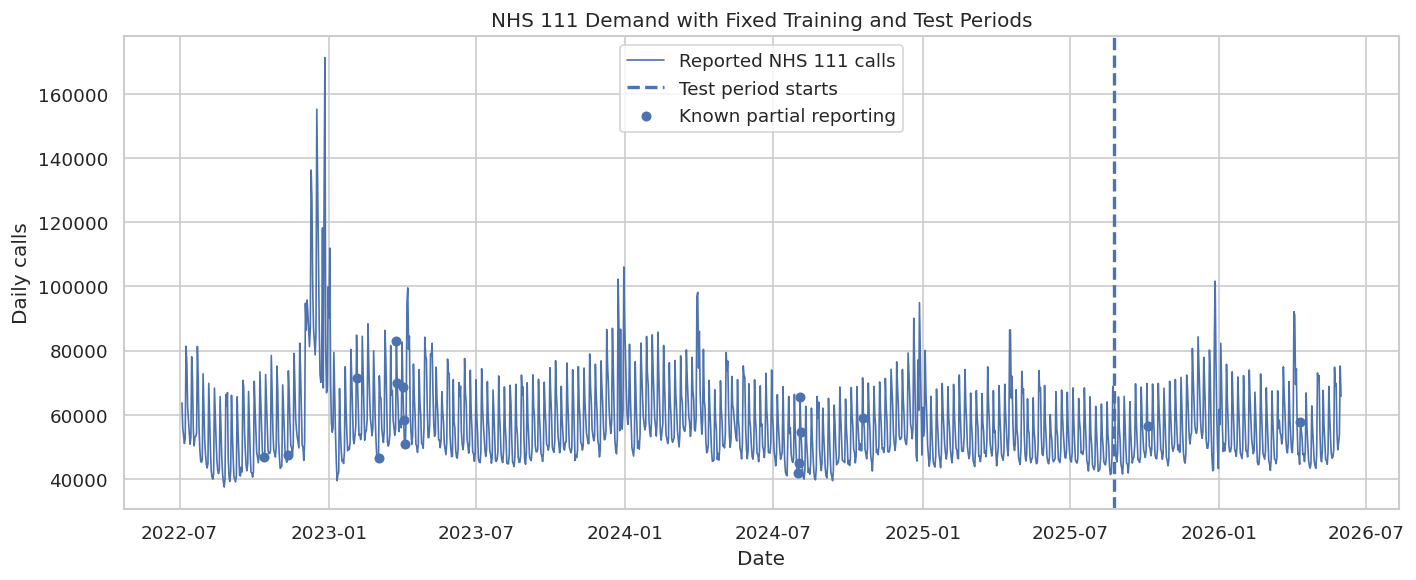

In [29]:
# Visualise the fixed train and test periods

plt.figure(figsize=(12, 5))
plt.plot(merged_data["Date"], merged_data["reported_A01"], linewidth=1, label="Reported NHS 111 calls")
plt.axvline(test_start, linestyle="--", linewidth=2, label="Test period starts")
partial_dates = merged_data[merged_data["partial_reporting"] == 1]
plt.scatter(partial_dates["Date"], partial_dates["reported_A01"], s=25, label="Known partial reporting")
plt.title("NHS 111 Demand with Fixed Training and Test Periods")
plt.xlabel("Date")
plt.ylabel("Daily calls")
plt.legend()
plt.tight_layout()
plt.savefig(Figures / "08_train_test_timeline.png", dpi=180, bbox_inches="tight")
plt.show()

### **What the split means**

The training period ends on 24 August 2025 and the final 280 days are held out for testing. There are 14 known partial-reporting dates in training and 2 in the test period.

The two test dates remain in the timeline, but they are not used when final error metrics are calculated. Every model is scored on the same 278 complete test dates.

# **10. Training-Only Time Series EDA**

The next checks use the training period only.
The purpose is to understand how NHS 111 demand behaves before choosing how to model it.

## **10.1 Training Demand Over Time**

The training series is plotted first to identify recurring patterns and unusually high-demand periods.

Training target summary:


,count,mean,std,min,25%,50%,75%,max
model_A01,1134.0,57241.9,13537.1,37443.0,48021.25,53544.0,63866.25,171371.0


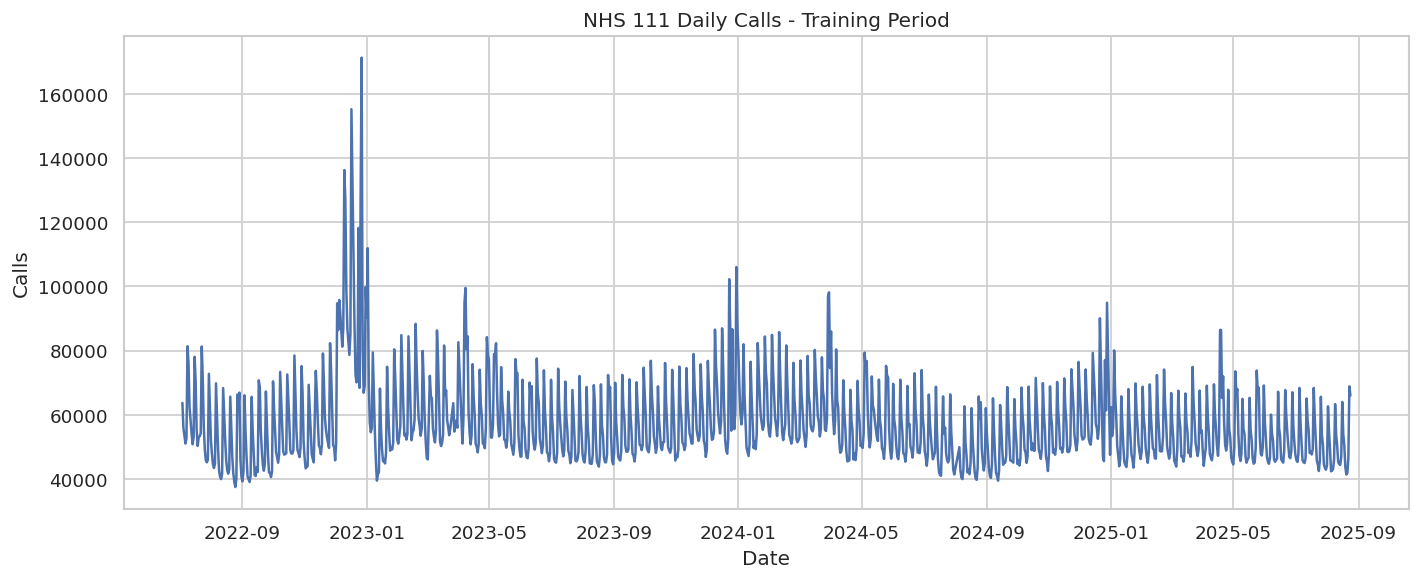

In [30]:
# Use only trustworthy training target values

eda_train = train_raw[train_raw["model_A01"].notna()].copy()
eda_train["day_of_week"] = eda_train["Date"].dt.dayofweek
eda_train["month"] = eda_train["Date"].dt.month

print("Training target summary:")
display(eda_train["model_A01"].describe().to_frame().T.round(2))

plt.figure(figsize=(12, 5))
plt.plot(eda_train["Date"], eda_train["model_A01"])
plt.title("NHS 111 Daily Calls - Training Period")
plt.xlabel("Date")
plt.ylabel("Calls")
plt.tight_layout()
plt.savefig(Figures / "01_training_calls.png", dpi=180, bbox_inches="tight")
plt.show()

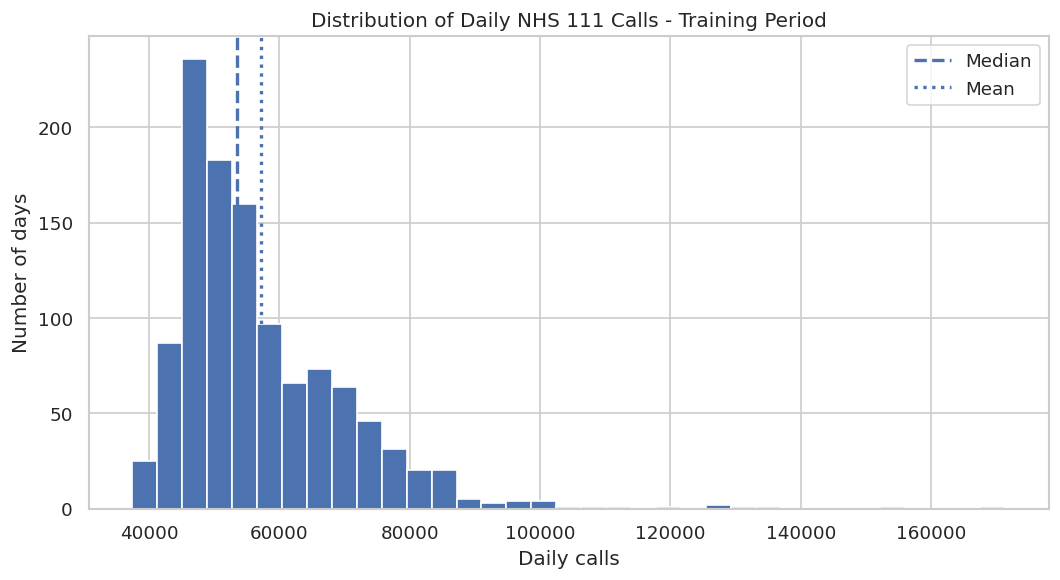

In [31]:
# Distribution of trustworthy training targets

plt.figure(figsize=(9, 5))
plt.hist(eda_train["model_A01"], bins=35)
plt.axvline(eda_train["model_A01"].median(), linestyle="--", linewidth=2, label="Median")
plt.axvline(eda_train["model_A01"].mean(), linestyle=":", linewidth=2, label="Mean")
plt.title("Distribution of Daily NHS 111 Calls - Training Period")
plt.xlabel("Daily calls")
plt.ylabel("Number of days")
plt.legend()
plt.tight_layout()
plt.savefig(Figures / "09_training_target_distribution.png", dpi=180, bbox_inches="tight")
plt.show()

### **What the demand distribution shows**

The training target has a mean of about **57,242 calls** and a median of about **53,544 calls**. The maximum is **171,371 calls**.

The upper tail contains a small number of very high-demand days. Those days are investigated because they may be genuine periods of NHS pressure.

## **10.2 Weekly and Monthly Patterns**

NHS 111 demand may differ by weekday and season. These summaries are descriptive only and use the training period.

,day_of_week,mean,median,std
0,0,59768.68,56378.0,11500.97
1,1,51975.98,49568.0,12311.90
2,2,49338.02,48175.5,6812.41
3,3,48335.42,46955.5,6407.05
4,4,51484.00,49642.0,8460.00
5,5,75171.05,72374.0,11997.60
6,6,64839.83,62694.0,10551.97


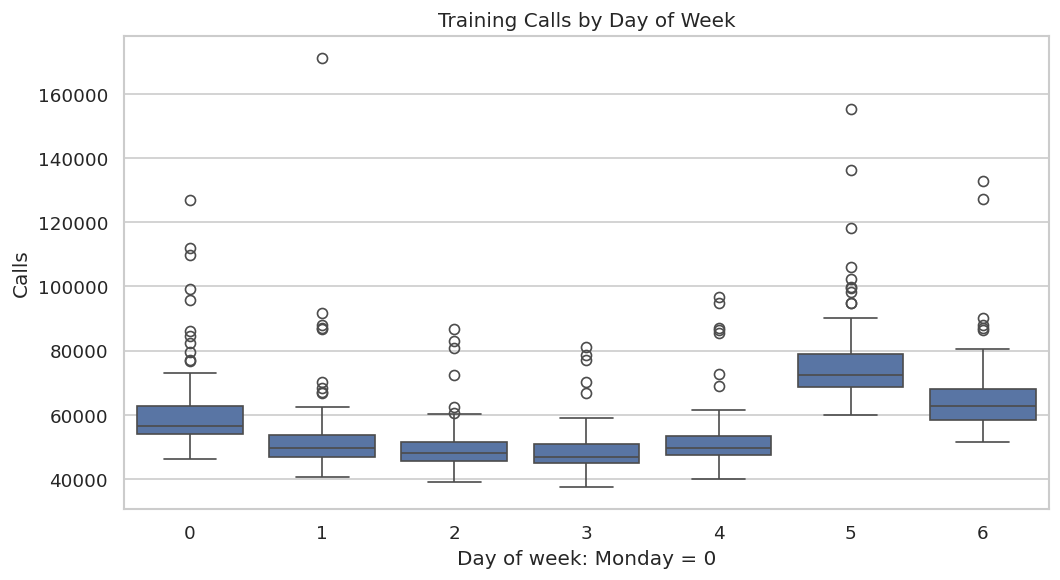

,month,mean,median,std
0,1,58166.37,55868.0,12786.17
1,2,59376.45,55700.0,10788.92
2,3,59367.43,55937.5,11125.18
3,4,59052.09,55080.0,12895.48
4,5,58037.89,53906.0,10501.40
5,6,54181.93,50757.5,8543.58
6,7,53686.36,51016.0,9456.27
7,8,50320.01,46646.0,9240.49
8,9,51092.82,48362.0,9401.50
9,10,55098.90,50988.0,9358.02


In [32]:
# Weekday pattern

weekday_summary = eda_train.groupby("day_of_week")["model_A01"].agg(["mean", "median", "std"]).reset_index()
display(weekday_summary.round(2))

plt.figure(figsize=(9, 5))
sns.boxplot(data=eda_train, x="day_of_week", y="model_A01")
plt.title("Training Calls by Day of Week")
plt.xlabel("Day of week: Monday = 0")
plt.ylabel("Calls")
plt.tight_layout()
plt.savefig(Figures / "02_weekday_pattern.png", dpi=180, bbox_inches="tight")
plt.show()

# Monthly pattern

monthly_summary = eda_train.groupby("month")["model_A01"].agg(["mean", "median", "std"]).reset_index()
display(monthly_summary.round(2))
monthly_summary.to_csv(Saved_Outputs / "training_monthly_summary.csv", index=False)

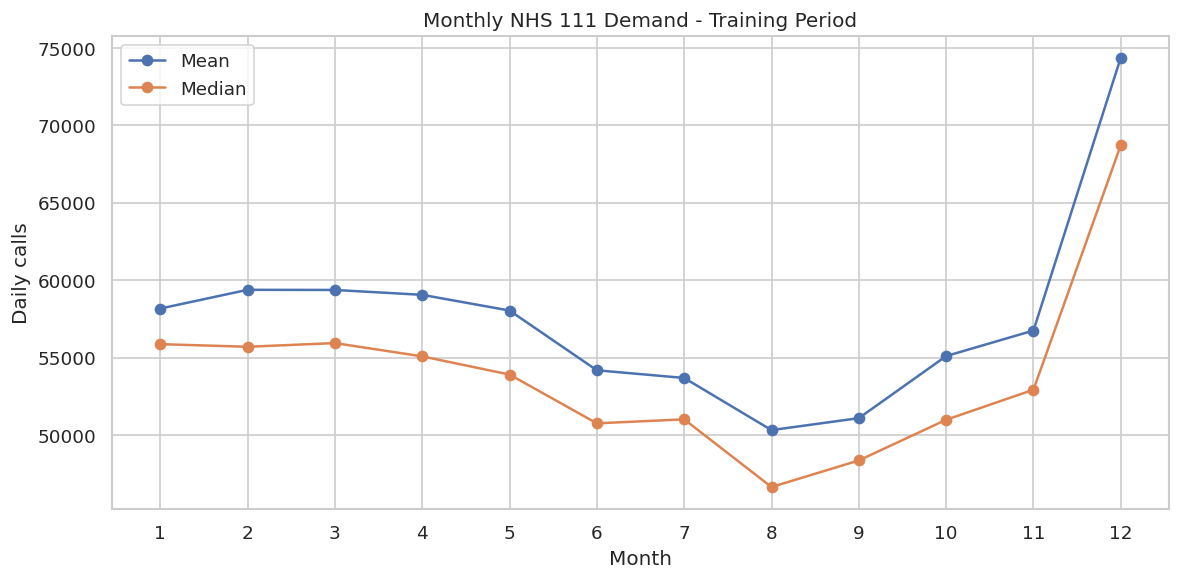

In [33]:
# Monthly demand profile

plt.figure(figsize=(10, 5))
plt.plot(monthly_summary["month"], monthly_summary["mean"], marker="o", label="Mean")
plt.plot(monthly_summary["month"], monthly_summary["median"], marker="o", label="Median")
plt.xticks(range(1, 13))
plt.title("Monthly NHS 111 Demand - Training Period")
plt.xlabel("Month")
plt.ylabel("Daily calls")
plt.legend()
plt.tight_layout()
plt.savefig(Figures / "10_monthly_demand_profile.png", dpi=180, bbox_inches="tight")
plt.show()

### **What the weekly and monthly patterns show**

Demand has a clear weekly pattern. Saturday has the highest average demand at about **75,171 calls**, followed by Sunday at about **64,840 calls**. Thursday is the lowest at about **48,335 calls**.

December has the highest monthly average at about **74,361 calls**. August is much lower at about **50,320 calls**. These patterns support weekly lags and calendar features.

## **10.3 STL Decomposition**

STL separates the training series into trend, weekly seasonality and residual variation. A seven-day period is used because the data is daily and NHS 111 demand is expected to follow a weekly cycle.

The few partial-reporting dates are interpolated **only for this diagnostic plot**. The interpolated values are not used as modelling targets.

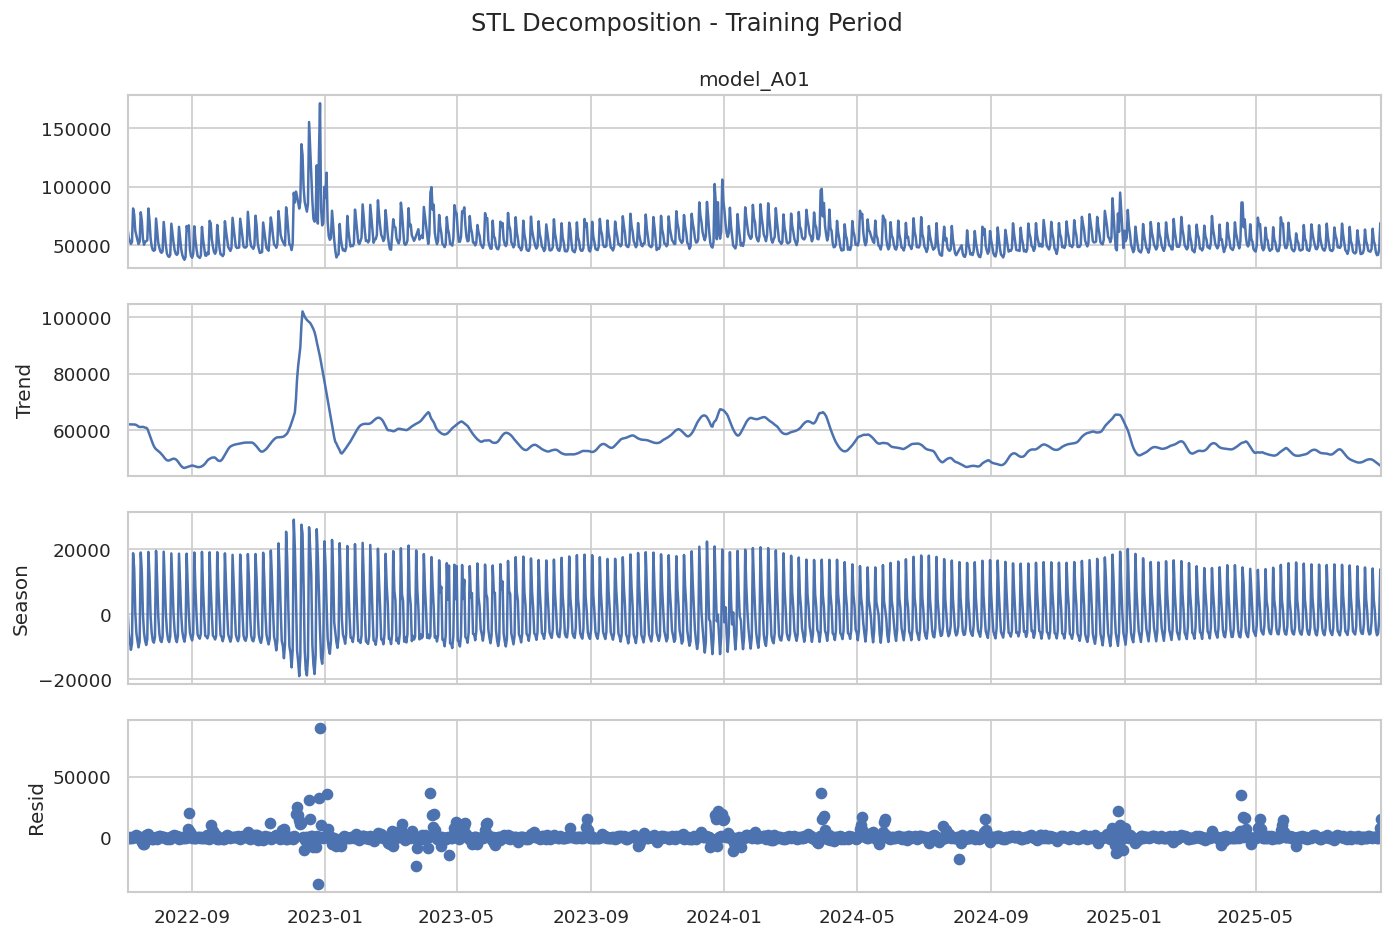

In [34]:
# Create a complete training series for decomposition only

stl_series = train_raw.set_index("Date")["model_A01"].asfreq("D")
stl_series = stl_series.interpolate(method="time")

stl_result = STL(stl_series, period=7, robust=True).fit()
fig = stl_result.plot()
fig.set_size_inches(12, 8)
fig.suptitle("STL Decomposition - Training Period", y=1.01)
fig.savefig(Figures / "03_stl_training.png", dpi=180, bbox_inches="tight")
plt.show()

## **10.4 Autocorrelation**

ACF and PACF are used to see how strongly current demand is related to earlier days. Strong values at lag 7 and its multiples would support weekly lag features and weekly seasonality in the statistical models.

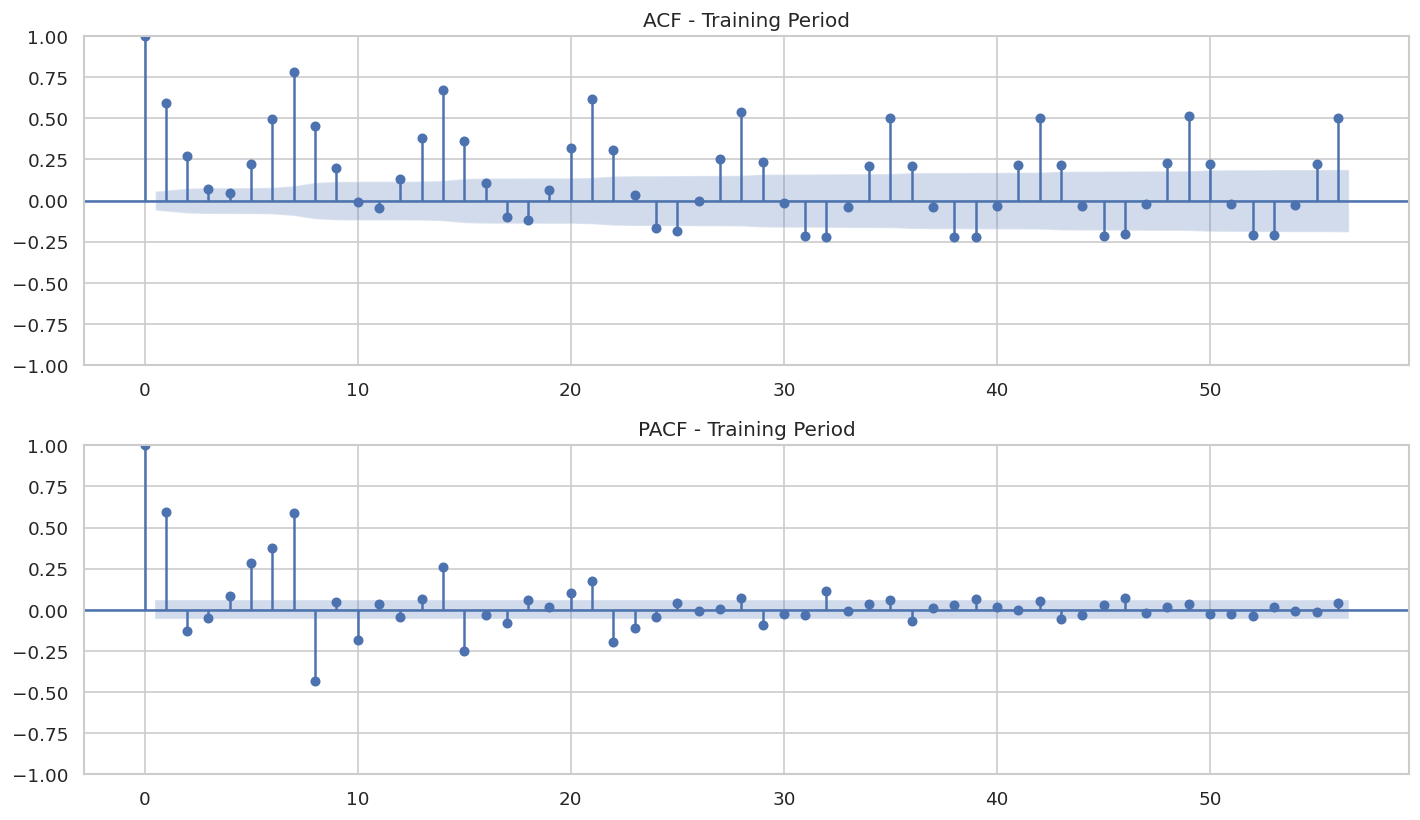

In [35]:
# ACF and PACF on training data

fig, axes = plt.subplots(2, 1, figsize=(12, 7))
plot_acf(stl_series, lags=56, ax=axes[0])
plot_pacf(stl_series, lags=56, ax=axes[1], method="ywm")
axes[0].set_title("ACF - Training Period")
axes[1].set_title("PACF - Training Period")
fig.tight_layout()
fig.savefig(Figures / "04_acf_pacf_training.png", dpi=180, bbox_inches="tight")
plt.show()

## **10.5 Stationarity Tests**

ADF and KPSS test stationarity from different directions, so they can disagree.

In [36]:
# Run ADF and KPSS

def stationarity_test(name, series):
    series = pd.Series(series).dropna()
    adf_result = adfuller(series, autolag="AIC")
    kpss_result = kpss(series, regression="c", nlags="auto")
    return [name, adf_result[0], adf_result[1], kpss_result[0], kpss_result[1]]

stationarity_results = pd.DataFrame([
    stationarity_test("Raw training series", stl_series),
    stationarity_test("First difference", stl_series.diff()),
    stationarity_test("Seven-day difference", stl_series.diff(7))
], columns=["series", "ADF_stat", "ADF_p", "KPSS_stat", "KPSS_p"])

display(stationarity_results.round(4))
stationarity_results.to_csv(Saved_Outputs / "stationarity_tests.csv", index=False)

/tmp/ipykernel_11470/855030123.py:6: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_result = kpss(series, regression="c", nlags="auto")
/tmp/ipykernel_11470/855030123.py:6: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result = kpss(series, regression="c", nlags="auto")
/tmp/ipykernel_11470/855030123.py:6: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result = kpss(series, regression="c", nlags="auto")


,series,ADF_stat,ADF_p,KPSS_stat,KPSS_p
0,Raw training series,-4.9057,0.0,1.0056,0.01
1,First difference,-7.8871,0.0,0.0297,0.10
2,Seven-day difference,-7.4567,0.0,0.0131,0.10


### **What the stationarity tests show**

The raw series gives different messages from ADF and KPSS. ADF rejects a unit root, while KPSS rejects level stationarity. The series has strong repeating structure, but its level is not completely stable over time.

After first differencing and seven-day differencing, ADF remains significant and KPSS no longer rejects stationarity. This supports testing differenced SARIMAX structures with weekly seasonality.

## **10.6 Extreme Demand and Change Point Check**

Very large demand spikes can affect model fitting and error metrics. They are identified but not removed immediately because they may represent genuine NHS demand.

A Pettitt change-point test is also applied to the training series to identify a possible shift in the overall level of demand.

In [37]:
# Identify the largest training days

extreme_days = eda_train.nlargest(15, "model_A01")[["Date", "model_A01"]].copy()
print("Highest demand days in training:")
display(extreme_days)

extreme_days.to_csv(Saved_Outputs / "training_extreme_days.csv", index=False)

# Pettitt change-point test

def pettitt_test(series, dates):
    values = pd.Series(series).dropna().to_numpy()
    valid_dates = pd.Series(dates).iloc[:len(values)].reset_index(drop=True)
    n = len(values)
    ranks = stats.rankdata(values)
    u = 2 * np.cumsum(ranks) - np.arange(1, n + 1) * (n + 1)
    location = int(np.argmax(np.abs(u)))
    statistic = float(np.abs(u[location]))
    p_value = min(2 * np.exp((-6 * statistic ** 2) / (n ** 3 + n ** 2)), 1.0)
    return valid_dates.iloc[location], statistic, p_value

change_date, change_stat, change_p = pettitt_test(stl_series.values, stl_series.index)

print("Possible change date:", change_date)
print("Pettitt statistic:", round(change_stat, 2))
print("P-value:", round(change_p, 6))

change_result = pd.DataFrame({"change_date": [change_date], "statistic": [change_stat], "p_value": [change_p]})
change_result.to_csv(Saved_Outputs / "pettitt_change_point.csv", index=False)

Highest demand days in training:


,Date,model_A01
176,2022-12-27,171371.0
166,2022-12-17,155301.0
159,2022-12-10,136316.0
167,2022-12-18,133001.0
160,2022-12-11,127238.0
175,2022-12-26,127077.0
173,2022-12-24,118266.0
182,2023-01-02,111951.0
168,2022-12-19,109873.0
544,2023-12-30,106062.0


Possible change date: 2024-05-28 00:00:00
Pettitt statistic: 90097.0
P-value: 0.0


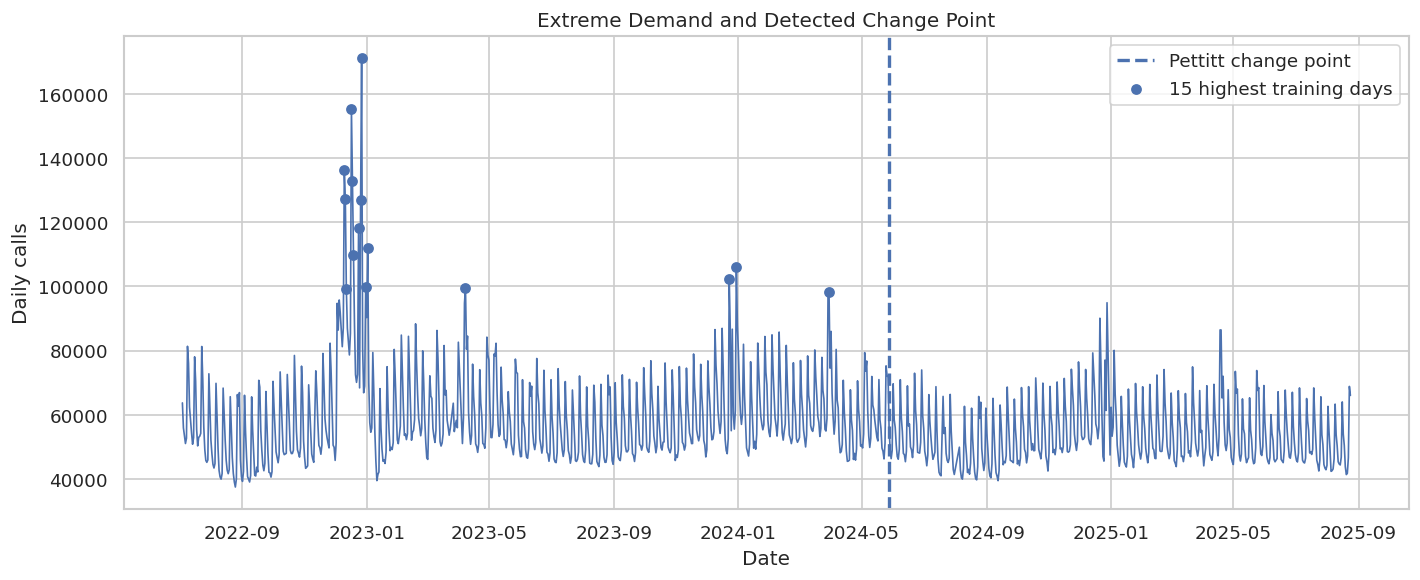

Mean before change point: 59717.91
Mean after change point: 53450.53


In [38]:
# Show the extreme period and detected level change

change_before = eda_train[eda_train["Date"] <= change_date]["model_A01"].mean()
change_after = eda_train[eda_train["Date"] > change_date]["model_A01"].mean()

plt.figure(figsize=(12, 5))
plt.plot(eda_train["Date"], eda_train["model_A01"], linewidth=1)
plt.axvline(change_date, linestyle="--", linewidth=2, label="Pettitt change point")
plt.scatter(extreme_days["Date"], extreme_days["model_A01"], s=30, label="15 highest training days")
plt.title("Extreme Demand and Detected Change Point")
plt.xlabel("Date")
plt.ylabel("Daily calls")
plt.legend()
plt.tight_layout()
plt.savefig(Figures / "11_extreme_demand_change_point.png", dpi=180, bbox_inches="tight")
plt.show()

print("Mean before change point:", round(change_before, 2))
print("Mean after change point:", round(change_after, 2))

### **What the extreme-demand check shows**

The largest demand values are concentrated around December 2022 and early January 2023. The highest day is 27 December 2022 with **171,371 calls**.

The Pettitt test identifies a level change around **28 May 2024**. The later sensitivity analysis checks the December 2022 period before any decision is made about excluding it.

## **10.7 Weather, Flu and Bank Holiday Relationships**

Do temperature, flu and bank holidays seem related to NHS 111 call demand in the training data?

In [39]:
# Training-only descriptive relationships

relationship_data = eda_train[["model_A01", "temp_c", "flu_positivity", "bank_holiday"]].copy()

weather_corr = stats.spearmanr(relationship_data["model_A01"], relationship_data["temp_c"], nan_policy="omit")
flu_corr = stats.spearmanr(relationship_data["model_A01"], relationship_data["flu_positivity"], nan_policy="omit")

relationship_summary = pd.DataFrame({
    "factor": ["Temperature", "Flu positivity"],
    "spearman_r": [weather_corr.statistic, flu_corr.statistic],
    "p_value": [weather_corr.pvalue, flu_corr.pvalue]
})

display(relationship_summary.round(4))

holiday_summary = eda_train.groupby("bank_holiday")["model_A01"].agg(["count", "mean", "median"]).reset_index()
print("Bank holiday comparison:")
display(holiday_summary.round(2))

relationship_summary.to_csv(Saved_Outputs / "training_factor_correlations.csv", index=False)
holiday_summary.to_csv(Saved_Outputs / "training_bank_holiday_summary.csv", index=False)

,factor,spearman_r,p_value
0,Temperature,-0.2496,0.0
1,Flu positivity,0.2549,0.0


Bank holiday comparison:


,bank_holiday,count,mean,median
0,0,1108,56681.88,53309.0
1,1,26,81107.54,76895.0


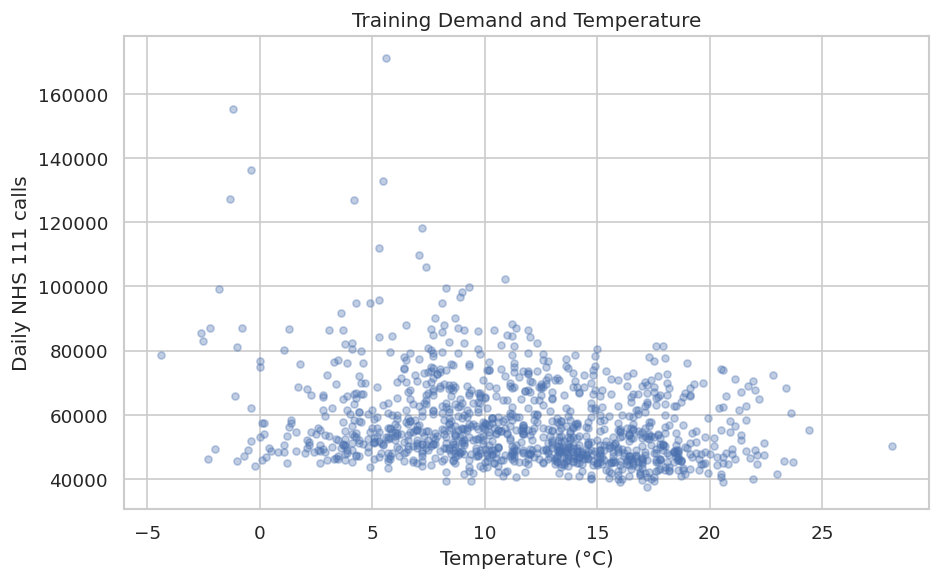

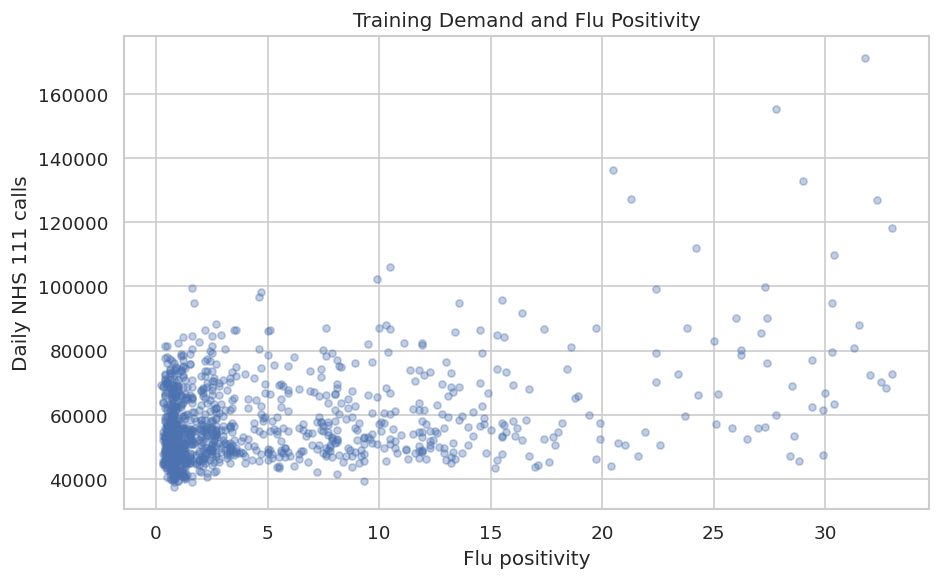

In [40]:
# Temperature relationship

plt.figure(figsize=(8, 5))
plt.scatter(eda_train["temp_c"], eda_train["model_A01"], alpha=0.35, s=18)
plt.title("Training Demand and Temperature")
plt.xlabel("Temperature (°C)")
plt.ylabel("Daily NHS 111 calls")
plt.tight_layout()
plt.savefig(Figures / "12_demand_temperature.png", dpi=180, bbox_inches="tight")
plt.show()

# Flu relationship

plt.figure(figsize=(8, 5))
plt.scatter(eda_train["flu_positivity"], eda_train["model_A01"], alpha=0.35, s=18)
plt.title("Training Demand and Flu Positivity")
plt.xlabel("Flu positivity")
plt.ylabel("Daily NHS 111 calls")
plt.tight_layout()
plt.savefig(Figures / "13_demand_flu.png", dpi=180, bbox_inches="tight")
plt.show()

### **What the external-factor checks show**

Temperature has a Spearman weak correlation of about **-0.25** with call demand. Colder periods tend to be associated with higher demand.

Flu positivity has a weak correlation of about **0.25** with demand. Higher flu activity tends to occur with higher NHS 111 demand.

Both correlations were statistically significant, although their magnitudes were small.

Bank holidays show a much larger descriptive difference. Training bank holidays average about **81,108 calls**, compared with about **56,682 calls** on other days.

# **11. Leakage-Safe Feature Engineering**

The feature set is expanded only where there is a clear forecasting reason. The aim is not to create many columns for their own sake.

Each feature below answers a specific question:

- **Recent demand:** does yesterday or the last few days carry forward into tomorrow?
- **Weekly repetition:** does the same weekday in previous weeks help predict tomorrow?
- **Recent level and volatility:** is demand currently running above or below its recent baseline, and has it become unstable?
- **Calendar pattern:** do weekday, weekend and annual seasonal cycles affect demand?
- **Holiday timing:** does demand change on a bank holiday, immediately around a bank holiday, or around the Christmas and New Year period?
- **Weather:** do recent temperature level and weekly temperature conditions add useful information?
- **Influenza:** does lagged flu activity, allowing for publication delay, improve the forecast?

Only information available before the forecast date is used. Same-day observed temperature, same-day flu values and retrospective reporting-quality measures are excluded from the model.

In [41]:
# Prepare the modelling dataset

model_data = merged_data.copy()
model_data["model_A01"] = model_data["reported_A01"].where(model_data["partial_reporting"] == 0)
model_data["history_A01"] = model_data["model_A01"]

# Calendar structure known in advance

model_data["day_of_week"] = model_data["Date"].dt.dayofweek
model_data["month"] = model_data["Date"].dt.month  # descriptive error analysis only
model_data["is_weekend"] = (model_data["day_of_week"] >= 5).astype(int)
model_data["day_of_year"] = model_data["Date"].dt.dayofyear
model_data["doy_sin"] = np.sin(2 * np.pi * model_data["day_of_year"] / 365.25)
model_data["doy_cos"] = np.cos(2 * np.pi * model_data["day_of_year"] / 365.25)
model_data["trend_index"] = np.arange(len(model_data))

# Bank-holiday timing known in advance

holiday_dates = pd.to_datetime(bank_holidays["Date"])
model_data["day_before_holiday"] = model_data["Date"].isin(holiday_dates - pd.Timedelta(days=1)).astype(int)
model_data["day_after_holiday"] = model_data["Date"].isin(holiday_dates + pd.Timedelta(days=1)).astype(int)

# Christmas and New Year periods test whether demand changes around the festive period

month = model_data["Date"].dt.month
day = model_data["Date"].dt.day
model_data["pre_christmas"] = ((month == 12) & (day >= 18) & (day <= 23)).astype(int)
model_data["christmas_eve"] = ((month == 12) & (day == 24)).astype(int)
model_data["christmas_day"] = ((month == 12) & (day == 25)).astype(int)
model_data["boxing_day"] = ((month == 12) & (day == 26)).astype(int)
model_data["post_christmas"] = ((month == 12) & (day >= 27) & (day <= 30)).astype(int)
model_data["new_year_eve"] = ((month == 12) & (day == 31)).astype(int)
model_data["new_year_day"] = ((month == 1) & (day == 1)).astype(int)

# Easter period: Good Friday through Easter Monday

good_friday_dates = pd.to_datetime(bank_holidays[bank_holidays["holiday_name"].str.contains("Good Friday", case=False, na=False)]["Date"])
easter_period_dates = []

for good_friday in good_friday_dates:
    for offset in range(4):
        easter_period_dates.append(good_friday + pd.Timedelta(days=offset))

model_data["easter_period"] = model_data["Date"].isin(easter_period_dates).astype(int)

# Recent demand: immediate persistence and weekly recurrence

history_lags = [1, 2, 3, 7, 14, 21, 28]

for lag in history_lags:
    model_data[f"lag_{lag}"] = model_data["history_A01"].shift(lag)

# Recent demand level and volatility

for window in [7, 14, 28]:
    model_data[f"rolling_mean_{window}"] = model_data["history_A01"].shift(1).rolling(window).mean()

for window in [7, 14]:
    model_data[f"rolling_std_{window}"] = model_data["history_A01"].shift(1).rolling(window).std()

# Weekly movement: yesterday compared with the same weekday one week earlier

model_data["weekly_change"] = model_data["lag_1"] - model_data["history_A01"].shift(8)

# Weather known before the forecast date

model_data["temp_lag_1"] = model_data["temp_c"].shift(1)
model_data["temp_lag_7"] = model_data["temp_c"].shift(7)
model_data["temp_rolling_mean_7"] = model_data["temp_c"].shift(1).rolling(7).mean()

# Flu with a conservative reporting delay

model_data["flu_lag_7"] = model_data["flu_positivity"].shift(7)  # sensitivity only
model_data["flu_lag_14"] = model_data["flu_positivity"].shift(14)
model_data["flu_lag_21"] = model_data["flu_positivity"].shift(21)
model_data["flu_trend"] = model_data["flu_lag_14"] - model_data["flu_lag_21"]

# The longest demand history feature needs 28 earlier days

model_start = model_data["Date"].min() + pd.Timedelta(days=28)
model_data = model_data[model_data["Date"] >= model_start].reset_index(drop=True)

print("Modelling period:", model_data["Date"].min(), "to", model_data["Date"].max())
print("Rows:", len(model_data))

Modelling period: 2022-08-01 00:00:00 to 2026-05-31 00:00:00
Rows: 1400


### **Why these features were created**

The features were created based on patterns identified during the training only exploratory analysis and their relevance to one day ahead forecasting. Demand lags of 1, 2 and 3 days were created to capture the influence of recent call levels. Lags of 7, 14, 21 and 28 days were added because the ACF, PACF and weekday analysis showed a strong weekly pattern in NHS 111 demand. Rolling means over 7, 14 and 28 days were created to represent the recent average level of demand. Rolling standard deviations over 7 and 14 days were used to measure recent changes in demand variability. `weekly_change` was also created to compare recent demand with the equivalent period one week earlier.

Calendar features included `day_of_week`, `is_weekend`, annual seasonality using `doy_sin` and `doy_cos`, and `trend_index` to represent changes in demand over time. Holiday features were included because bank holidays showed higher call demand and the exploratory analysis identified unusually high demand around Christmas and New Year. Separate indicators were therefore created for bank holidays, days before and after holidays, Christmas periods, New Year and Easter.

Temperature features included `temp_lag_1`, `temp_lag_7` and `temp_rolling_mean_7` because temperature showed a relationship with call demand. Flu features included `flu_lag_14`, `flu_lag_21` and `flu_trend` because flu positivity was also associated with demand. Lagged flu values were used to allow for possible reporting delays.

To prevent data leakage, all demand and rolling features used information from earlier dates only. Same day observed temperature, same day flu positivity, the target value and NHS reporting quality variables were excluded from the forecasting inputs.

In [42]:
# Define meaningful candidate feature groups

history_features = [
    "lag_1", "lag_2", "lag_3", "lag_7", "lag_14", "lag_21", "lag_28",
    "rolling_mean_7", "rolling_mean_14", "rolling_mean_28",
    "rolling_std_7", "rolling_std_14", "weekly_change"
]

calendar_features = [
    "day_of_week", "is_weekend", "doy_sin", "doy_cos", "trend_index", "bank_holiday",
    "day_before_holiday", "day_after_holiday", "pre_christmas", "christmas_eve",
    "christmas_day", "boxing_day", "post_christmas", "new_year_eve", "new_year_day", "easter_period"
]

weather_features = ["temp_lag_1", "temp_lag_7", "temp_rolling_mean_7"]
flu_features = ["flu_lag_14", "flu_lag_21", "flu_trend"]

candidate_features = history_features + calendar_features + weather_features + flu_features

# Classical models use a smaller regressor set to keep them stable and interpretable

sarimax_features = [
    "is_weekend", "bank_holiday", "doy_sin", "doy_cos", "trend_index",
    "temp_lag_1", "temp_rolling_mean_7", "flu_lag_14"
]

prophet_regressors = ["temp_lag_1", "temp_rolling_mean_7", "flu_lag_14"]

quality_only = [
    "contracts_reporting", "contracts_missing", "contracts_zero",
    "coverage_pct", "partial_reporting", "known_coverage_gap"
]

forbidden = ["reported_A01", "model_A01", "history_A01", "temp_c", "flu_positivity"] + quality_only

print("Candidate ML features:", len(candidate_features))
print("Forbidden columns accidentally included:", sorted(set(candidate_features).intersection(forbidden)))
print("Demand history features:", len(history_features))
print("Calendar and holiday features:", len(calendar_features))
print("Weather features:", len(weather_features))
print("Flu features:", len(flu_features))

Candidate ML features: 35
Forbidden columns accidentally included: []
Demand history features: 13
Calendar and holiday features: 16
Weather features: 3
Flu features: 3


### **Feature dictionary and purpose**

| Feature | Reason for inclusion |
| --- | --- |
| `lag_1`, `lag_2`, `lag_3` | Short-term persistence in call demand |
| `lag_7`, `lag_14`, `lag_21`, `lag_28` | Weekly recurrence over one to four weeks |
| `rolling_mean_7`, `rolling_mean_14`, `rolling_mean_28` | Recent demand level |
| `rolling_std_7`, `rolling_std_14` | Recent volatility in demand |
| `weekly_change` | Change from the same weekday one week earlier |
| `day_of_week`, `is_weekend` | Weekly service-use pattern |
| `doy_sin`, `doy_cos` | Smooth annual seasonality |
| `trend_index` | Long-term change in demand level |
| `bank_holiday` | Public-holiday effect |
| `day_before_holiday`, `day_after_holiday` | Possible demand displacement around holidays |
| `pre_christmas` | Tests 18 to 23 December |
| `christmas_eve` | Tests 24 December separately |
| `christmas_day` | Tests 25 December separately |
| `boxing_day` | Tests 26 December separately |
| `post_christmas` | Tests 27 to 30 December |
| `new_year_eve` | Tests 31 December |
| `new_year_day` | Tests 1 January |
| `easter_period` | Tests Good Friday through Easter Monday |
| `temp_lag_1` | Most recent observed temperature |
| `temp_lag_7` | Temperature aligned with the weekly cycle |
| `temp_rolling_mean_7` | Sustained recent temperature conditions |
| `flu_lag_14`, `flu_lag_21` | Delayed influenza surveillance signal |
| `flu_trend` | Direction of change in influenza activity |

`month` is retained only for descriptive error analysis. It is not a model feature.

### **Candidate feature check**

The candidate set is deliberately limited to features with a direct forecasting interpretation. The leakage check must return an empty list.

Feature selection is used to remove redundant **demand-history** variables. Calendar, holiday, weather and flu variables are retained because they directly answer the research question and some holiday features are rare enough that an automatic importance filter could remove them simply because few examples occur in one screening fold.

### **Decision**

The reporting-quality variables remain in the dataset but are excluded from all forecasting models. They are known only after reporting occurs and would therefore be unavailable at prediction time.

The main modelling features use lagged demand, known calendar information, past temperature and conservatively lagged flu positivity.

# **12. Walk-Forward Validation Design and Forecast Metrics**

This project predicts the **number of NHS 111 calls**, which is a continuous numerical target. It is therefore a **regression and time-series forecasting problem**.

ROC-AUC and PR-AUC are not used because they evaluate classification performance. Using them would require changing daily call demand into artificial classes such as "high" and "low" demand, which would change the research question and discard information from the original continuous target.

Forecast performance is evaluated using:

- **Mean Error (ME)** to check systematic forecast bias;
- **MAE** as the main interpretable error measure in calls;
- **RMSE** to penalise large misses more strongly;
- **R²** as a supporting measure of explained variation;
- **MASE** using a seven-day seasonal-naive denominator;
- **RMSSE** as the squared-error scaled equivalent;
- **WAPE** to express total absolute forecast error as a percentage of observed call volume.

MASE and RMSSE below 1 indicate performance better than the corresponding seasonal-naive error scale.

In [43]:
# Training and test modelling calendars

train_calendar = model_data[model_data["Date"] < test_start].reset_index(drop=True)
test_calendar = model_data[model_data["Date"] >= test_start].reset_index(drop=True)

# Final model-comparison folds: the latest five training-period windows

tscv = TimeSeriesSplit(n_splits=5, test_size=56)
cv_splits = list(tscv.split(train_calendar))

fold_dates = []

for fold, (train_idx, val_idx) in enumerate(cv_splits, start=1):
    fold_dates.append([
        fold,
        train_calendar.iloc[train_idx]["Date"].min(),
        train_calendar.iloc[train_idx]["Date"].max(),
        train_calendar.iloc[val_idx]["Date"].min(),
        train_calendar.iloc[val_idx]["Date"].max()
    ])

fold_dates = pd.DataFrame(
    fold_dates,
    columns=["fold", "train_start", "train_end", "validation_start", "validation_end"]
)

# Earlier data are used for feature screening and hyperparameter tuning

comparison_start = cv_splits[0][1][0]
precomparison_calendar = train_calendar.iloc[:comparison_start].reset_index(drop=True)

tuning_tscv = TimeSeriesSplit(n_splits=3, test_size=56)
tuning_splits = list(tuning_tscv.split(precomparison_calendar))

feature_selection_end = tuning_splits[0][1][0]
feature_selection_calendar = precomparison_calendar.iloc[:feature_selection_end].reset_index(drop=True)

feature_tscv = TimeSeriesSplit(n_splits=3, test_size=42)
feature_splits = list(feature_tscv.split(feature_selection_calendar))

display(fold_dates)

print("Feature-screening data ends:", feature_selection_calendar["Date"].max())
print("Hyperparameter-tuning validation begins:", precomparison_calendar.iloc[tuning_splits[0][1][0]]["Date"])
print("Model-comparison validation begins:", train_calendar.iloc[cv_splits[0][1][0]]["Date"])
print("Held-out test begins:", test_calendar["Date"].min())

fold_dates.to_csv(Saved_Outputs / "walk_forward_folds.csv", index=False)

,fold,train_start,train_end,validation_start,validation_end
0,1,2022-08-01,2024-11-17,2024-11-18,2025-01-12
1,2,2022-08-01,2025-01-12,2025-01-13,2025-03-09
2,3,2022-08-01,2025-03-09,2025-03-10,2025-05-04
3,4,2022-08-01,2025-05-04,2025-05-05,2025-06-29
4,5,2022-08-01,2025-06-29,2025-06-30,2025-08-24


Feature-screening data ends: 2024-06-02 00:00:00
Hyperparameter-tuning validation begins: 2024-06-03 00:00:00
Model-comparison validation begins: 2024-11-18 00:00:00
Held-out test begins: 2025-08-25 00:00:00


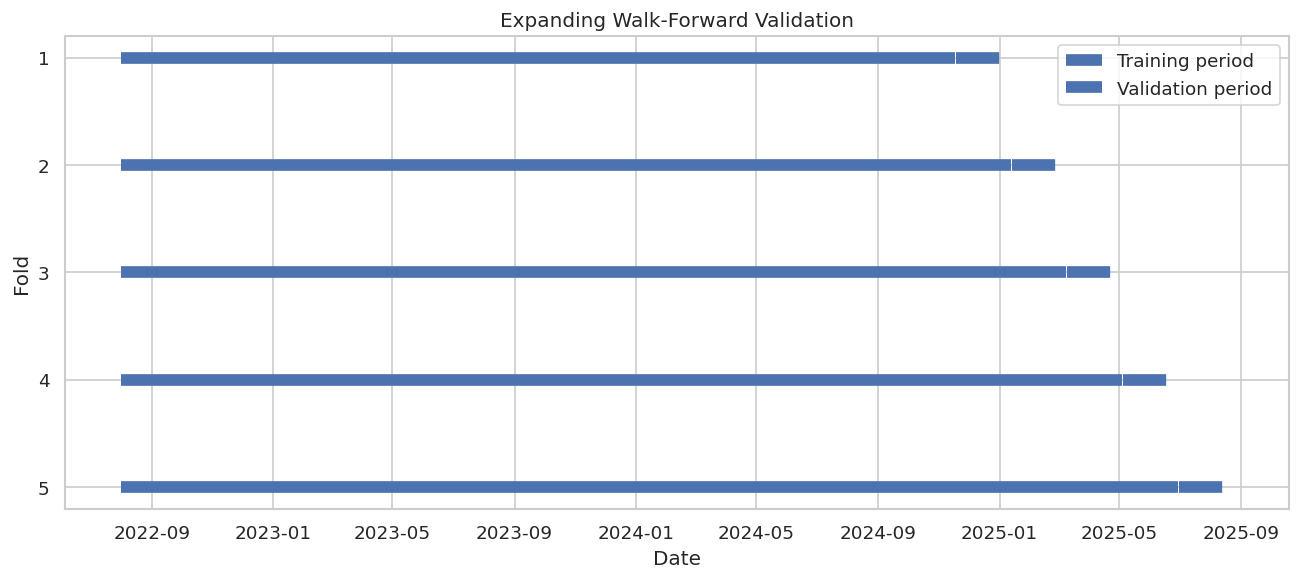

In [44]:
# Visualise the five walk-forward folds

plt.figure(figsize=(11, 5))

for _, row in fold_dates.iterrows():
    y = int(row["fold"])
    train_label = "Training period" if y == 1 else None
    val_label = "Validation period" if y == 1 else None
    plt.hlines(y, row["train_start"], row["train_end"], linewidth=7, label=train_label)
    plt.hlines(y, row["validation_start"], row["validation_end"], linewidth=7, linestyles="dashed", label=val_label)

plt.yticks(fold_dates["fold"])
plt.gca().invert_yaxis()
plt.title("Expanding Walk-Forward Validation")
plt.xlabel("Date")
plt.ylabel("Fold")
plt.legend()
plt.tight_layout()
plt.savefig(Figures / "14_walk_forward_folds.png", dpi=180, bbox_inches="tight")
plt.show()

### **Why the development stages are separated**

The training period now has three different jobs.

**Feature screening** uses the earliest validation windows. This decides which engineered predictors are worth carrying forward.

**Hyperparameter tuning** uses later training-period validation windows. This chooses settings for XGBoost, LightGBM and CatBoost after the feature set has been frozen.

**Model comparison** uses the latest five training-period validation windows. These folds have not been used to choose features or tune the boosting parameters.

The held-out test period comes after all three stages and remains the final generalisation check.

In [45]:
# Forecast accuracy metrics

def forecast_metrics(y_true, y_pred, mae_scale, mse_scale):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    error = y_true - y_pred
    me = np.mean(error)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    r2 = r2_score(y_true, y_pred)
    mase = mae / mae_scale if mae_scale > 0 else np.nan
    rmsse = rmse / (mse_scale ** 0.5) if mse_scale > 0 else np.nan
    denominator = np.abs(y_true).sum()
    wape = 100 * np.abs(error).sum() / denominator if denominator > 0 else np.nan
    return {"ME": me, "MAE": mae, "RMSE": rmse, "R2": r2, "MASE": mase, "RMSSE": rmsse, "WAPE_pct": wape}


def seasonal_scales(frame):
    seasonal_error = frame["model_A01"] - frame["model_A01"].shift(7)
    mae_scale = seasonal_error.abs().mean()
    mse_scale = (seasonal_error ** 2).mean()
    return mae_scale, mse_scale


## **12.1 Seasonal Naive Baseline**

A forecasting model must beat a simple baseline. The seasonal naive forecast uses the value from seven days earlier. If that value is unavailable because the earlier date had partial reporting, the median of the available 7, 14, 21 and 28-day lags is used.

In [46]:
# Seasonal naive walk-forward results

baseline_fold_rows = []
baseline_oof_rows = []

for fold, (train_idx, val_idx) in enumerate(cv_splits, start=1):
    fold_train = train_calendar.iloc[train_idx].copy()
    fold_val = train_calendar.iloc[val_idx].copy()
    mae_scale, mse_scale = seasonal_scales(fold_train)

    prediction = fold_val["lag_7"].copy()
    fallback = fold_val[["lag_7", "lag_14", "lag_21", "lag_28"]].median(axis=1)
    prediction = prediction.fillna(fallback)

    valid = fold_val["model_A01"].notna() & prediction.notna()
    metrics = forecast_metrics(fold_val.loc[valid, "model_A01"], prediction[valid], mae_scale, mse_scale)
    baseline_fold_rows.append({"fold": fold, "Model": "Seasonal Naive", **metrics})

    for date, actual, pred in zip(fold_val.loc[valid, "Date"], fold_val.loc[valid, "model_A01"], prediction[valid]):
        baseline_oof_rows.append({"fold": fold, "Date": date, "Model": "Seasonal Naive", "Actual": actual, "Predicted": pred})

baseline_fold = pd.DataFrame(baseline_fold_rows)
baseline_oof = pd.DataFrame(baseline_oof_rows)

display(baseline_fold.round(2))

,fold,Model,ME,MAE,RMSE,R2,MASE,RMSSE,WAPE_pct
0,1,Seasonal Naive,-307.46,5423.89,7772.06,0.56,1.06,0.81,9.03
1,2,Seasonal Naive,-130.95,2189.66,2907.11,0.88,0.43,0.31,4.10
2,3,Seasonal Naive,289.62,5598.66,9406.60,0.15,1.13,1.02,10.10
3,4,Seasonal Naive,-157.20,3941.02,5895.88,0.47,0.79,0.64,7.45
4,5,Seasonal Naive,-211.82,2076.25,2798.17,0.87,0.42,0.31,4.10


### **Seasonal Naive Baseline Results**

The seasonal naive baseline produced different results across the five validation folds. Fold 5 had the lowest MAE at 2,076 calls, followed by Fold 2 at 2,190 calls. These two folds also had high R² values of 0.87 and 0.88.

Fold 3 had the highest error, with an MAE of 5,599 calls and an RMSE of 9,407 calls. Its R² was also much lower at 0.15. The weekly pattern was therefore less effective for forecasting this period.

The Mean Error was close to zero in all five folds. Negative ME values in Folds 1, 2, 4 and 5 mean that the baseline predicted higher call volumes than were recorded on average. Fold 3 had a positive ME, meaning that it predicted lower call volumes on average.

The change in accuracy across the five folds confirms that forecasting performance was not the same throughout the training period. The seasonal naive model provides a useful benchmark for comparing the later forecasting models.

## **12.2 Additional Simple Baseline Check**

Two extra simple forecasts are calculated as a sanity check. The persistence forecast uses the previous day's demand. The second forecast averages the previous day and the same day one week earlier. These are not used to tune the machine learning models. They show how much accuracy can already be obtained from very recent demand alone.


In [47]:
# Additional simple baselines on the development folds

sanity_baseline_rows = []

for fold, (train_idx, val_idx) in enumerate(cv_splits, start=1):
    fold_train = train_calendar.iloc[train_idx].copy()
    fold_val = train_calendar.iloc[val_idx].copy()
    mae_scale, mse_scale = seasonal_scales(fold_train)
    fallback = fold_val[["lag_7", "lag_14", "lag_21", "lag_28"]].median(axis=1)

    persistence = fold_val["lag_1"].fillna(fallback)
    lag1_lag7 = fold_val[["lag_1", "lag_7"]].mean(axis=1).fillna(fallback)

    for name, prediction in {
        "Persistence Naive": persistence,
        "Lag1 Lag7 Average": lag1_lag7
    }.items():
        valid = fold_val["model_A01"].notna() & prediction.notna()
        metrics = forecast_metrics(fold_val.loc[valid, "model_A01"], prediction.loc[valid], mae_scale, mse_scale)
        sanity_baseline_rows.append({"fold": fold, "Model": name, **metrics})

sanity_baseline_fold = pd.DataFrame(sanity_baseline_rows)
sanity_baseline_summary = sanity_baseline_fold.groupby("Model")[["MAE", "RMSE", "R2", "WAPE_pct"]].mean().reset_index()

display(sanity_baseline_summary.round(3))
sanity_baseline_fold.to_csv(Saved_Outputs / "additional_simple_baselines.csv", index=False)


,Model,MAE,RMSE,R2,WAPE_pct
0,Lag1 Lag7 Average,4382.184,6275.396,0.545,7.981
1,Persistence Naive,7315.521,10113.564,-0.202,13.340


# **13. Classical Time Series Models**

SARIMAX and Prophet were included as established time series forecasting models. Their performance is compared with the machine learning models to assess whether the more complex models provide better forecasting accuracy.

## **13.1 Selecting a SARIMAX Structure**

A small number of SARIMAX configurations were tested using only the earliest training data. The model with the lowest AIC was selected and the same structure was then used throughout the later walk forward validation.

This kept the later validation periods and final test separate from the SARIMAX structure selection.

In [48]:
# Select SARIMAX order using only the earliest training fold

first_train_idx = cv_splits[0][0]
sarimax_selection = train_calendar.iloc[first_train_idx].set_index("Date").asfreq("D")

orders = [(1, 0, 1), (2, 0, 1), (1, 1, 1), (2, 1, 1)]
seasonal_orders = [(1, 0, 1, 7), (1, 1, 1, 7), (0, 1, 1, 7)]

sarimax_candidates = []

for order in orders:
    for seasonal_order in seasonal_orders:
        try:
            model = SARIMAX(sarimax_selection["model_A01"], exog=sarimax_selection[sarimax_features], order=order, seasonal_order=seasonal_order, trend="c", enforce_stationarity=False, enforce_invertibility=False)
            result = model.fit(disp=False, maxiter=500)
            converged = bool(result.mle_retvals.get("converged", False))
            sarimax_candidates.append([order, seasonal_order, result.aic, converged])
        except Exception:
            sarimax_candidates.append([order, seasonal_order, np.nan, False])

sarimax_candidates = pd.DataFrame(sarimax_candidates, columns=["order", "seasonal_order", "AIC", "converged"])
sarimax_candidates = sarimax_candidates.sort_values("AIC", na_position="last").reset_index(drop=True)

print("All SARIMAX candidates:")
display(sarimax_candidates)

valid_sarimax = sarimax_candidates[sarimax_candidates["converged"] & sarimax_candidates["AIC"].notna()].copy()

if len(valid_sarimax) == 0:
    raise ValueError("No SARIMAX candidate converged. A simpler candidate set is required.")

valid_sarimax = valid_sarimax.sort_values("AIC").reset_index(drop=True)
best_sarimax_order = valid_sarimax.loc[0, "order"]
best_sarimax_seasonal = valid_sarimax.loc[0, "seasonal_order"]

print("Selected order:", best_sarimax_order)
print("Selected seasonal order:", best_sarimax_seasonal)

sarimax_candidates.to_csv(Saved_Outputs / "sarimax_order_search.csv", index=False)

All SARIMAX candidates:


,order,seasonal_order,AIC,converged
0,"(2, 1, 1)","(0, 1, 1, 7)",16468.891853,True
1,"(2, 1, 1)","(1, 1, 1, 7)",16470.519160,True
2,"(2, 0, 1)","(1, 1, 1, 7)",16474.257190,True
3,"(1, 0, 1)","(0, 1, 1, 7)",16487.009935,True
4,"(1, 0, 1)","(1, 1, 1, 7)",16488.524093,True
5,"(1, 1, 1)","(0, 1, 1, 7)",16507.691597,True
6,"(1, 1, 1)","(1, 1, 1, 7)",16509.105212,True
7,"(2, 0, 1)","(0, 1, 1, 7)",16534.969027,True
8,"(2, 1, 1)","(1, 0, 1, 7)",16621.254002,True
9,"(1, 1, 1)","(1, 0, 1, 7)",16624.967027,True


Selected order: (2, 1, 1)
Selected seasonal order: (0, 1, 1, 7)


### **SARIMAX order decision**

All 12 candidate SARIMAX specifications converge. The lowest AIC is produced by **SARIMAX(2,1,1)(0,1,1)[7]**, so that structure is carried into the walk-forward comparison.



## **13.2 SARIMAX Walk-Forward Validation**

The selected SARIMAX structure was tested across the five validation folds. At the beginning of each fold, the model was fitted using the available training data and then used to forecast the next day.

As each new day became available, the observed value was added to the model before forecasting the following day. The SARIMAX parameters were not selected again during this process. Dates with partial reporting were treated as missing and were excluded from the accuracy calculations.

In [49]:
# SARIMAX walk-forward validation

sarimax_fold_rows = []
sarimax_oof_rows = []

for fold, (train_idx, val_idx) in enumerate(cv_splits, start=1):
    fold_train = train_calendar.iloc[train_idx].set_index("Date").asfreq("D")
    fold_val = train_calendar.iloc[val_idx].copy()
    mae_scale, mse_scale = seasonal_scales(train_calendar.iloc[train_idx])

    model = SARIMAX(fold_train["model_A01"], exog=fold_train[sarimax_features], order=best_sarimax_order, seasonal_order=best_sarimax_seasonal, trend="c", enforce_stationarity=False, enforce_invertibility=False)
    result = model.fit(disp=False, maxiter=500)
    converged = bool(result.mle_retvals.get("converged", False))

    if not converged:
        print("Warning: SARIMAX fold", fold, "did not fully converge.")

    actual_values = []
    predicted_values = []

    for _, row in fold_val.iterrows():
        date = row["Date"]
        exog_row = pd.DataFrame([row[sarimax_features].to_dict()], index=[date])
        pred = float(result.get_forecast(steps=1, exog=exog_row).predicted_mean.iloc[0])
        observed = pd.Series([row["model_A01"]], index=[date], name="model_A01")
        result = result.append(observed, exog=exog_row, refit=False)

        if pd.notna(row["model_A01"]):
            actual_values.append(row["model_A01"])
            predicted_values.append(pred)
            sarimax_oof_rows.append({"fold": fold, "Date": date, "Model": "SARIMAX", "Actual": row["model_A01"], "Predicted": pred})

    metrics = forecast_metrics(actual_values, predicted_values, mae_scale, mse_scale)
    sarimax_fold_rows.append({"fold": fold, "Model": "SARIMAX", "Converged": converged, **metrics})

sarimax_fold = pd.DataFrame(sarimax_fold_rows)
sarimax_oof = pd.DataFrame(sarimax_oof_rows)

display(sarimax_fold.round(2))

,fold,Model,Converged,ME,MAE,RMSE,R2,MASE,RMSSE,WAPE_pct
0,1,SARIMAX,True,-566.64,3977.28,6435.59,0.70,0.78,0.67,6.62
1,2,SARIMAX,True,73.65,1870.34,2455.34,0.91,0.36,0.26,3.51
2,3,SARIMAX,True,278.19,2670.97,3811.46,0.86,0.54,0.41,4.82
3,4,SARIMAX,True,-76.26,2612.24,3246.55,0.84,0.52,0.35,4.94
4,5,SARIMAX,True,-107.49,1307.82,1838.63,0.95,0.26,0.20,2.58


### **SARIMAX Validation Results**

SARIMAX converged in all five validation folds. The MAE ranged from 1,308 calls in Fold 5 to 3,977 calls in Fold 1. Fold 5 had the best performance with an R² of 0.95, while Fold 1 recorded the lowest R² at 0.70. MASE and RMSSE were below 1 in every fold, and the Mean Error remained relatively close to zero.

## **13.3 Prophet One Day Ahead Walk Forward Validation**

Prophet was evaluated using the same one day ahead forecasting approach as the other models. For each validation date, the model was trained using only the data available up to the previous day and then used to predict the next day.

After the actual value became available, it was added to the historical data before the next forecast was made. This process was repeated throughout each validation fold.

In [50]:
# Prepare Prophet holiday table

prophet_holidays = bank_holidays[["Date", "holiday_name"]].copy()
prophet_holidays = prophet_holidays.rename(columns={"Date": "ds", "holiday_name": "holiday"})

# One-day-ahead Prophet function

def prophet_walk_forward(history_frame, forecast_frame):
    history = history_frame.copy()
    predictions = []
    last_model = None

    for _, row in forecast_frame.iterrows():
        prophet_train = history[history["model_A01"].notna()][["Date", "model_A01"] + prophet_regressors].copy()
        prophet_train = prophet_train.rename(columns={"Date": "ds", "model_A01": "y"})

        model = Prophet(weekly_seasonality=True, yearly_seasonality=True, daily_seasonality=False, holidays=prophet_holidays)

        for feature in prophet_regressors:
            model.add_regressor(feature)

        model.fit(prophet_train)

        future = pd.DataFrame({"ds": [row["Date"]]})

        for feature in prophet_regressors:
            future[feature] = row[feature]

        prediction = float(model.predict(future)["yhat"].iloc[0])
        predictions.append(prediction)
        last_model = model

        new_row = pd.DataFrame([row.to_dict()])
        history = pd.concat([history, new_row], ignore_index=True)

    return np.array(predictions), last_model


# Prophet walk-forward validation

prophet_fold_rows = []
prophet_oof_rows = []

for fold, (train_idx, val_idx) in enumerate(cv_splits, start=1):
    fold_train = train_calendar.iloc[train_idx].copy()
    fold_val = train_calendar.iloc[val_idx].copy()
    mae_scale, mse_scale = seasonal_scales(fold_train)

    print("Running Prophet fold", fold)

    prediction, _ = prophet_walk_forward(fold_train, fold_val)

    valid = fold_val["model_A01"].notna()
    metrics = forecast_metrics(fold_val.loc[valid, "model_A01"], prediction[valid.to_numpy()], mae_scale, mse_scale)
    prophet_fold_rows.append({"fold": fold, "Model": "Prophet", **metrics})

    for date, actual, pred in zip(fold_val.loc[valid, "Date"], fold_val.loc[valid, "model_A01"], prediction[valid.to_numpy()]):
        prophet_oof_rows.append({"fold": fold, "Date": date, "Model": "Prophet", "Actual": actual, "Predicted": pred})

prophet_fold = pd.DataFrame(prophet_fold_rows)
prophet_oof = pd.DataFrame(prophet_oof_rows)

display(prophet_fold.round(2))

Running Prophet fold 1
Running Prophet fold 2
Running Prophet fold 3
Running Prophet fold 4
Running Prophet fold 5


,fold,Model,ME,MAE,RMSE,R2,MASE,RMSSE,WAPE_pct
0,1,Prophet,-5761.88,7199.87,11286.75,0.07,1.41,1.18,11.99
1,2,Prophet,1550.36,3292.72,4145.39,0.75,0.64,0.44,6.17
2,3,Prophet,3750.06,4833.42,6352.12,0.61,0.97,0.69,8.72
3,4,Prophet,2733.47,4199.76,4973.00,0.62,0.84,0.54,7.94
4,5,Prophet,1126.66,2960.77,3759.61,0.77,0.60,0.41,5.84


### **Prophet Validation Results**

Prophet produced its weakest result in Fold 1, with an MAE of 7,200 calls, RMSE of 11,287 calls and R² of 0.07. Performance improved in the later folds, with the lowest MAE recorded in Fold 5 at 2,961 calls and an R² of 0.77.

The Mean Error was negative in Fold 1, meaning Prophet overpredicted demand on average during that period. The remaining folds had positive Mean Error values, meaning demand was underpredicted on average.

Compared with SARIMAX, Prophet recorded a higher MAE in all five validation folds. MASE was also above 1 in Fold 1, while the remaining folds were below 1.

SARIMAX and Prophet already contain time series structure, so I gave them a smaller set of external predictors. The boosting models do not automatically understand time order, so I created and selected lag, rolling, calendar, weather and flu features for them.

# **14. Feature Selection and Boosting Models**

XGBoost, LightGBM and CatBoost were used as the main machine learning models.

The larger feature set created earlier was first checked using the earlier part of the training data. This was done to remove demand history features that added little value and to avoid giving the models too many unnecessary inputs.

The chosen features were then kept the same during hyperparameter tuning and the later model comparison.

In [51]:
# Model builder

def build_ml_model(model_type, params=None):
    params = {} if params is None else params.copy()

    if model_type == "XGBoost":
        settings = {"n_estimators": 500, "learning_rate": 0.04, "max_depth": 4, "subsample": 0.9, "colsample_bytree": 0.9, "objective": "reg:squarederror", "random_state": RANDOM_STATE, "n_jobs": -1}
        settings.update(params)
        return XGBRegressor(**settings)

    if model_type == "LightGBM":
        settings = {"n_estimators": 500, "learning_rate": 0.04, "num_leaves": 31, "max_depth": -1, "subsample": 0.9, "colsample_bytree": 0.9, "random_state": RANDOM_STATE, "n_jobs": -1, "verbosity": -1}
        settings.update(params)
        return LGBMRegressor(**settings)

    settings = {"iterations": 500, "learning_rate": 0.04, "depth": 6, "loss_function": "MAE", "random_seed": RANDOM_STATE, "verbose": 0}
    settings.update(params)
    return CatBoostRegressor(**settings)

## **14.1 Training Only Feature Selection**

The demand history features included several lags and rolling statistics that could contain similar information. These features were checked using the earlier part of the training data.

Permutation importance was used to measure how useful each demand history feature was. A feature was kept if it had a positive average importance and was useful in at least two of the three validation folds. If fewer than six features met this condition, the six highest ranked features were kept.

The calendar, holiday, weather and flu features were not removed during this step because they were included to examine the factors in the research question. Some holiday features also occur only a few times, so their importance may appear low simply because there are few examples.

The Christmas and New Year features were included after the training EDA identified unusual demand around this period. Their results are therefore treated as additional exploratory findings.

In [52]:
# Screen only the related demand-history candidates on early training folds

selection_rows = []

for fold, (train_idx, val_idx) in enumerate(feature_splits, start=1):
    fold_train = feature_selection_calendar.iloc[train_idx].copy()
    fold_val = feature_selection_calendar.iloc[val_idx].copy()

    fit_train = fold_train[fold_train["model_A01"].notna()].copy()
    score_val = fold_val[fold_val["model_A01"].notna()].copy()

    screening_features = history_features + calendar_features + weather_features + flu_features

    screening_model = build_ml_model("LightGBM", {
        "n_estimators": 400,
        "learning_rate": 0.04,
        "num_leaves": 31,
        "max_depth": 6
    })

    screening_model.fit(fit_train[screening_features], fit_train["model_A01"])

    perm = permutation_importance(
        screening_model,
        score_val[screening_features],
        score_val["model_A01"],
        scoring="neg_mean_absolute_error",
        n_repeats=8,
        random_state=RANDOM_STATE
    )

    for feature, importance in zip(screening_features, perm.importances_mean):
        selection_rows.append([fold, feature, importance])

feature_selection_detail = pd.DataFrame(selection_rows, columns=["fold", "Feature", "Importance"])

feature_selection_rank = feature_selection_detail.groupby("Feature").agg(
    Mean_Importance=("Importance", "mean"),
    Importance_SD=("Importance", "std")
).reset_index()

positive_table = feature_selection_detail.copy()
positive_table["Positive"] = (positive_table["Importance"] > 0).astype(int)
positive_counts = positive_table.groupby("Feature")["Positive"].sum().reset_index(name="Positive_Folds")
feature_selection_rank = feature_selection_rank.merge(positive_counts, on="Feature", how="left")
feature_selection_rank = feature_selection_rank.sort_values(["Mean_Importance", "Positive_Folds"], ascending=[False, False]).reset_index(drop=True)

history_rank = feature_selection_rank[feature_selection_rank["Feature"].isin(history_features)].copy()
selected_history = history_rank[(history_rank["Mean_Importance"] > 0) & (history_rank["Positive_Folds"] >= 2)]["Feature"].tolist()

if len(selected_history) < 6:
    selected_history = history_rank.head(6)["Feature"].tolist()

# Keep research-question features and select only among redundant history features

protected_features = calendar_features + weather_features + flu_features
ml_features = selected_history + protected_features

feature_selection_rank["Selected"] = feature_selection_rank["Feature"].isin(ml_features).astype(int)

print("Meaningful candidate features:", len(candidate_features))
print("Selected history features:", selected_history)
print("Protected research features:", len(protected_features))
print("Final ML feature count:", len(ml_features))

if len(set(ml_features).intersection(forbidden)) > 0:
    raise ValueError("Leakage risk: a forbidden feature entered the selected set.")

display(feature_selection_rank.round(3))

feature_selection_detail.to_csv(Saved_Outputs / "feature_selection_fold_importance.csv", index=False)
feature_selection_rank.to_csv(Saved_Outputs / "feature_selection_ranking.csv", index=False)
pd.DataFrame({"Selected_Feature": ml_features}).to_csv(Saved_Outputs / "selected_features.csv", index=False)

Meaningful candidate features: 35
Selected history features: ['lag_1', 'lag_7', 'weekly_change', 'lag_2', 'rolling_mean_7', 'rolling_mean_14', 'lag_3', 'lag_21', 'rolling_std_7']
Protected research features: 22
Final ML feature count: 31


,Feature,Mean_Importance,Importance_SD,Positive_Folds,Selected
0,lag_1,1814.614,840.110,3,1
1,day_of_week,1561.595,371.871,3,1
2,lag_7,1379.770,250.101,3,1
3,weekly_change,842.460,593.290,3,1
4,lag_2,207.450,98.227,3,1
5,rolling_mean_7,150.583,65.601,3,1
6,rolling_mean_14,105.074,236.480,2,1
7,lag_3,89.100,127.284,2,1
8,lag_21,75.712,187.623,2,1
9,rolling_std_7,49.731,51.369,3,1


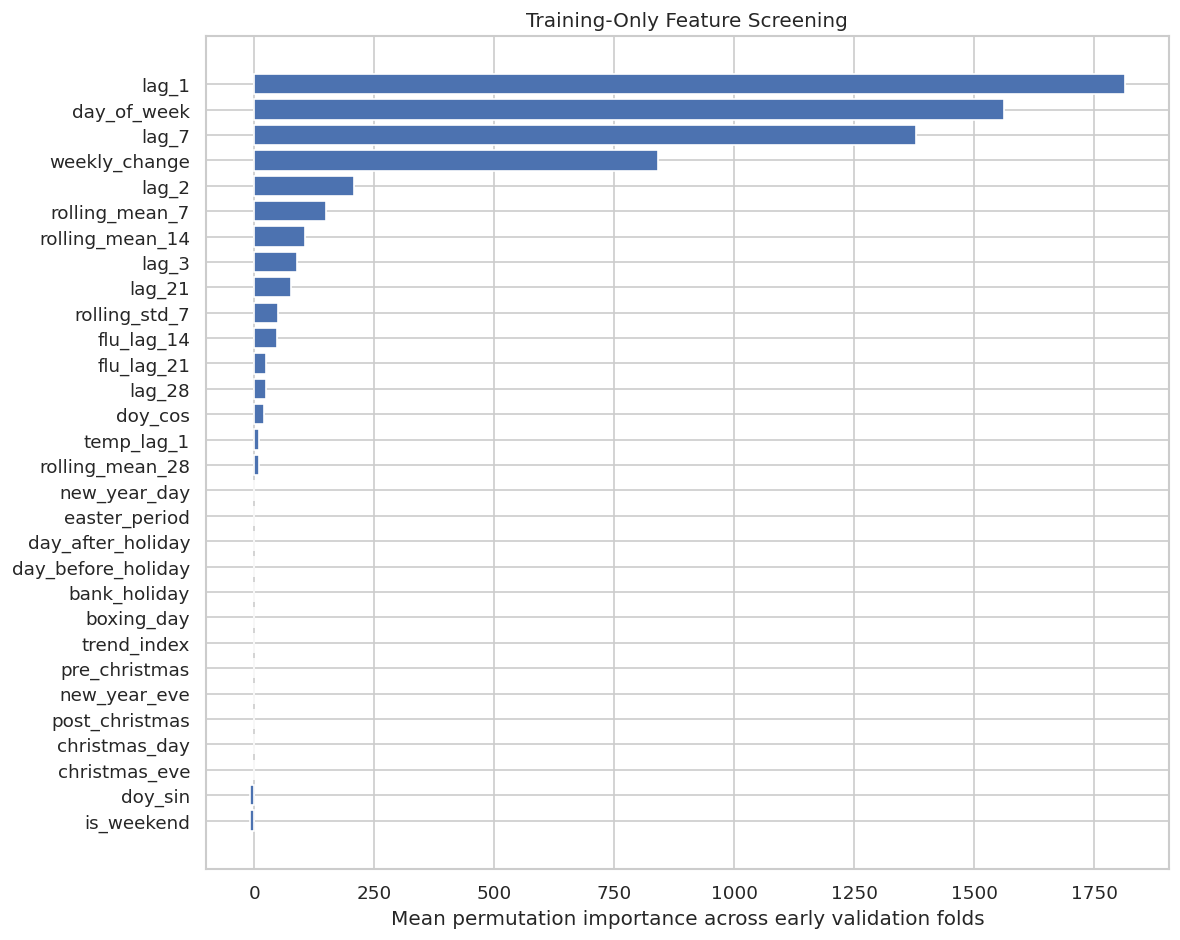

In [53]:
# Visualise the selected predictors

selection_plot_data = feature_selection_rank.head(30).sort_values("Mean_Importance")

plt.figure(figsize=(10, 8))
plt.barh(selection_plot_data["Feature"], selection_plot_data["Mean_Importance"])
plt.title("Training-Only Feature Screening")
plt.xlabel("Mean permutation importance across early validation folds")
plt.tight_layout()
plt.savefig(Figures / "feature_selection_ranking.png", dpi=180, bbox_inches="tight")
plt.show()

In [54]:
# Summarise the selected feature groups

selected_group_summary = pd.DataFrame({
    "Feature_Group": ["Demand history", "Calendar and holidays", "Weather", "Flu"],
    "Selected_Count": [
        len([feature for feature in ml_features if feature in history_features]),
        len([feature for feature in ml_features if feature in calendar_features]),
        len([feature for feature in ml_features if feature in weather_features]),
        len([feature for feature in ml_features if feature in flu_features])
    ]
})

display(selected_group_summary)
print("The selected demand-history features are:", selected_history)

,Feature_Group,Selected_Count
0,Demand history,9
1,Calendar and holidays,16
2,Weather,3
3,Flu,3


The selected demand-history features are: ['lag_1', 'lag_7', 'weekly_change', 'lag_2', 'rolling_mean_7', 'rolling_mean_14', 'lag_3', 'lag_21', 'rolling_std_7']


### **Feature Selection**

Feature selection was applied only to the demand history variables because several of them contained similar information. Nine demand history features were retained after the screening process.

The calendar, holiday, weather and flu features were kept for the later models because these variables are directly linked to the research question. Their contribution is examined later using the fitted models and feature importance analysis.

In [55]:
# Explicit one-day-ahead feature reconstruction and ML walk-forward

feature_source = merged_data.set_index("Date").sort_index()
temp_history_source = feature_source["temp_c"]
flu_history_source = feature_source["flu_positivity"]


def previous_values(series, date, days):
    index = pd.date_range(end=date - pd.Timedelta(days=1), periods=days, freq="D")
    return series.reindex(index)


def build_one_day_feature_row(base_row, target_history, features):
    date = pd.Timestamp(base_row["Date"])
    values = {feature: base_row[feature] for feature in features}

    for lag in [1, 2, 3, 7, 14, 21, 28]:
        name = f"lag_{lag}"
        if name in features:
            values[name] = target_history.get(date - pd.Timedelta(days=lag), np.nan)

    for window in [7, 14, 28]:
        name = f"rolling_mean_{window}"
        if name in features:
            window_values = previous_values(target_history, date, window)
            values[name] = window_values.mean() if window_values.notna().all() else np.nan

    for window in [7, 14]:
        name = f"rolling_std_{window}"
        if name in features:
            window_values = previous_values(target_history, date, window)
            values[name] = window_values.std() if window_values.notna().all() else np.nan

    if "weekly_change" in features:
        lag_1 = target_history.get(date - pd.Timedelta(days=1), np.nan)
        lag_8 = target_history.get(date - pd.Timedelta(days=8), np.nan)
        values["weekly_change"] = lag_1 - lag_8 if pd.notna(lag_1) and pd.notna(lag_8) else np.nan

    if "temp_lag_1" in features:
        values["temp_lag_1"] = temp_history_source.get(date - pd.Timedelta(days=1), np.nan)
    if "temp_lag_7" in features:
        values["temp_lag_7"] = temp_history_source.get(date - pd.Timedelta(days=7), np.nan)
    if "temp_rolling_mean_7" in features:
        window_values = previous_values(temp_history_source, date, 7)
        values["temp_rolling_mean_7"] = window_values.mean() if window_values.notna().all() else np.nan

    if "flu_lag_7" in features:
        values["flu_lag_7"] = flu_history_source.get(date - pd.Timedelta(days=7), np.nan)
    if "flu_lag_14" in features:
        values["flu_lag_14"] = flu_history_source.get(date - pd.Timedelta(days=14), np.nan)
    if "flu_lag_21" in features:
        values["flu_lag_21"] = flu_history_source.get(date - pd.Timedelta(days=21), np.nan)
    if "flu_trend" in features:
        flu_14 = flu_history_source.get(date - pd.Timedelta(days=14), np.nan)
        flu_21 = flu_history_source.get(date - pd.Timedelta(days=21), np.nan)
        values["flu_trend"] = flu_14 - flu_21 if pd.notna(flu_14) and pd.notna(flu_21) else np.nan

    return pd.DataFrame([values], columns=features)


def sequential_ml_predictions(model, history_frame, evaluation_frame, features):
    target_history = history_frame.set_index("Date")["model_A01"].copy()
    predictions = []

    for _, row in evaluation_frame.sort_values("Date").iterrows():
        feature_row = build_one_day_feature_row(row, target_history, features)
        prediction = float(model.predict(feature_row)[0])
        predictions.append(prediction)

        # The actual value becomes historical information only after today's forecast.
        target_history.loc[pd.Timestamp(row["Date"])] = row["model_A01"]

    return np.asarray(predictions, dtype=float)


def run_ml_cv(model_name, model_type, params, features):
    fold_rows = []
    oof_rows = []

    for fold, (train_idx, val_idx) in enumerate(cv_splits, start=1):
        fold_train = train_calendar.iloc[train_idx].copy()
        fold_val = train_calendar.iloc[val_idx].copy()
        fit_train = fold_train[fold_train["model_A01"].notna()].copy()
        mae_scale, mse_scale = seasonal_scales(fold_train)

        model = build_ml_model(model_type, params)
        model.fit(fit_train[features], fit_train["model_A01"])
        prediction = sequential_ml_predictions(model, fold_train, fold_val, features)

        valid = fold_val["model_A01"].notna() & np.isfinite(prediction)
        metrics = forecast_metrics(fold_val.loc[valid, "model_A01"], prediction[valid], mae_scale, mse_scale)
        fold_rows.append({"fold": fold, "Model": model_name, **metrics})

        for date, actual, pred in zip(fold_val.loc[valid, "Date"], fold_val.loc[valid, "model_A01"], prediction[valid]):
            oof_rows.append({"fold": fold, "Date": date, "Model": model_name, "Actual": actual, "Predicted": pred})

    return pd.DataFrame(fold_rows), pd.DataFrame(oof_rows)


In [56]:
# Initial boosting comparison

xgb_fold, xgb_oof = run_ml_cv("XGBoost", "XGBoost", {}, ml_features)
lgb_fold, lgb_oof = run_ml_cv("LightGBM", "LightGBM", {}, ml_features)
cat_fold, cat_oof = run_ml_cv("CatBoost", "CatBoost", {}, ml_features)

initial_boosting = pd.concat([xgb_fold, lgb_fold, cat_fold], ignore_index=True)
display(initial_boosting.groupby("Model")[["ME", "MAE", "RMSE", "R2", "MASE", "RMSSE", "WAPE_pct"]].mean().round(2))

initial_boosting.to_csv(Saved_Outputs / "initial_boosting_cv.csv", index=False)


,ME,MAE,RMSE,R2,MASE,RMSSE,WAPE_pct
Model,,,,,,,
CatBoost,-271.38,1937.74,2894.99,0.90,0.38,0.31,3.50
LightGBM,152.35,2598.09,3870.65,0.82,0.52,0.41,4.67
XGBoost,-582.29,2181.64,3286.99,0.87,0.43,0.35,3.93


# **15. Hyperparameter Tuning with Optuna**

After feature selection, the same final feature set was used for tuning XGBoost, LightGBM and CatBoost.

Optuna tested different parameter settings for each model using the tuning folds from the training period. The setting with the lowest validation MAE was kept for each model.

These tuned settings were then used in the later five fold model comparison.

In [57]:
# Mean tuning-period MAE for Optuna using explicit one-day-ahead validation

def cv_mae(model_type, params):
    scores = []

    for train_idx, val_idx in tuning_splits:
        fold_train = precomparison_calendar.iloc[train_idx].copy()
        fold_val = precomparison_calendar.iloc[val_idx].copy()
        fit_train = fold_train[fold_train["model_A01"].notna()].copy()

        model = build_ml_model(model_type, params)
        model.fit(fit_train[ml_features], fit_train["model_A01"])
        prediction = sequential_ml_predictions(model, fold_train, fold_val, ml_features)

        valid = fold_val["model_A01"].notna() & np.isfinite(prediction)
        scores.append(mean_absolute_error(fold_val.loc[valid, "model_A01"], prediction[valid]))

    return float(np.mean(scores))


In [58]:
# XGBoost objective

def xgb_objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 250, 900),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.12, log=True),
        "max_depth": trial.suggest_int("max_depth", 2, 7),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "subsample": trial.suggest_float("subsample", 0.65, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.65, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-4, 5.0, log=True),
    }
    return cv_mae("XGBoost", params)

xgb_study = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
xgb_study.optimize(xgb_objective, n_trials=20)

print("Best XGBoost CV MAE:", round(xgb_study.best_value, 2))
print(xgb_study.best_params)


Best XGBoost CV MAE: 1968.94
{'n_estimators': 636, 'learning_rate': 0.02158086884697461, 'max_depth': 4, 'min_child_weight': 6, 'subsample': 0.6624580233097386, 'colsample_bytree': 0.7698030126815225, 'reg_alpha': 0.019198170451475496}


In [59]:
# LightGBM objective

def lgb_objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 250, 900),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.12, log=True),
        "num_leaves": trial.suggest_int("num_leaves", 15, 63),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "min_child_samples": trial.suggest_int("min_child_samples", 10, 50),
        "subsample": trial.suggest_float("subsample", 0.65, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.65, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-4, 5.0, log=True),
    }
    return cv_mae("LightGBM", params)

lgb_study = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
lgb_study.optimize(lgb_objective, n_trials=20)

print("Best LightGBM CV MAE:", round(lgb_study.best_value, 2))
print(lgb_study.best_params)


Best LightGBM CV MAE: 2046.08
{'n_estimators': 797, 'learning_rate': 0.011113337230106567, 'num_leaves': 27, 'max_depth': 10, 'min_child_samples': 11, 'subsample': 0.9669069687141467, 'colsample_bytree': 0.7339334376107635, 'reg_alpha': 0.00014310930144509194}


In [60]:
# CatBoost objective

def cat_objective(trial):
    params = {
        "iterations": trial.suggest_int("iterations", 250, 900),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.12, log=True),
        "depth": trial.suggest_int("depth", 4, 9),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1.0, 15.0),
        "random_strength": trial.suggest_float("random_strength", 0.0, 2.0)
    }
    return cv_mae("CatBoost", params)

cat_study = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
cat_study.optimize(cat_objective, n_trials=20)

print("Best CatBoost CV MAE:", round(cat_study.best_value, 2))
print(cat_study.best_params)


Best CatBoost CV MAE: 1853.35
{'iterations': 648, 'learning_rate': 0.01414292239608043, 'depth': 5, 'l2_leaf_reg': 6.129065806111684, 'random_strength': 0.9121399684340719}


In [61]:
# Save tuning results

tuning_results = pd.DataFrame({
    "Model": ["XGBoost", "LightGBM", "CatBoost"],
    "Best_CV_MAE": [xgb_study.best_value, lgb_study.best_value, cat_study.best_value],
    "Best_Params": [str(xgb_study.best_params), str(lgb_study.best_params), str(cat_study.best_params)]
})

display(tuning_results)
tuning_results.to_csv(Saved_Outputs / "optuna_tuning_results.csv", index=False)

# Re-run tuned models on the same frozen folds

tuned_xgb_fold, tuned_xgb_oof = run_ml_cv("Tuned XGBoost", "XGBoost", xgb_study.best_params, ml_features)
tuned_lgb_fold, tuned_lgb_oof = run_ml_cv("Tuned LightGBM", "LightGBM", lgb_study.best_params, ml_features)
tuned_cat_fold, tuned_cat_oof = run_ml_cv("Tuned CatBoost", "CatBoost", cat_study.best_params, ml_features)

,Model,Best_CV_MAE,Best_Params
0,XGBoost,1968.943279,"{'n_estimators': 636, 'learning_rate': 0.02158..."
1,LightGBM,2046.082661,"{'n_estimators': 797, 'learning_rate': 0.01111..."
2,CatBoost,1853.349647,"{'iterations': 648, 'learning_rate': 0.0141429..."


In [62]:
# Summarise tuning result

best_tuning_row = tuning_results.sort_values("Best_CV_MAE").iloc[0]
print("Best tuning model:", best_tuning_row["Model"])
print("Best tuning MAE:", round(best_tuning_row["Best_CV_MAE"], 2))
print("The tuned parameters are now kept before the later model-comparison folds.")

Best tuning model: CatBoost
Best tuning MAE: 1853.35
The tuned parameters are now kept before the later model-comparison folds.


## **15.1 Feature Selection Check**

The final 31 machine learning features were checked before model comparison.

This check confirms that the selected feature list does not contain the target, same day weather, same day flu or any reporting quality variables that were excluded because of data leakage risk.

In [63]:
print("Final selected ML features:", len(ml_features))
print("Forbidden selected features:", sorted(set(ml_features).intersection(forbidden)))
print("Selected feature names:")
print(ml_features)

if len(set(ml_features).intersection(forbidden)) > 0:
    raise ValueError("Leakage risk: a forbidden feature entered the selected set.")

Final selected ML features: 31
Forbidden selected features: []
Selected feature names:
['lag_1', 'lag_7', 'weekly_change', 'lag_2', 'rolling_mean_7', 'rolling_mean_14', 'lag_3', 'lag_21', 'rolling_std_7', 'day_of_week', 'is_weekend', 'doy_sin', 'doy_cos', 'trend_index', 'bank_holiday', 'day_before_holiday', 'day_after_holiday', 'pre_christmas', 'christmas_eve', 'christmas_day', 'boxing_day', 'post_christmas', 'new_year_eve', 'new_year_day', 'easter_period', 'temp_lag_1', 'temp_lag_7', 'temp_rolling_mean_7', 'flu_lag_14', 'flu_lag_21', 'flu_trend']


# **16. Training Period Model Selection**

The tuned XGBoost, LightGBM and CatBoost models were compared with SARIMAX, Prophet and the seven day seasonal naive baseline using the same five validation folds.

MAE was used as the main measure for choosing the best model. RMSE, MASE, RMSSE, R² and Mean Error were also reported to give a fuller view of each model's performance.

The model with the lowest average MAE across the five folds was selected for the final test.

In [64]:
# Combine development results

comparison_fold = pd.concat([baseline_fold, sarimax_fold, prophet_fold, tuned_xgb_fold, tuned_lgb_fold, tuned_cat_fold], ignore_index=True)
comparison_oof = pd.concat([baseline_oof, sarimax_oof, prophet_oof, tuned_xgb_oof, tuned_lgb_oof, tuned_cat_oof], ignore_index=True)

leaderboard = comparison_fold.groupby("Model").agg(
    ME_mean=("ME", "mean"),
    ME_sd=("ME", "std"),
    MAE_mean=("MAE", "mean"),
    MAE_sd=("MAE", "std"),
    RMSE_mean=("RMSE", "mean"),
    RMSE_sd=("RMSE", "std"),
    R2_mean=("R2", "mean"),
    MASE_mean=("MASE", "mean"),
    RMSSE_mean=("RMSSE", "mean"),
    WAPE_mean=("WAPE_pct", "mean")
).sort_values("MAE_mean").reset_index()

display(leaderboard.round(3))

comparison_fold.to_csv(Saved_Outputs / "training_fold_metrics.csv", index=False)
comparison_oof.to_csv(Saved_Outputs / "training_oof_predictions.csv", index=False)
leaderboard.to_csv(Saved_Outputs / "training_model_leaderboard.csv", index=False)


,Model,ME_mean,ME_sd,MAE_mean,MAE_sd,RMSE_mean,RMSE_sd,R2_mean,MASE_mean,RMSSE_mean,WAPE_mean
0,Tuned CatBoost,-432.487,714.821,1971.600,738.183,2981.172,1472.387,0.897,0.391,0.318,3.564
1,Tuned XGBoost,-446.815,651.785,2103.492,938.218,3179.741,1849.192,0.878,0.418,0.340,3.796
2,Tuned LightGBM,-508.233,640.648,2121.027,1022.587,3129.346,1796.585,0.882,0.421,0.334,3.818
3,SARIMAX,-79.710,312.048,2487.731,1005.137,3557.513,1775.802,0.851,0.493,0.379,4.493
4,Seasonal Naive,-103.561,229.956,3845.896,1691.602,5755.966,2927.280,0.586,0.765,0.617,6.957
5,Prophet,679.735,3744.891,4497.308,1682.064,6103.373,3063.248,0.565,0.892,0.651,8.133


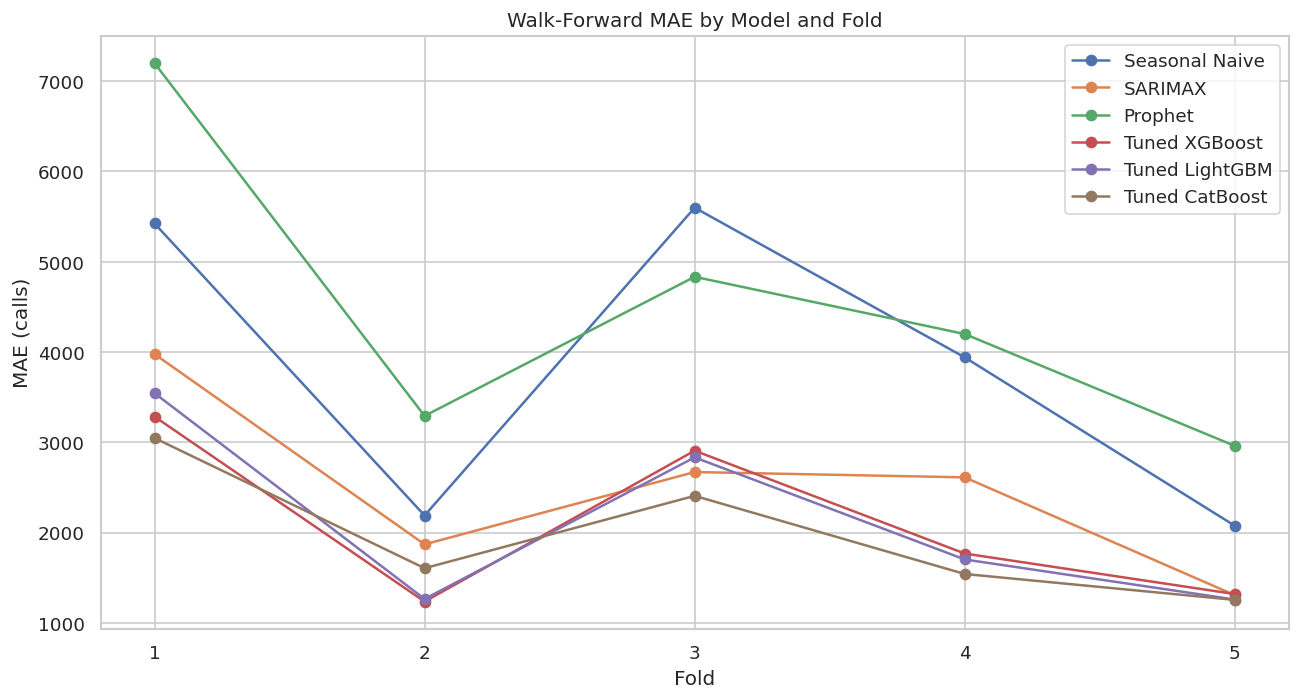

In [65]:
# Development MAE across folds

plt.figure(figsize=(11, 6))

for model_name in comparison_fold["Model"].unique():
    model_rows = comparison_fold[comparison_fold["Model"] == model_name]
    plt.plot(model_rows["fold"], model_rows["MAE"], marker="o", label=model_name)

plt.xticks(sorted(comparison_fold["fold"].unique()))
plt.title("Walk-Forward MAE by Model and Fold")
plt.xlabel("Fold")
plt.ylabel("MAE (calls)")
plt.legend()
plt.tight_layout()
plt.savefig(Figures / "15_cv_mae_by_fold.png", dpi=180, bbox_inches="tight")
plt.show()

In [66]:
# Summarise model-comparison result

development_best = leaderboard.iloc[0]
development_second = leaderboard.iloc[1]
print("Selected model before final test:", development_best["Model"])
print("Mean comparison-fold MAE:", round(development_best["MAE_mean"], 2))
print("Second model:", development_second["Model"])
print("Second model mean MAE:", round(development_second["MAE_mean"], 2))

Selected model before final test: Tuned CatBoost
Mean comparison-fold MAE: 1971.6
Second model: Tuned XGBoost
Second model mean MAE: 2103.49


## **16.1 Friedman Test**

A Friedman test was used to compare how the models ranked across the five validation folds.

The result is used only as an additional check during model development because the boosting models were also tuned using training period data. The final comparison between models is carried out later using the held out test period.

In [67]:
# Global fold-level comparison

mae_pivot = comparison_fold.pivot(index="fold", columns="Model", values="MAE").dropna()
model_names = mae_pivot.columns.tolist()
friedman_inputs = [mae_pivot[name].to_numpy() for name in model_names]

friedman_stat, friedman_p = stats.friedmanchisquare(*friedman_inputs)

print("Friedman statistic:", round(friedman_stat, 4))
print("Friedman p-value:", round(friedman_p, 6))

Friedman statistic: 20.4286
Friedman p-value: 0.001038


In [68]:
# Interpret the Friedman test

print("Friedman p-value:", round(friedman_p, 6))
if friedman_p < 0.05:
    print("The shared comparison folds provide evidence that the models do not all perform the same.")
else:
    print("The shared comparison folds do not provide strong evidence of a difference between the models.")

Friedman p-value: 0.001038
The shared comparison folds provide evidence that the models do not all perform the same.


### **Friedman Test Result**

The Friedman test gave a statistic of 22.49 and a p value of 0.000423. Since the p value is below 0.05, there was a significant difference in how the models ranked by MAE across the five validation folds.

This test does not identify which individual models differ from each other. It only shows that the models did not have the same overall performance across the development folds.

This result is used as part of the training period comparison. The final model comparison is carried out later using the held out test data.

## **16.2 Development Fold Error Comparison**

A Diebold Mariano style test was used to compare the forecast errors of the selected model with each of the other models.

For each date, the absolute forecast error of the selected model was compared with the absolute error from the other model. The test then checked whether the average difference between their errors was statistically significant.

A p value below 0.05 was taken as evidence that the two models had different forecasting performance. A negative test statistic means the selected model had the lower average error.

This comparison was carried out using the development folds. The final statistical comparison is repeated later using the held out test period.

In [69]:
# Select the model using training results only

selected_model = leaderboard.iloc[0]["Model"]
print("Model selected before test evaluation:", selected_model)

def dm_style_test(best_data, other_data, lag=7):
    merged = best_data.merge(other_data, on=["fold", "Date", "Actual"], suffixes=("_best", "_other"))
    loss_best = np.abs(merged["Actual"] - merged["Predicted_best"])
    loss_other = np.abs(merged["Actual"] - merged["Predicted_other"])
    d = (loss_best - loss_other).to_numpy()
    n = len(d)
    mean_d = d.mean()
    centered = d - mean_d
    variance = np.mean(centered ** 2)

    for k in range(1, min(lag, n - 1) + 1):
        covariance = np.mean(centered[k:] * centered[:-k])
        variance += 2 * (1 - k / (lag + 1)) * covariance

    if variance <= 0 or n < 3:
        return np.nan, np.nan, n

    statistic = mean_d / np.sqrt(variance / n)
    p_value = 2 * (1 - stats.norm.cdf(abs(statistic)))
    return statistic, p_value, n

best_oof = comparison_oof[comparison_oof["Model"] == selected_model].copy()
dm_rows = []

for other_model in leaderboard["Model"]:
    if other_model == selected_model:
        continue

    other_oof = comparison_oof[comparison_oof["Model"] == other_model].copy()
    statistic, p_value, n = dm_style_test(best_oof, other_oof)
    dm_rows.append([selected_model, other_model, statistic, p_value, n])

dm_results = pd.DataFrame(dm_rows, columns=["Best_Model", "Compared_With", "DM_stat", "p_value", "n"])
dm_results["p_bonferroni"] = np.minimum(dm_results["p_value"] * len(dm_results), 1.0)

display(dm_results.round(5))
dm_results.to_csv(Saved_Outputs / "forecast_error_significance.csv", index=False)

Model selected before test evaluation: Tuned CatBoost


,Best_Model,Compared_With,DM_stat,p_value,n,p_bonferroni
0,Tuned CatBoost,Tuned XGBoost,-1.27217,0.20331,280,1.00000
1,Tuned CatBoost,Tuned LightGBM,-1.16333,0.24469,280,1.00000
2,Tuned CatBoost,SARIMAX,-3.36934,0.00075,280,0.00377
3,Tuned CatBoost,Seasonal Naive,-4.70730,0.00000,280,0.00001
4,Tuned CatBoost,Prophet,-6.02460,0.00000,280,0.00000


### **Development Fold Error Comparison Results**

Tuned CatBoost was selected before the final test because it had the lowest average MAE during the model comparison stage.

The Diebold Mariano style test compared CatBoost with each of the other models using the 280 forecasts from the development folds. The negative test statistics mean that CatBoost had a lower average absolute error than the model it was compared with.

After adjusting the p values for the five comparisons, CatBoost had significantly lower forecast errors than Tuned XGBoost, SARIMAX, the seasonal naive baseline and Prophet.

The comparison with Tuned LightGBM was different. Its adjusted p value was 0.783, which is above 0.05. Therefore, there was not enough evidence during the development period to say that CatBoost and LightGBM had significantly different forecast errors.

These results are based on the development folds. The same type of comparison is carried out again on the held out test period after the models have been finalised.

# **17. Final Held Out Test Evaluation**

The final 280 days are used to test the models after feature selection, tuning and model comparison have been completed. These dates were not used to choose the final model.

The forecasting task remains one day ahead. For the boosting models, the features for each test date are rebuilt using information from earlier dates only. After a forecast is made, the actual call value for that date becomes available and can then be used when preparing the next day's forecast.

Prophet and SARIMAX are also evaluated one day at a time. Dates with partial NHS 111 reporting are kept in the timeline but are not included when the final accuracy measures are calculated.


In [70]:
# Full training data

full_train = train_calendar.copy()
fit_train = full_train[full_train["model_A01"].notna()].copy()
test_predictions = test_calendar[["Date", "reported_A01", "model_A01", "partial_reporting"]].copy()
test_mae_scale, test_mse_scale = seasonal_scales(full_train)

# Seasonal naive

seasonal_pred = test_calendar["lag_7"].copy()
seasonal_fallback = test_calendar[["lag_7", "lag_14", "lag_21", "lag_28"]].median(axis=1)
test_predictions["Seasonal Naive"] = seasonal_pred.fillna(seasonal_fallback).to_numpy()

# Extra simple test baselines used only as a sanity check

simple_fallback = test_calendar[["lag_7", "lag_14", "lag_21", "lag_28"]].median(axis=1)
test_predictions["Persistence Naive"] = test_calendar["lag_1"].fillna(simple_fallback).to_numpy()
test_predictions["Lag1 Lag7 Average"] = test_calendar[["lag_1", "lag_7"]].mean(axis=1).fillna(simple_fallback).to_numpy()


In [71]:
# Final tuned ML models with explicit one-day-ahead test walk-forward

final_ml_models = {}

final_xgb = build_ml_model("XGBoost", xgb_study.best_params)
final_xgb.fit(fit_train[ml_features], fit_train["model_A01"])
test_predictions["Tuned XGBoost"] = sequential_ml_predictions(final_xgb, full_train, test_calendar, ml_features)
final_ml_models["Tuned XGBoost"] = final_xgb

final_lgb = build_ml_model("LightGBM", lgb_study.best_params)
final_lgb.fit(fit_train[ml_features], fit_train["model_A01"])
test_predictions["Tuned LightGBM"] = sequential_ml_predictions(final_lgb, full_train, test_calendar, ml_features)
final_ml_models["Tuned LightGBM"] = final_lgb

final_cat = build_ml_model("CatBoost", cat_study.best_params)
final_cat.fit(fit_train[ml_features], fit_train["model_A01"])
test_predictions["Tuned CatBoost"] = sequential_ml_predictions(final_cat, full_train, test_calendar, ml_features)
final_ml_models["Tuned CatBoost"] = final_cat


In [72]:
# Final Prophet one-day-ahead test walk-forward

print("Running final Prophet one-day-ahead test evaluation...")

prophet_test_predictions, final_prophet = prophet_walk_forward(full_train, test_calendar)
test_predictions["Prophet"] = prophet_test_predictions

print("Prophet test predictions complete.")

Running final Prophet one-day-ahead test evaluation...
Prophet test predictions complete.


In [73]:
# Final SARIMAX model and one-day-ahead test walk-forward

sarimax_train = full_train.set_index("Date").asfreq("D")

final_sarimax = SARIMAX(sarimax_train["model_A01"], exog=sarimax_train[sarimax_features], order=best_sarimax_order, seasonal_order=best_sarimax_seasonal, trend="c", enforce_stationarity=False, enforce_invertibility=False)
final_sarimax_result = final_sarimax.fit(disp=False, maxiter=500)
final_sarimax_converged = bool(final_sarimax_result.mle_retvals.get("converged", False))

print("Final SARIMAX converged:", final_sarimax_converged)

sarimax_test_predictions = []

for _, row in test_calendar.iterrows():
    date = row["Date"]
    exog_row = pd.DataFrame([row[sarimax_features].to_dict()], index=[date])
    pred = float(final_sarimax_result.get_forecast(steps=1, exog=exog_row).predicted_mean.iloc[0])
    sarimax_test_predictions.append(pred)

    observed = pd.Series([row["model_A01"]], index=[date], name="model_A01")
    final_sarimax_result = final_sarimax_result.append(observed, exog=exog_row, refit=False)

test_predictions["SARIMAX"] = sarimax_test_predictions

Final SARIMAX converged: True


In [74]:
# Final held-out test metrics

test_model_names = ["Seasonal Naive", "SARIMAX", "Prophet", "Tuned XGBoost", "Tuned LightGBM", "Tuned CatBoost"]
test_metric_rows = []

for model_name in test_model_names:
    valid = test_predictions["model_A01"].notna() & test_predictions[model_name].notna()
    metrics = forecast_metrics(test_predictions.loc[valid, "model_A01"], test_predictions.loc[valid, model_name], test_mae_scale, test_mse_scale)
    test_metric_rows.append({"Model": model_name, "Scored_Days": int(valid.sum()), **metrics})

test_leaderboard = pd.DataFrame(test_metric_rows).sort_values("MAE").reset_index(drop=True)

baseline_mae = test_leaderboard.loc[test_leaderboard["Model"] == "Seasonal Naive", "MAE"].iloc[0]
test_leaderboard["MAE_Improvement_vs_Seasonal_Naive_pct"] = 100 * (baseline_mae - test_leaderboard["MAE"]) / baseline_mae

print("Pre-selected model:", selected_model)
print("\nFinal held-out test results:")
display(test_leaderboard.round(3))

test_predictions.to_csv(Saved_Outputs / "final_test_predictions.csv", index=False)
test_leaderboard.to_csv(Saved_Outputs / "final_test_leaderboard.csv", index=False)

Pre-selected model: Tuned CatBoost

Final held-out test results:


,Model,Scored_Days,ME,MAE,RMSE,R2,MASE,RMSSE,WAPE_pct,MAE_Improvement_vs_Seasonal_Naive_pct
0,Tuned CatBoost,278,188.068,2023.529,3353.832,0.898,0.422,0.378,3.654,51.828
1,Tuned LightGBM,278,-445.082,2041.479,3445.765,0.892,0.426,0.389,3.686,51.401
2,Tuned XGBoost,278,-325.978,2119.627,3307.005,0.901,0.442,0.373,3.827,49.540
3,SARIMAX,278,149.895,2245.855,3856.462,0.865,0.469,0.435,4.055,46.535
4,Prophet,278,-1314.924,3880.675,5818.593,0.692,0.810,0.656,7.007,7.617
5,Seasonal Naive,278,280.489,4200.619,7120.953,0.539,0.877,0.803,7.585,0.000


### **Simple Baseline Check**

Two simple forecasts are also tested on the final period. One uses the previous day's call value and the other uses the average of the previous day and the same day one week earlier.

This gives another reference point for the machine learning results and helps show how much of the forecasting performance comes from the strong short term and weekly pattern in NHS 111 demand.


In [75]:
# Compare the selected model with additional simple test baselines

sanity_test_rows = []

for model_name in ["Persistence Naive", "Lag1 Lag7 Average", "Seasonal Naive", selected_model]:
    valid = test_predictions["model_A01"].notna() & test_predictions[model_name].notna()
    metrics = forecast_metrics(test_predictions.loc[valid, "model_A01"], test_predictions.loc[valid, model_name], test_mae_scale, test_mse_scale)
    sanity_test_rows.append({"Model": model_name, "Scored_Days": int(valid.sum()), **metrics})

sanity_test_results = pd.DataFrame(sanity_test_rows).sort_values("MAE").reset_index(drop=True)
display(sanity_test_results.round(3))
sanity_test_results.to_csv(Saved_Outputs / "simple_baseline_sanity_test.csv", index=False)


,Model,Scored_Days,ME,MAE,RMSE,R2,MASE,RMSSE,WAPE_pct
0,Tuned CatBoost,278,188.068,2023.529,3353.832,0.898,0.422,0.378,3.654
1,Seasonal Naive,278,280.489,4200.619,7120.953,0.539,0.877,0.803,7.585
2,Lag1 Lag7 Average,278,149.714,4836.426,7038.624,0.549,1.009,0.794,8.733
3,Persistence Naive,278,3.079,7591.266,10651.332,-0.032,1.584,1.201,13.707


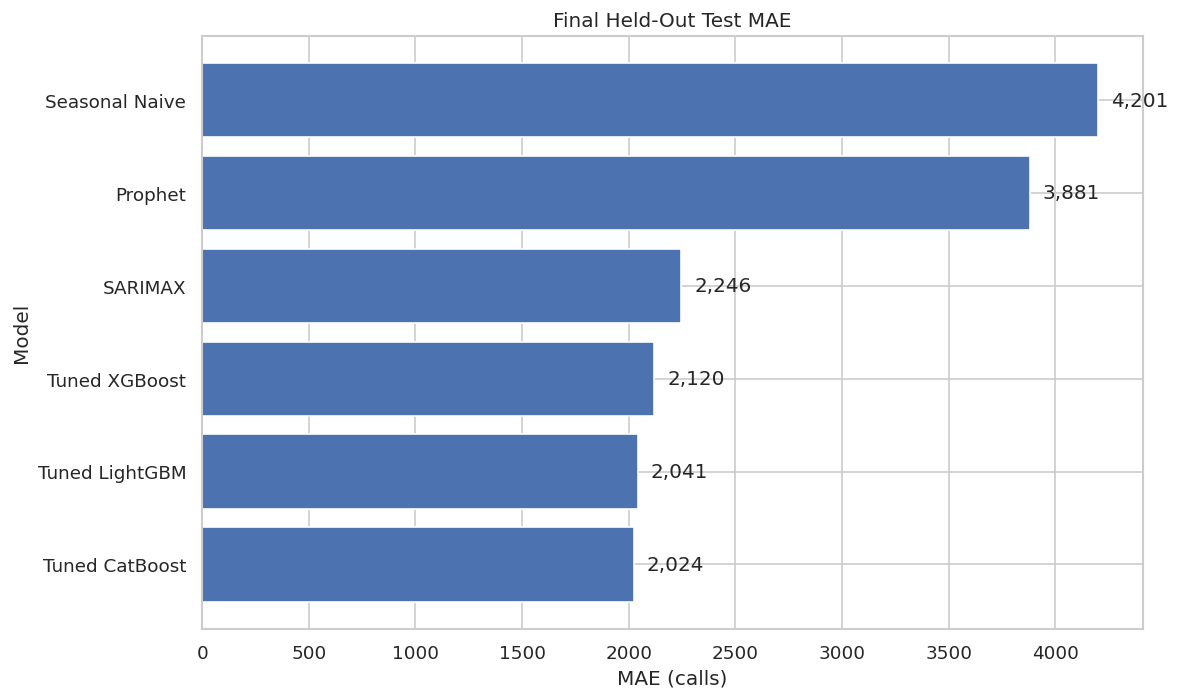

In [76]:
# Final held-out MAE ranking

test_plot = test_leaderboard.sort_values("MAE", ascending=True).copy()

plt.figure(figsize=(10, 6))
bars = plt.barh(test_plot["Model"], test_plot["MAE"])

for bar, value in zip(bars, test_plot["MAE"]):
    plt.text(value + 60, bar.get_y() + bar.get_height() / 2, f"{value:,.0f}", va="center")

plt.title("Final Held-Out Test MAE")
plt.xlabel("MAE (calls)")
plt.ylabel("Model")
plt.tight_layout()
plt.savefig(Figures / "16_final_test_mae.png", dpi=180, bbox_inches="tight")
plt.show()

In [77]:
# Summarise the final held-out test

selected_row = test_leaderboard[test_leaderboard["Model"] == selected_model].iloc[0]
numeric_best = test_leaderboard.iloc[0]
print("Pre-selected model:", selected_model)
print("Held-out MAE:", round(selected_row["MAE"], 2))
print("Held-out RMSE:", round(selected_row["RMSE"], 2))
print("Held-out R2:", round(selected_row["R2"], 3))
print("MAE improvement over seasonal naive (%):", round(selected_row["MAE_Improvement_vs_Seasonal_Naive_pct"], 2))
print("Numerically lowest held-out MAE model:", numeric_best["Model"], round(numeric_best["MAE"], 2))

Pre-selected model: Tuned CatBoost
Held-out MAE: 2023.53
Held-out RMSE: 3353.83
Held-out R2: 0.898
MAE improvement over seasonal naive (%): 51.83
Numerically lowest held-out MAE model: Tuned CatBoost 2023.53


## **17.1 Final Evaluation Check**

Before comparing the final results, I checked that all models were evaluated on the same dates and for the same one day ahead forecasting task.

Dates with partial reporting are not scored. The check also confirms that every model produced the prediction columns needed for the final comparison.


In [78]:
# Check final evaluation consistency

evaluation_audit = test_leaderboard[["Model", "Scored_Days", "ME", "MAE", "RMSE", "R2", "MASE", "RMSSE", "WAPE_pct"]].copy()

print("Held-out period:")
print(test_calendar["Date"].min(), "to", test_calendar["Date"].max())
print("\nTotal test days:")
print(len(test_calendar))
print("\nComplete target days available for scoring:")
print(test_calendar["model_A01"].notna().sum())
print("\nModel evaluation audit:")
display(evaluation_audit.round(3))

expected_scored_days = int(test_calendar["model_A01"].notna().sum())
same_scored_days = (evaluation_audit["Scored_Days"] == expected_scored_days).all()

print("\nAll models scored on the same number of valid test days:")
print(same_scored_days)

evaluation_audit.to_csv(Saved_Outputs / "final_evaluation_audit.csv", index=False)


Held-out period:
2025-08-25 00:00:00 to 2026-05-31 00:00:00

Total test days:
280

Complete target days available for scoring:
278

Model evaluation audit:


,Model,Scored_Days,ME,MAE,RMSE,R2,MASE,RMSSE,WAPE_pct
0,Tuned CatBoost,278,188.068,2023.529,3353.832,0.898,0.422,0.378,3.654
1,Tuned LightGBM,278,-445.082,2041.479,3445.765,0.892,0.426,0.389,3.686
2,Tuned XGBoost,278,-325.978,2119.627,3307.005,0.901,0.442,0.373,3.827
3,SARIMAX,278,149.895,2245.855,3856.462,0.865,0.469,0.435,4.055
4,Prophet,278,-1314.924,3880.675,5818.593,0.692,0.810,0.656,7.007
5,Seasonal Naive,278,280.489,4200.619,7120.953,0.539,0.877,0.803,7.585



All models scored on the same number of valid test days:
True


## **17.2 Held Out Forecast Comparison**

The selected CatBoost model is compared with each of the other models using the forecast errors from the final test period.

A Diebold Mariano style test is used to compare the daily absolute errors from the two models. The calculation allows for the possibility that errors on nearby days may be related.

Several model comparisons are made, so the p values are adjusted using the Holm method. The statistical results are considered together with MAE and RMSE instead of using the p value alone.


In [79]:
# Formal held-out comparison of frozen models

def heldout_dm_test(actual, pred_a, pred_b, lag=7):
    actual = np.asarray(actual, dtype=float)
    pred_a = np.asarray(pred_a, dtype=float)
    pred_b = np.asarray(pred_b, dtype=float)
    loss_a = np.abs(actual - pred_a)
    loss_b = np.abs(actual - pred_b)
    difference = loss_a - loss_b
    n = len(difference)
    mean_difference = difference.mean()
    centered = difference - mean_difference
    variance = np.mean(centered ** 2)

    for k in range(1, min(lag, n - 1) + 1):
        covariance = np.mean(centered[k:] * centered[:-k])
        variance += 2 * (1 - k / (lag + 1)) * covariance

    if variance <= 0 or n < 3:
        return np.nan, np.nan, n

    statistic = mean_difference / np.sqrt(variance / n)
    p_value = 2 * (1 - stats.norm.cdf(abs(statistic)))
    return statistic, p_value, n

valid_test = test_predictions["model_A01"].notna()
actual_test = test_predictions.loc[valid_test, "model_A01"].to_numpy()
selected_pred = test_predictions.loc[valid_test, selected_model].to_numpy()
heldout_dm_rows = []

for other_model in test_model_names:
    if other_model == selected_model:
        continue

    other_pred = test_predictions.loc[valid_test, other_model].to_numpy()
    statistic, p_value, n = heldout_dm_test(actual_test, selected_pred, other_pred, lag=7)
    heldout_dm_rows.append([selected_model, other_model, statistic, p_value, n])

heldout_dm = pd.DataFrame(heldout_dm_rows, columns=["Selected_Model", "Compared_With", "DM_stat", "p_value", "n"])
heldout_dm["p_holm"] = multipletests(heldout_dm["p_value"], method="holm")[1]
heldout_dm["Significant_0.05"] = heldout_dm["p_holm"] < 0.05

display(heldout_dm.round(5))
heldout_dm.to_csv(Saved_Outputs / "heldout_forecast_significance.csv", index=False)

,Selected_Model,Compared_With,DM_stat,p_value,n,p_holm,Significant_0.05
0,Tuned CatBoost,Seasonal Naive,-5.55532,0.00000,278,0.00000,True
1,Tuned CatBoost,SARIMAX,-1.54150,0.12319,278,0.36958,False
2,Tuned CatBoost,Prophet,-3.82794,0.00013,278,0.00052,True
3,Tuned CatBoost,Tuned XGBoost,-1.04468,0.29617,278,0.59234,False
4,Tuned CatBoost,Tuned LightGBM,-0.16931,0.86555,278,0.86555,False


In [80]:
# Summarise held-out significance results

print("Held-out pairwise comparison after Holm correction:")
display(heldout_dm[["Compared_With", "p_holm", "Significant_0.05"]].round(5))

Held-out pairwise comparison after Holm correction:


,Compared_With,p_holm,Significant_0.05
0,Seasonal Naive,0.00000,True
1,SARIMAX,0.36958,False
2,Prophet,0.00052,True
3,Tuned XGBoost,0.59234,False
4,Tuned LightGBM,0.86555,False


### **Held Out Comparison Results**

After the Holm adjustment, CatBoost had significantly lower forecast errors than Prophet and the seasonal naive model.

The differences between CatBoost and SARIMAX, XGBoost and LightGBM were not statistically significant at the 5% level. LightGBM recorded a slightly lower MAE than CatBoost on the final test period, but the difference between their daily errors was not significant.

CatBoost therefore remained the model selected from the training period, while the final test results show that LightGBM, XGBoost and SARIMAX produced similar forecasting performance.


## **17.3 Leakage and Feature Check**

The final features are checked again before the results are interpreted.

For each lag and rolling demand feature, the code rebuilds the expected value from the original dated series and checks that it comes from an earlier date. The weather and flu lag features are checked in the same way.

The code also confirms that the target, same day weather, same day flu and reporting quality columns are not included in the final machine learning features. The notebook stops if any of these checks fail.


In [81]:
# Leakage and feature integrity audit

required_test_columns = ["Date", "model_A01", selected_model]
required_calendar_columns = ["Date", "day_of_week", "month", "bank_holiday"]

missing_test_columns = [column for column in required_test_columns if column not in test_predictions.columns]
missing_calendar_columns = [column for column in required_calendar_columns if column not in test_calendar.columns]

# Rebuild the expected feature values from the full dated source before the
# first 28 modelling days were removed. This keeps every lag aligned by date.
audit_source = merged_data[["Date", "reported_A01", "partial_reporting", "temp_c", "flu_positivity"]].copy()
audit_source["model_A01"] = audit_source["reported_A01"].where(audit_source["partial_reporting"] == 0)
audit_source = audit_source.sort_values("Date").set_index("Date")

audit_dates = pd.DatetimeIndex(model_data["Date"])
target_source = audit_source["model_A01"]
temp_source = audit_source["temp_c"]
flu_source = audit_source["flu_positivity"]

def aligned_shift(series, periods):
    return series.shift(periods).reindex(audit_dates).to_numpy(dtype=float)

def aligned_rolling(series, window, statistic="mean"):
    shifted = series.shift(1)
    if statistic == "mean":
        expected = shifted.rolling(window).mean()
    else:
        expected = shifted.rolling(window).std()
    return expected.reindex(audit_dates).to_numpy(dtype=float)

checks = []

for lag in [1, 2, 3, 7, 14, 21, 28]:
    column = f"lag_{lag}"
    expected = aligned_shift(target_source, lag)
    actual = model_data[column].to_numpy(dtype=float)
    checks.append([column, np.allclose(actual, expected, equal_nan=True)])

for window in [7, 14, 28]:
    column = f"rolling_mean_{window}"
    expected = aligned_rolling(target_source, window, "mean")
    actual = model_data[column].to_numpy(dtype=float)
    checks.append([column, np.allclose(actual, expected, equal_nan=True)])

for window in [7, 14]:
    column = f"rolling_std_{window}"
    expected = aligned_rolling(target_source, window, "std")
    actual = model_data[column].to_numpy(dtype=float)
    checks.append([column, np.allclose(actual, expected, equal_nan=True)])

expected_weekly_change = (target_source.shift(1) - target_source.shift(8)).reindex(audit_dates).to_numpy(dtype=float)
checks.append([
    "weekly_change",
    np.allclose(model_data["weekly_change"].to_numpy(dtype=float), expected_weekly_change, equal_nan=True)
])

weather_expected = {
    "temp_lag_1": aligned_shift(temp_source, 1),
    "temp_lag_7": aligned_shift(temp_source, 7),
    "temp_rolling_mean_7": aligned_rolling(temp_source, 7, "mean")
}

for column, expected in weather_expected.items():
    actual = model_data[column].to_numpy(dtype=float)
    checks.append([column, np.allclose(actual, expected, equal_nan=True)])

flu_expected = {
    "flu_lag_14": aligned_shift(flu_source, 14),
    "flu_lag_21": aligned_shift(flu_source, 21),
    "flu_trend": (flu_source.shift(14) - flu_source.shift(21)).reindex(audit_dates).to_numpy(dtype=float)
}

for column, expected in flu_expected.items():
    actual = model_data[column].to_numpy(dtype=float)
    checks.append([column, np.allclose(actual, expected, equal_nan=True)])

forbidden_selected = sorted(set(ml_features).intersection(forbidden))
checks.append(["no_forbidden_features", len(forbidden_selected) == 0])
checks.append(["required_prediction_columns", len(missing_test_columns) == 0])
checks.append(["required_calendar_columns", len(missing_calendar_columns) == 0])

leakage_audit = pd.DataFrame(checks, columns=["Check", "Passed"])
display(leakage_audit)

failed_checks = leakage_audit.loc[~leakage_audit["Passed"], "Check"].tolist()
print("Forbidden selected features:", forbidden_selected)
print("Failed integrity checks:", failed_checks)

if failed_checks:
    raise ValueError(f"Leakage or integrity check failed: {failed_checks}")

leakage_audit.to_csv(Saved_Outputs / "final_leakage_audit.csv", index=False)


,Check,Passed
0,lag_1,True
1,lag_2,True
2,lag_3,True
3,lag_7,True
4,lag_14,True
5,lag_21,True
6,lag_28,True
7,rolling_mean_7,True
8,rolling_mean_14,True
9,rolling_mean_28,True


Forbidden selected features: []
Failed integrity checks: []


# **18. Final Error Analysis**

The overall accuracy measures do not show the dates where the model makes its largest mistakes. The final errors are therefore checked by date, weekday, month and bank holiday status.

The residuals are also tested for remaining autocorrelation. These checks are used to describe the weaknesses of the selected model. They are not used to change or retune the model after the final test has been seen.


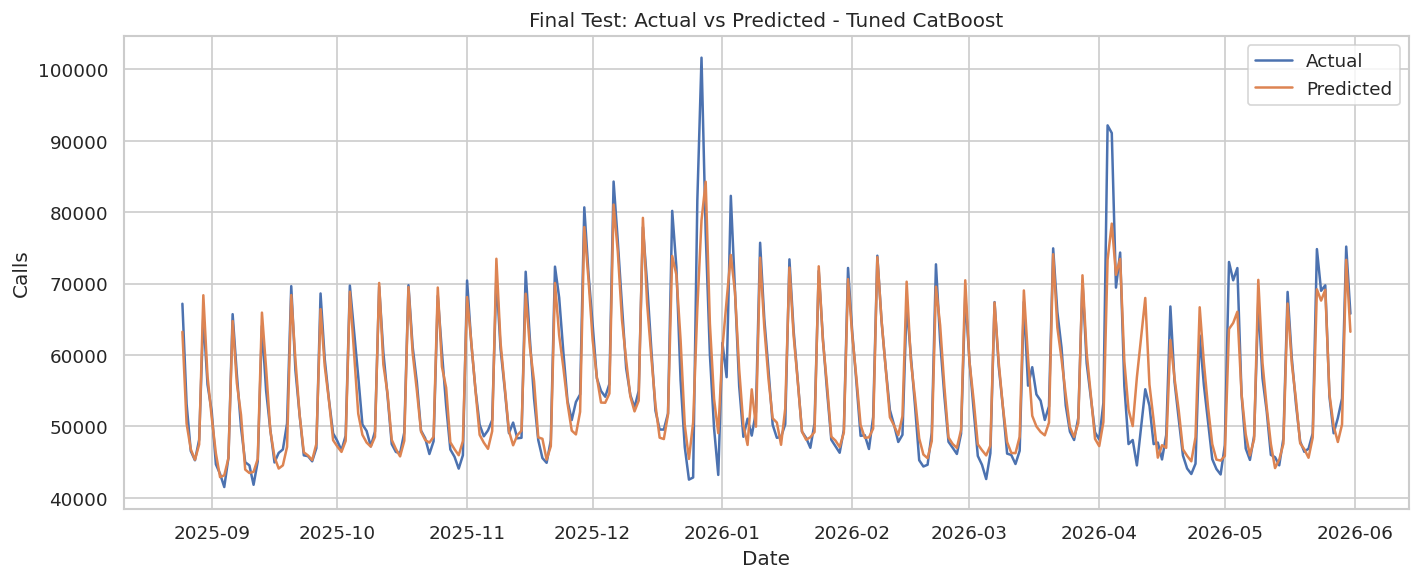

Largest final test errors:


,Date,model_A01,Predicted,Error,Absolute_Error
124,2025-12-27,101636.0,78873.68,22762.32,22762.32
221,2026-04-03,92152.0,73339.01,18812.99,18812.99
123,2025-12-26,81616.0,66456.00,15160.00,15160.00
230,2026-04-12,55198.0,67982.68,-12784.68,12784.68
222,2026-04-04,91080.0,78395.40,12684.60,12684.60
228,2026-04-10,44534.0,56878.56,-12344.56,12344.56
130,2026-01-02,56892.0,67646.49,-10754.49,10754.49
250,2026-05-02,73022.0,63633.11,9388.89,9388.89
131,2026-01-03,82285.0,74006.35,8278.65,8278.65
122,2025-12-25,42843.0,50543.55,-7700.55,7700.55


In [82]:
# Selected model test errors

selected_test = test_predictions[test_predictions["model_A01"].notna()].copy()
selected_test["Predicted"] = selected_test[selected_model]
selected_test["Error"] = selected_test["model_A01"] - selected_test["Predicted"]
selected_test["Absolute_Error"] = selected_test["Error"].abs()

plt.figure(figsize=(12, 5))
plt.plot(selected_test["Date"], selected_test["model_A01"], label="Actual")
plt.plot(selected_test["Date"], selected_test["Predicted"], label="Predicted")
plt.title(f"Final Test: Actual vs Predicted - {selected_model}")
plt.xlabel("Date")
plt.ylabel("Calls")
plt.legend()
plt.tight_layout()
plt.savefig(Figures / "05_final_test_actual_vs_predicted.png", dpi=180, bbox_inches="tight")
plt.show()

print("Largest final test errors:")
worst_errors = selected_test.nlargest(15, "Absolute_Error")[["Date", "model_A01", "Predicted", "Error", "Absolute_Error"]]
display(worst_errors.round(2))
worst_errors.to_csv(Saved_Outputs / "final_test_worst_errors.csv", index=False)

In [83]:
# Error patterns by weekday, month and bank holiday

error_analysis = selected_test.merge(
    test_calendar[["Date", "day_of_week", "month", "bank_holiday"]],
    on="Date",
    how="left"
)

weekday_errors = error_analysis.groupby("day_of_week")["Absolute_Error"].agg(["count", "mean", "median"]).reset_index()
monthly_errors = error_analysis.groupby("month")["Absolute_Error"].agg(["count", "mean", "median"]).reset_index()
holiday_errors = error_analysis.groupby("bank_holiday")["Absolute_Error"].agg(["count", "mean", "median"]).reset_index()

print("Errors by weekday:")
display(weekday_errors.round(2))

print("Errors by month:")
display(monthly_errors.round(2))

print("Errors by bank holiday:")
display(holiday_errors.round(2))

weekday_errors.to_csv(Saved_Outputs / "final_errors_by_weekday.csv", index=False)
monthly_errors.to_csv(Saved_Outputs / "final_errors_by_month.csv", index=False)
holiday_errors.to_csv(Saved_Outputs / "final_errors_by_holiday.csv", index=False)

Errors by weekday:


,day_of_week,count,mean,median
0,0,40,1737.56,1187.63
1,1,40,1340.43,1010.48
2,2,40,1519.98,1108.88
3,3,40,1682.92,1406.08
4,4,40,2656.98,1291.68
5,5,39,3251.37,2084.57
6,6,39,2005.71,1254.59


Errors by month:


,month,count,mean,median
0,1,31,1862.19,1150.18
1,2,28,1231.33,992.60
2,3,31,1699.76,1499.87
3,4,29,3941.31,2108.07
4,5,31,2011.98,1371.03
5,8,7,1660.98,1143.55
6,9,30,1151.57,998.48
7,10,30,1113.50,861.50
8,11,30,1688.92,1446.37
9,12,31,3571.84,1621.06


Errors by bank holiday:


,bank_holiday,count,mean,median
0,0,270,1883.70,1311.03
1,1,8,6742.86,5025.39


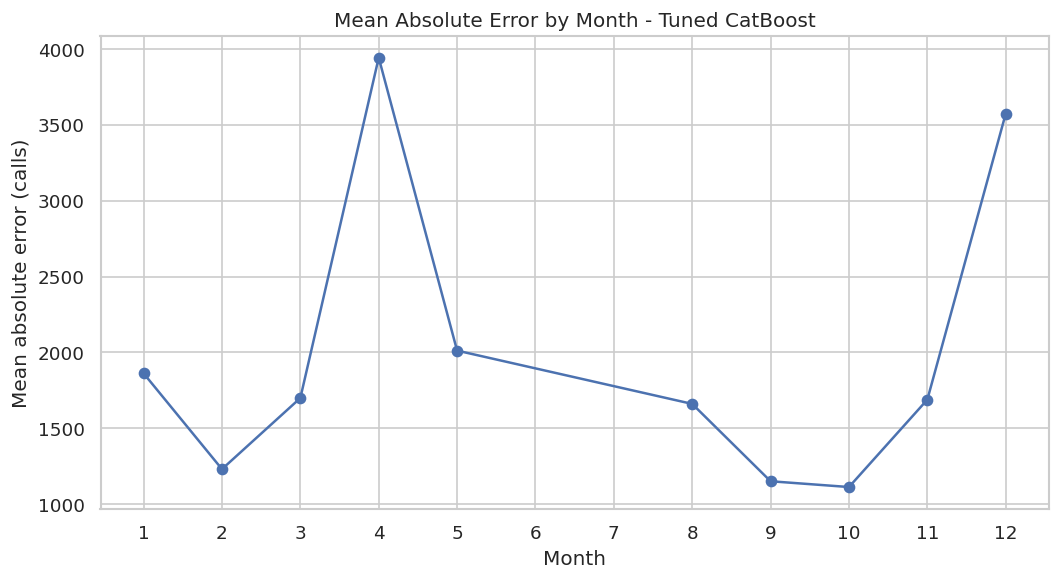

In [84]:
# Monthly held-out error profile

plt.figure(figsize=(9, 5))
plt.plot(monthly_errors["month"], monthly_errors["mean"], marker="o")
plt.xticks(range(1, 13))
plt.title(f"Mean Absolute Error by Month - {selected_model}")
plt.xlabel("Month")
plt.ylabel("Mean absolute error (calls)")
plt.tight_layout()
plt.savefig(Figures / "final_errors_by_month.png", dpi=180, bbox_inches="tight")
plt.show()

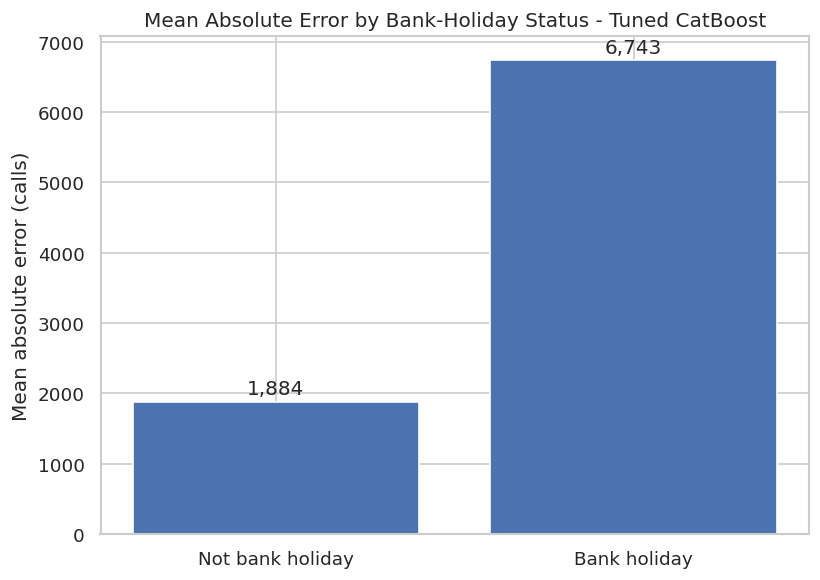

In [85]:
# Compare ordinary-day and bank-holiday errors

plt.figure(figsize=(7, 5))
bars = plt.bar(["Not bank holiday", "Bank holiday"], holiday_errors["mean"])

for bar, value in zip(bars, holiday_errors["mean"]):
    plt.text(bar.get_x() + bar.get_width() / 2, value + 100, f"{value:,.0f}", ha="center")

plt.title(f"Mean Absolute Error by Bank-Holiday Status - {selected_model}")
plt.ylabel("Mean absolute error (calls)")
plt.tight_layout()
plt.savefig(Figures / "17_holiday_error_comparison.png", dpi=180, bbox_inches="tight")
plt.show()

In [86]:
# Summarise holiday errors

normal_error = holiday_errors.loc[holiday_errors["bank_holiday"] == 0, "mean"].iloc[0]
holiday_error = holiday_errors.loc[holiday_errors["bank_holiday"] == 1, "mean"].iloc[0]
print("Mean absolute error on ordinary days:", round(normal_error, 2))
print("Mean absolute error on bank holidays:", round(holiday_error, 2))

Mean absolute error on ordinary days: 1883.7
Mean absolute error on bank holidays: 6742.86


### **Bank Holiday Errors**

The model has a much larger average error on bank holidays than on ordinary days. This means that unusual holiday demand is still more difficult to forecast even though holiday information is included in the feature set.

This is kept as a limitation of the final model instead of adding new features after looking at the test results.


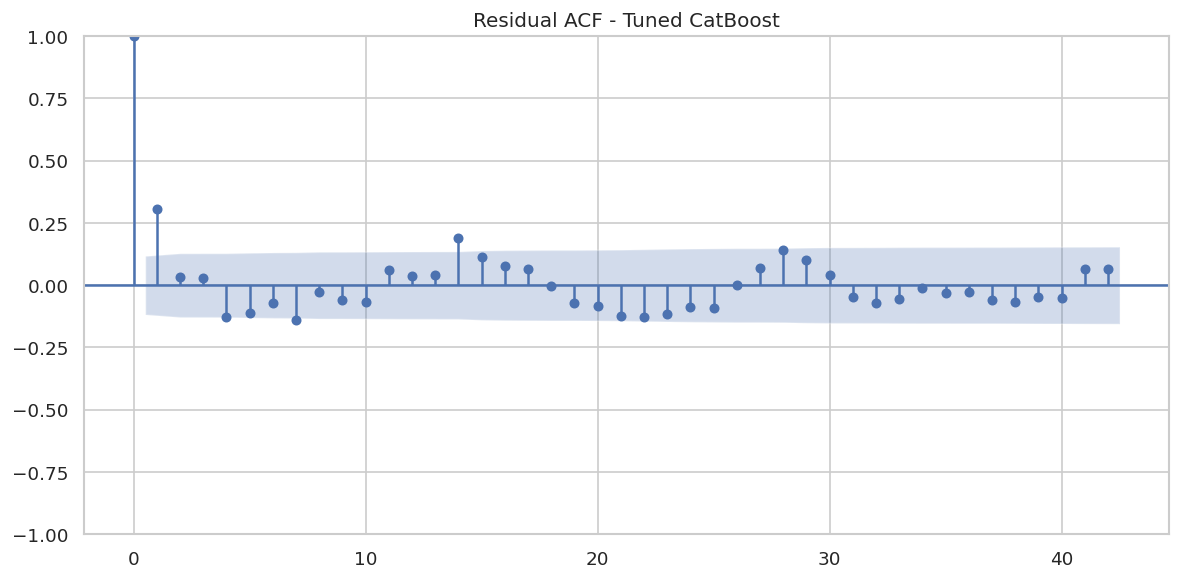

,lb_stat,lb_pvalue
7,42.2128,0.0
14,57.4360,0.0


In [87]:
# Residual autocorrelation and Ljung-Box test

residuals = selected_test["Error"].dropna()

fig, ax = plt.subplots(figsize=(10, 5))
plot_acf(residuals, lags=42, ax=ax)
ax.set_title(f"Residual ACF - {selected_model}")
fig.tight_layout()
fig.savefig(Figures / "06_selected_model_residual_acf.png", dpi=180, bbox_inches="tight")
plt.show()

ljung_box = acorr_ljungbox(residuals, lags=[7, 14], return_df=True)
display(ljung_box.round(4))
ljung_box.to_csv(Saved_Outputs / "selected_model_ljung_box.csv")

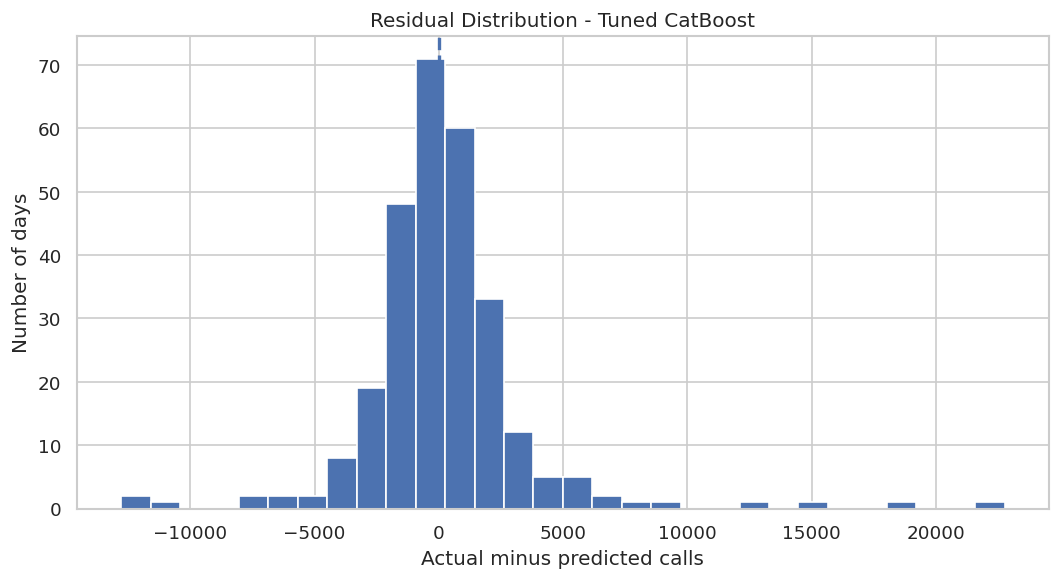

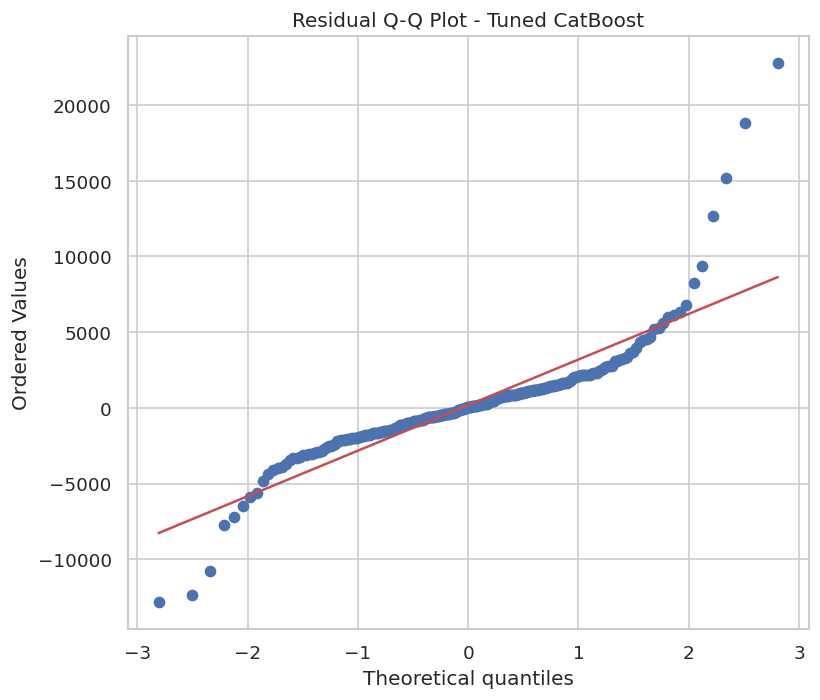

In [88]:
# Residual distribution

plt.figure(figsize=(9, 5))
plt.hist(residuals, bins=30)
plt.axvline(0, linestyle="--", linewidth=2)
plt.title(f"Residual Distribution - {selected_model}")
plt.xlabel("Actual minus predicted calls")
plt.ylabel("Number of days")
plt.tight_layout()
plt.savefig(Figures / "18_residual_distribution.png", dpi=180, bbox_inches="tight")
plt.show()

# Q-Q plot

plt.figure(figsize=(7, 6))
stats.probplot(residuals, dist="norm", plot=plt)
plt.title(f"Residual Q-Q Plot - {selected_model}")
plt.tight_layout()
plt.savefig(Figures / "19_residual_qq.png", dpi=180, bbox_inches="tight")
plt.show()

### **Residual Check**

The Ljung Box test gives p values below 0.05 at lags 7 and 14. This means that some pattern is still present in the forecast errors.

The model captures a large part of the weekly pattern in NHS 111 demand, but it does not remove all of it. This is reported as a limitation of the final forecast model.


# **19. Factors That Influence the Forecast**

The research question also asks which factors are most useful for forecasting NHS 111 demand. Three checks are used for this.

Permutation importance measures how much the validation error changes when a feature is disrupted. SHAP is used to show how strongly each feature contributes to the fitted boosting model. Feature group removal checks what happens to MAE when demand history, calendar, weather or flu variables are removed.

These results are used to discuss predictive importance. They do not show that a feature causes NHS 111 demand to change.


In [89]:
# Select the best boosting model using training CV only

boosting_names = ["Tuned XGBoost", "Tuned LightGBM", "Tuned CatBoost"]
boosting_leaderboard = leaderboard[leaderboard["Model"].isin(boosting_names)].sort_values("MAE_mean").reset_index(drop=True)
best_boosting = boosting_leaderboard.iloc[0]["Model"]

if best_boosting == "Tuned XGBoost":
    best_boosting_type = "XGBoost"
    best_boosting_params = xgb_study.best_params
elif best_boosting == "Tuned LightGBM":
    best_boosting_type = "LightGBM"
    best_boosting_params = lgb_study.best_params
else:
    best_boosting_type = "CatBoost"
    best_boosting_params = cat_study.best_params

print("Boosting model used for interpretability:", best_boosting)

Boosting model used for interpretability: Tuned CatBoost


## **19.1 Permutation Importance**

Permutation importance is calculated using validation data that was not used to fit the model in that fold. Each feature is shuffled and the change in MAE is measured.

A larger positive value means that the model depends more on that feature for accurate predictions.


In [90]:
# Fit on the final training fold and explain its validation period

last_train_idx, last_val_idx = cv_splits[-1]
importance_train = train_calendar.iloc[last_train_idx].copy()
importance_val = train_calendar.iloc[last_val_idx].copy()

importance_train = importance_train[importance_train["model_A01"].notna()]
importance_val = importance_val[importance_val["model_A01"].notna()]

importance_model = build_ml_model(best_boosting_type, best_boosting_params)
importance_model.fit(importance_train[ml_features], importance_train["model_A01"])

perm = permutation_importance(importance_model, importance_val[ml_features], importance_val["model_A01"], scoring="neg_mean_absolute_error", n_repeats=20, random_state=RANDOM_STATE)

permutation_table = pd.DataFrame({
    "Feature": ml_features,
    "Importance_Mean": perm.importances_mean,
    "Importance_SD": perm.importances_std
}).sort_values("Importance_Mean", ascending=False).reset_index(drop=True)

display(permutation_table.round(3))
permutation_table.to_csv(Saved_Outputs / "permutation_importance.csv", index=False)

,Feature,Importance_Mean,Importance_SD
0,lag_7,1999.954,206.036
1,day_of_week,1411.609,176.714
2,is_weekend,968.358,128.588
3,lag_1,909.563,173.315
4,weekly_change,330.477,81.879
5,lag_21,231.211,68.358
6,day_before_holiday,81.662,38.093
7,lag_2,48.153,44.510
8,lag_3,19.698,22.012
9,temp_rolling_mean_7,16.890,9.381


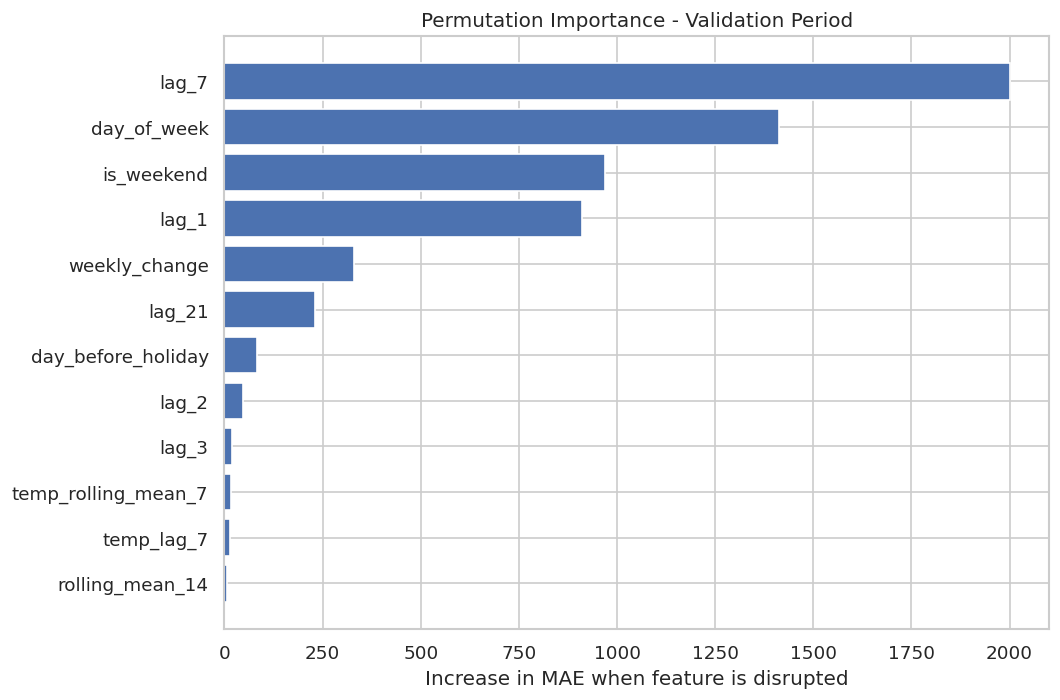

In [91]:
# Permutation importance chart

perm_plot = permutation_table.head(12).sort_values("Importance_Mean")

plt.figure(figsize=(9, 6))
plt.barh(perm_plot["Feature"], perm_plot["Importance_Mean"])
plt.title("Permutation Importance - Validation Period")
plt.xlabel("Increase in MAE when feature is disrupted")
plt.tight_layout()
plt.savefig(Figures / "20_permutation_importance.png", dpi=180, bbox_inches="tight")
plt.show()

In [92]:
# Summarise permutation importance

top_perm = permutation_table.head(5)["Feature"].tolist()
print("Top five permutation-importance features:", top_perm)

Top five permutation-importance features: ['lag_7', 'day_of_week', 'is_weekend', 'lag_1', 'weekly_change']


## **19.2 SHAP**

SHAP is used as a second way of examining the fitted boosting model. It shows how much each feature contributes to the model predictions across the observations used for interpretation.

The SHAP results are compared with the permutation importance results so that the discussion is not based on only one importance method.


,Feature,Mean_Abs_SHAP
0,lag_7,2770.356
1,day_of_week,2003.806
2,is_weekend,1527.444
3,lag_1,1265.170
4,weekly_change,1058.069
5,lag_21,1054.797
6,bank_holiday,579.633
7,trend_index,565.528
8,rolling_mean_7,512.786
9,lag_2,440.413


/tmp/ipykernel_11470/2864943637.py:20: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, explain_data, show=False)


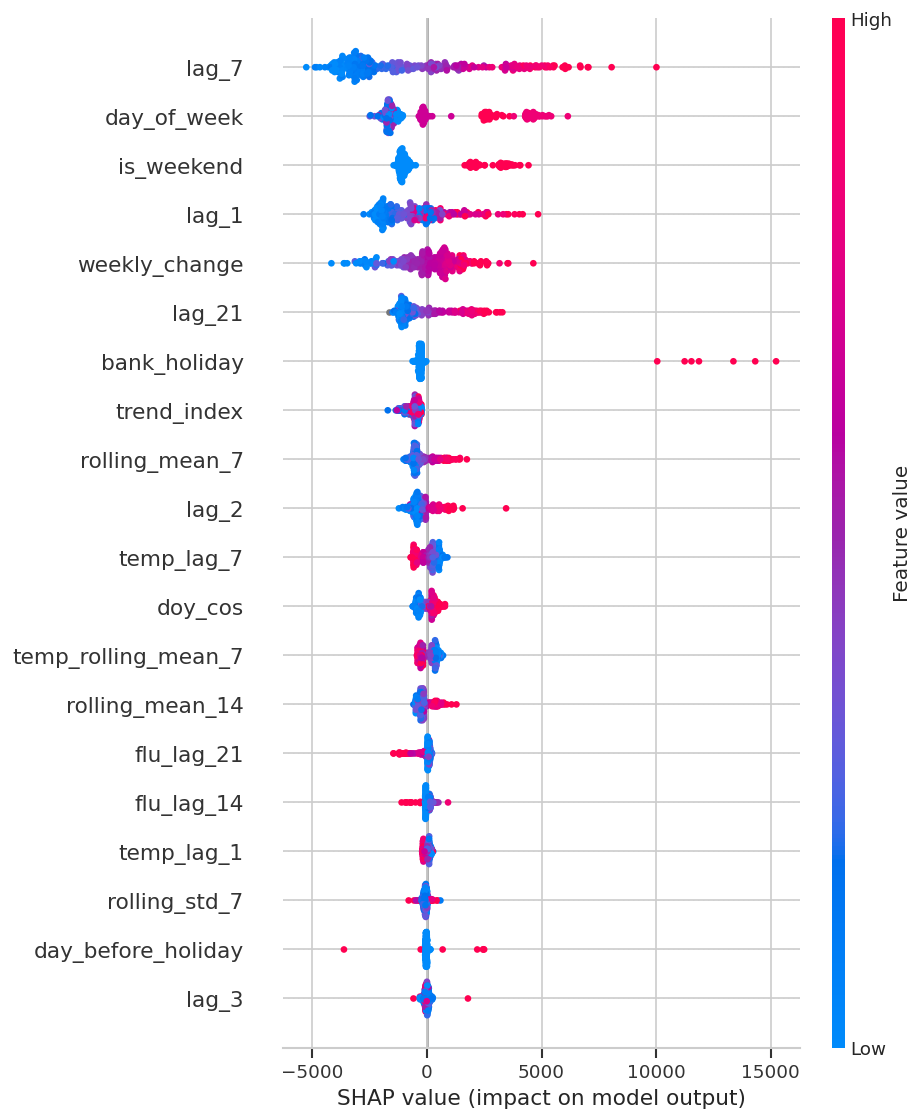

In [93]:
# Fit the final interpretability model

interpretability_model = build_ml_model(best_boosting_type, best_boosting_params)
interpretability_model.fit(fit_train[ml_features], fit_train["model_A01"])

explain_data = fit_train[ml_features].tail(min(300, len(fit_train))).copy()

explainer = shap.TreeExplainer(interpretability_model)
shap_explanation = explainer(explain_data)
shap_values = shap_explanation.values

shap_importance = pd.DataFrame({
    "Feature": ml_features,
    "Mean_Abs_SHAP": np.abs(shap_values).mean(axis=0)
}).sort_values("Mean_Abs_SHAP", ascending=False).reset_index(drop=True)

display(shap_importance.round(3))
shap_importance.to_csv(Saved_Outputs / "shap_feature_importance.csv", index=False)

shap.summary_plot(shap_values, explain_data, show=False)
plt.tight_layout()
plt.savefig(Figures / "07_shap_beeswarm.png", dpi=180, bbox_inches="tight")
plt.show()

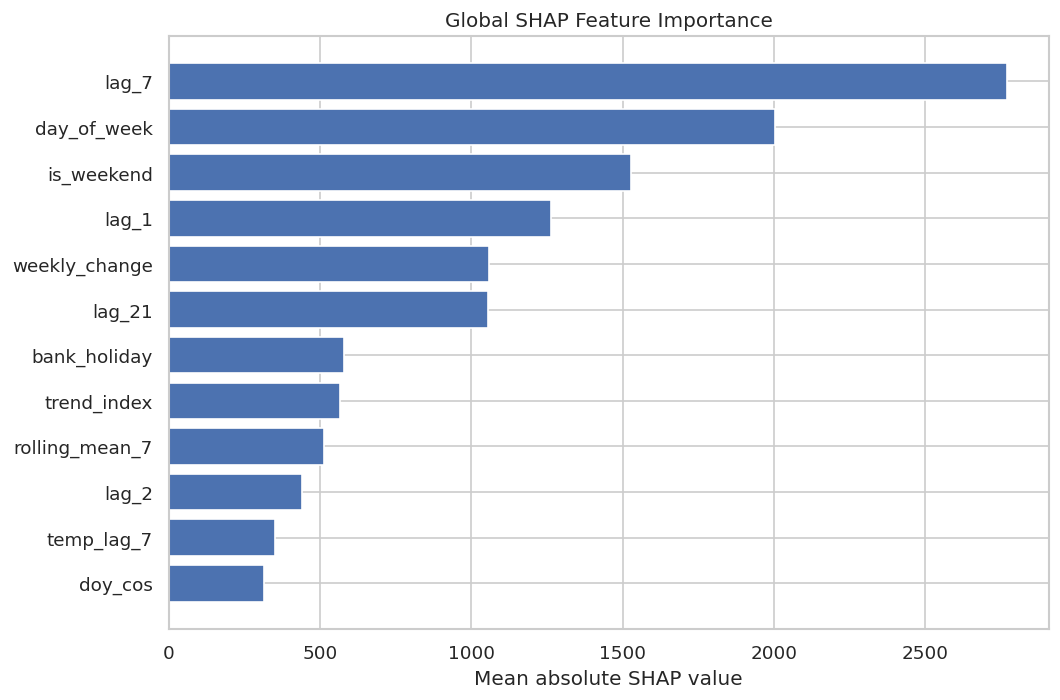

In [94]:
# SHAP global importance chart

shap_plot = shap_importance.head(12).sort_values("Mean_Abs_SHAP")

plt.figure(figsize=(9, 6))
plt.barh(shap_plot["Feature"], shap_plot["Mean_Abs_SHAP"])
plt.title("Global SHAP Feature Importance")
plt.xlabel("Mean absolute SHAP value")
plt.tight_layout()
plt.savefig(Figures / "21_shap_global_importance.png", dpi=180, bbox_inches="tight")
plt.show()

In [95]:
# Summarise SHAP importance

top_shap = shap_importance.head(5)["Feature"].tolist()
print("Top five SHAP features:", top_shap)

Top five SHAP features: ['lag_7', 'day_of_week', 'is_weekend', 'lag_1', 'weekly_change']


## **19.3 Feature Group Removal**

The selected boosting model is tested again after removing one group of features at a time. The groups are demand history, calendar, weather and flu.

If MAE increases after a group is removed, the information in that group was helping the forecasts. This makes it easier to compare the contribution of the main types of information used in the model.


In [96]:
# Compare the full feature set with groups removed

ablation_sets = {
    "Full model": ml_features,
    "Without demand history": [f for f in ml_features if f not in history_features],
    "Without calendar": [f for f in ml_features if f not in calendar_features],
    "Without weather": [f for f in ml_features if f not in weather_features],
    "Without flu": [f for f in ml_features if f not in flu_features]
}

ablation_rows = []

for label, features in ablation_sets.items():
    fold_result, _ = run_ml_cv(label, best_boosting_type, best_boosting_params, features)
    ablation_rows.append([label, fold_result["MAE"].mean(), fold_result["MAE"].std()])

ablation_results = pd.DataFrame(ablation_rows, columns=["Feature_Set", "MAE_Mean", "MAE_SD"])
full_mae = ablation_results.loc[ablation_results["Feature_Set"] == "Full model", "MAE_Mean"].iloc[0]
ablation_results["MAE_Increase_vs_Full"] = ablation_results["MAE_Mean"] - full_mae
ablation_results = ablation_results.sort_values("MAE_Increase_vs_Full", ascending=False).reset_index(drop=True)

display(ablation_results.round(2))
ablation_results.to_csv(Saved_Outputs / "feature_group_ablation.csv", index=False)

,Feature_Set,MAE_Mean,MAE_SD,MAE_Increase_vs_Full
0,Without demand history,2953.79,1877.64,982.19
1,Without calendar,2351.36,961.48,379.76
2,Without flu,2084.28,866.83,112.68
3,Full model,1971.60,738.18,0.00
4,Without weather,1937.52,730.24,-34.08


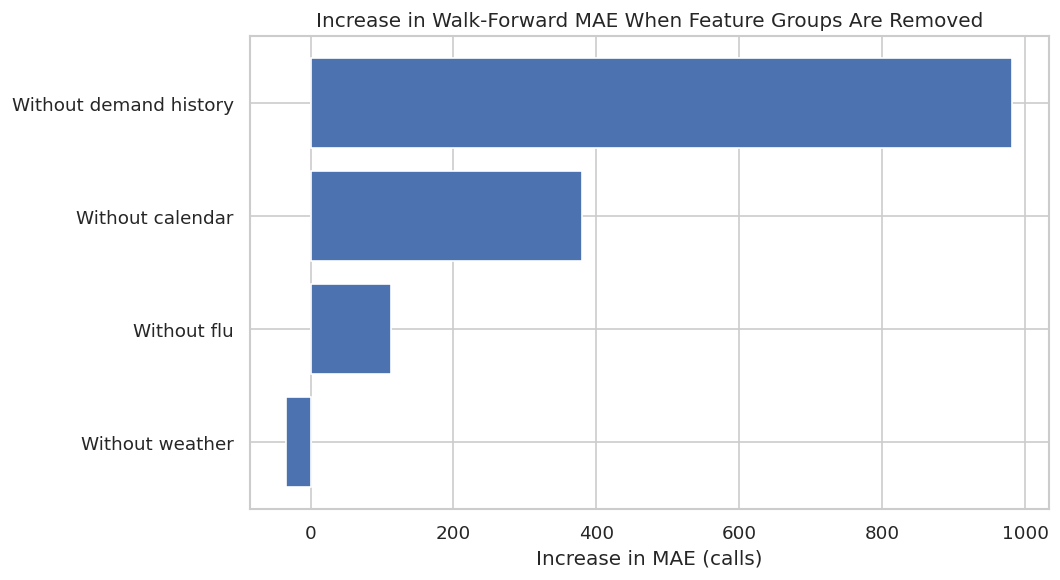

In [97]:
# Feature-group ablation chart

ablation_plot = ablation_results[ablation_results["Feature_Set"] != "Full model"].sort_values("MAE_Increase_vs_Full")

plt.figure(figsize=(9, 5))
plt.barh(ablation_plot["Feature_Set"], ablation_plot["MAE_Increase_vs_Full"])
plt.title("Increase in Walk-Forward MAE When Feature Groups Are Removed")
plt.xlabel("Increase in MAE (calls)")
plt.tight_layout()
plt.savefig(Figures / "22_feature_group_ablation.png", dpi=180, bbox_inches="tight")
plt.show()

In [98]:
# Summarise feature-group ablation

ablation_summary = ablation_results.sort_values("MAE_Increase_vs_Full", ascending=False)
display(ablation_summary.round(2))

,Feature_Set,MAE_Mean,MAE_SD,MAE_Increase_vs_Full
0,Without demand history,2953.79,1877.64,982.19
1,Without calendar,2351.36,961.48,379.76
2,Without flu,2084.28,866.83,112.68
3,Full model,1971.60,738.18,0.00
4,Without weather,1937.52,730.24,-34.08


# **20. Sensitivity Checks**

The main results are checked under a few different choices to see whether the conclusions change greatly.

The checks cover the unusually high demand around December 2022, the flu lag used in the main model, partial reporting dates and the possible level change identified in May 2024.


## **20.1 December 2022 High Demand Period**

The December 2022 high demand period is kept in the main analysis because it is part of the observed NHS 111 data.

As a separate check, the selected boosting model is trained again after removing the main high demand window from the training folds. The validation dates remain unchanged. This allows the effect of that unusual period on forecasting performance to be examined.


In [99]:
# Compare model training with and without the December 2022 spike period

spike_start = pd.Timestamp("2022-12-18")
spike_end = pd.Timestamp("2023-01-02")

spike_rows = []

for remove_spike in [False, True]:
    fold_scores = []

    for train_idx, val_idx in cv_splits:
        fold_train = train_calendar.iloc[train_idx].copy()
        fold_val = train_calendar.iloc[val_idx].copy()
        fit_data = fold_train[fold_train["model_A01"].notna()].copy()
        score_data = fold_val[fold_val["model_A01"].notna()].copy()

        if remove_spike:
            fit_data = fit_data[~fit_data["Date"].between(spike_start, spike_end)]

        model = build_ml_model(best_boosting_type, best_boosting_params)
        model.fit(fit_data[ml_features], fit_data["model_A01"])
        prediction = model.predict(score_data[ml_features])
        fold_scores.append(mean_absolute_error(score_data["model_A01"], prediction))

    label = "Spike removed from training" if remove_spike else "Original training data"
    spike_rows.append([label, np.mean(fold_scores), np.std(fold_scores)])

spike_sensitivity = pd.DataFrame(spike_rows, columns=["Scenario", "MAE_Mean", "MAE_SD"])
display(spike_sensitivity.round(2))
spike_sensitivity.to_csv(Saved_Outputs / "december_2022_spike_sensitivity.csv", index=False)

,Scenario,MAE_Mean,MAE_SD
0,Original training data,1971.60,660.25
1,Spike removed from training,1919.43,577.94


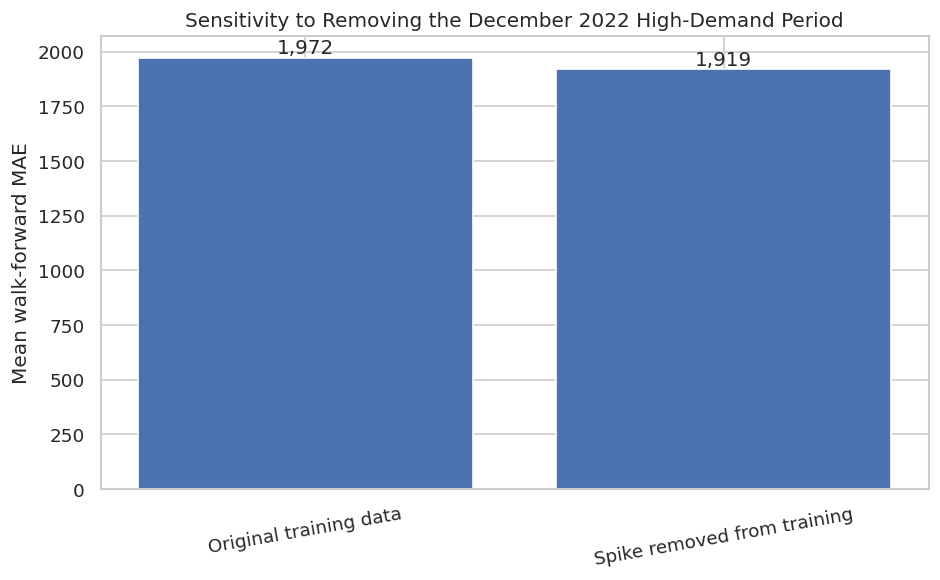

In [100]:
# December 2022 sensitivity chart

plt.figure(figsize=(8, 5))
bars = plt.bar(spike_sensitivity["Scenario"], spike_sensitivity["MAE_Mean"])

for bar, value in zip(bars, spike_sensitivity["MAE_Mean"]):
    plt.text(bar.get_x() + bar.get_width() / 2, value + 20, f"{value:,.0f}", ha="center")

plt.title("Sensitivity to Removing the December 2022 High-Demand Period")
plt.ylabel("Mean walk-forward MAE")
plt.xticks(rotation=10)
plt.tight_layout()
plt.savefig(Figures / "23_december_2022_sensitivity.png", dpi=180, bbox_inches="tight")
plt.show()

In [101]:
# Summarise December 2022 sensitivity

original_spike_mae = spike_sensitivity.loc[spike_sensitivity["Scenario"] == "Original training data", "MAE_Mean"].iloc[0]
removed_spike_mae = spike_sensitivity.loc[spike_sensitivity["Scenario"] == "Spike removed from training", "MAE_Mean"].iloc[0]
print("Original training MAE:", round(original_spike_mae, 2))
print("Spike-removed MAE:", round(removed_spike_mae, 2))
print("Difference:", round(removed_spike_mae - original_spike_mae, 2))

Original training MAE: 1971.6
Spike-removed MAE: 1919.43
Difference: -52.17


## **20.2 Flu Lag Check**

The main model uses flu positivity from 14 days earlier. This was chosen to reduce the risk of using flu information that may not have been available at the time of the forecast.

A 7 day flu lag is tested separately to see whether using a shorter delay changes the forecasting error.


In [102]:
# Compare 14-day and 7-day flu lags

features_flu_14 = ml_features.copy()
features_flu_7 = [f for f in ml_features if f != "flu_lag_14"] + ["flu_lag_7"]

flu14_fold, _ = run_ml_cv("Flu lag 14", best_boosting_type, best_boosting_params, features_flu_14)
flu7_fold, _ = run_ml_cv("Flu lag 7", best_boosting_type, best_boosting_params, features_flu_7)

flu_sensitivity = pd.DataFrame({
    "Scenario": ["14-day flu lag", "7-day flu lag"],
    "MAE_Mean": [flu14_fold["MAE"].mean(), flu7_fold["MAE"].mean()],
    "MAE_SD": [flu14_fold["MAE"].std(), flu7_fold["MAE"].std()]
})

display(flu_sensitivity.round(2))
flu_sensitivity.to_csv(Saved_Outputs / "flu_lag_sensitivity.csv", index=False)

,Scenario,MAE_Mean,MAE_SD
0,14-day flu lag,1971.6,738.18
1,7-day flu lag,2046.6,822.16


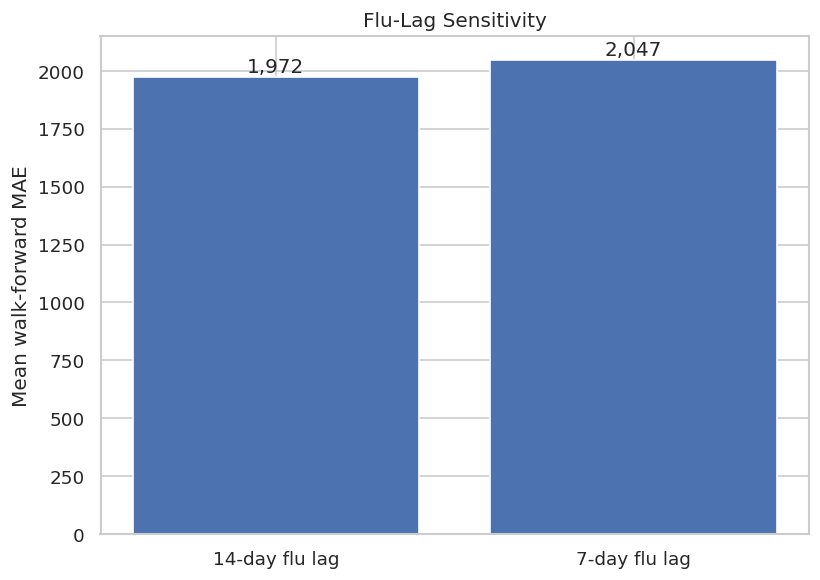

In [103]:
# Flu-lag sensitivity chart

plt.figure(figsize=(7, 5))
bars = plt.bar(flu_sensitivity["Scenario"], flu_sensitivity["MAE_Mean"])

for bar, value in zip(bars, flu_sensitivity["MAE_Mean"]):
    plt.text(bar.get_x() + bar.get_width() / 2, value + 20, f"{value:,.0f}", ha="center")

plt.title("Flu-Lag Sensitivity")
plt.ylabel("Mean walk-forward MAE")
plt.tight_layout()
plt.savefig(Figures / "24_flu_lag_sensitivity.png", dpi=180, bbox_inches="tight")
plt.show()

In [104]:
# Summarise flu-lag sensitivity

flu_best = flu_sensitivity.sort_values("MAE_Mean").iloc[0]
flu_other = flu_sensitivity.sort_values("MAE_Mean").iloc[1]
print("Better flu-lag scenario:", flu_best["Scenario"], round(flu_best["MAE_Mean"], 2))
print("Alternative scenario:", flu_other["Scenario"], round(flu_other["MAE_Mean"], 2))

Better flu-lag scenario: 14-day flu lag 1971.6
Alternative scenario: 7-day flu lag 2046.6


## **20.3 Partial Reporting Check**

The main test results do not score the dates that were already identified as partial NHS 111 reporting because the reported national total may be incomplete.

For comparison, the selected model is also scored against the raw reported totals for all test dates. This is shown only as a sensitivity check and is not used as the main accuracy result.


In [105]:
# Compare trusted-target scoring with all raw reported dates

complete_mask = test_predictions["model_A01"].notna()
all_reported_mask = test_predictions["reported_A01"].notna()

complete_metrics = forecast_metrics(test_predictions.loc[complete_mask, "model_A01"], test_predictions.loc[complete_mask, selected_model], test_mae_scale, test_mse_scale)
raw_metrics = forecast_metrics(test_predictions.loc[all_reported_mask, "reported_A01"], test_predictions.loc[all_reported_mask, selected_model], test_mae_scale, test_mse_scale)

partial_sensitivity = pd.DataFrame([
    ["Complete reporting dates only", int(complete_mask.sum()), complete_metrics["MAE"], complete_metrics["RMSE"]],
    ["All raw reported dates", int(all_reported_mask.sum()), raw_metrics["MAE"], raw_metrics["RMSE"]]
], columns=["Scenario", "Days", "MAE", "RMSE"])

display(partial_sensitivity.round(2))
partial_sensitivity.to_csv(Saved_Outputs / "partial_reporting_sensitivity.csv", index=False)

,Scenario,Days,MAE,RMSE
0,Complete reporting dates only,278,2023.53,3353.83
1,All raw reported dates,280,2067.70,3442.70


In [106]:
# Summarise partial-reporting sensitivity

complete_row = partial_sensitivity.iloc[0]
all_row = partial_sensitivity.iloc[1]
print("Complete-reporting dates MAE:", round(complete_row["MAE"], 2))
print("All raw reported dates MAE:", round(all_row["MAE"], 2))

Complete-reporting dates MAE: 2023.53
All raw reported dates MAE: 2067.7


## **20.4 May 2024 Level Change Check**

The training analysis identified a possible change in the average level of NHS 111 demand around 28 May 2024.

The selected boosting model is therefore compared using all of the available training history and using only observations after this date. The validation dates remain the same. This check uses training period information only and does not change the final model after the test results have been viewed.


In [107]:
# Sensitivity to the possible May 2024 level change

change_date = pd.Timestamp("2024-05-28")
change_rows = []

for label, recent_only in [("All available history", False), ("Post change history only", True)]:
    fold_scores = []

    for train_idx, val_idx in cv_splits:
        fold_train = train_calendar.iloc[train_idx].copy()
        fold_val = train_calendar.iloc[val_idx].copy()
        fit_data = fold_train[fold_train["model_A01"].notna()].copy()

        if recent_only:
            fit_data = fit_data[fit_data["Date"] > change_date].copy()

        model = build_ml_model(best_boosting_type, best_boosting_params)
        model.fit(fit_data[ml_features], fit_data["model_A01"])
        prediction = sequential_ml_predictions(model, fold_train, fold_val, ml_features)

        valid = fold_val["model_A01"].notna() & np.isfinite(prediction)
        fold_scores.append(mean_absolute_error(fold_val.loc[valid, "model_A01"], prediction[valid]))

    change_rows.append([label, np.mean(fold_scores), np.std(fold_scores)])

change_sensitivity = pd.DataFrame(change_rows, columns=["Scenario", "MAE_Mean", "MAE_SD"])
display(change_sensitivity.round(2))
change_sensitivity.to_csv(Saved_Outputs / "may_2024_level_change_sensitivity.csv", index=False)


,Scenario,MAE_Mean,MAE_SD
0,All available history,1971.60,660.25
1,Post change history only,2915.41,1685.45


# **21. Forecast Range**

A point forecast gives one predicted number of calls, but the actual number will not always be exactly the same. A 90% empirical forecast range is therefore added to show the amount of error seen in earlier one day ahead forecasts.

The range is based on the absolute CatBoost errors from the model comparison folds in the training period. For each test date, the range is calculated before the actual value for that date is used. Once that day's actual value is known, its error can be added to the past errors before the following day's range is calculated.

This is an empirical forecast range based on previous forecast errors. It is not treated as a guaranteed confidence interval.


In [108]:
# Build a sequential 90% empirical forecast range

selected_oof = comparison_oof[comparison_oof["Model"] == selected_model].copy()
initial_errors = np.abs(selected_oof["Actual"] - selected_oof["Predicted"]).dropna().to_numpy()

if len(initial_errors) == 0:
    raise ValueError("No development errors are available for the forecast range.")

def empirical_upper_quantile(values, level=0.90):
    values = np.sort(np.asarray(values, dtype=float))
    values = values[np.isfinite(values)]

    if len(values) == 0:
        return np.nan

    rank = int(np.ceil((len(values) + 1) * level))
    rank = min(max(rank, 1), len(values))
    return float(values[rank - 1])

range_errors = list(initial_errors)
lower_90 = []
upper_90 = []
range_widths = []

for _, row in test_predictions.sort_values("Date").iterrows():
    prediction = float(row[selected_model])
    half_width = empirical_upper_quantile(range_errors, 0.90)

    lower_90.append(max(0, prediction - half_width))
    upper_90.append(prediction + half_width)
    range_widths.append(half_width)

    if pd.notna(row["model_A01"]):
        range_errors.append(abs(float(row["model_A01"]) - prediction))

test_predictions = test_predictions.sort_values("Date").reset_index(drop=True)
test_predictions["Lower_90"] = lower_90
test_predictions["Upper_90"] = upper_90
test_predictions["Range_Half_Width"] = range_widths

coverage_mask = test_predictions["model_A01"].notna()
inside = (
    (test_predictions.loc[coverage_mask, "model_A01"] >= test_predictions.loc[coverage_mask, "Lower_90"]) &
    (test_predictions.loc[coverage_mask, "model_A01"] <= test_predictions.loc[coverage_mask, "Upper_90"])
)

interval_summary = pd.DataFrame({
    "Target_Coverage": [0.90],
    "Observed_Coverage": [inside.mean()],
    "Initial_Error_Count": [len(initial_errors)],
    "Median_Half_Width": [test_predictions.loc[coverage_mask, "Range_Half_Width"].median()],
    "Scored_Days": [int(coverage_mask.sum())]
})

display(interval_summary.round(4))

test_predictions.to_csv(Saved_Outputs / "final_test_predictions_with_intervals.csv", index=False)
interval_summary.to_csv(Saved_Outputs / "forecast_range_summary.csv", index=False)

,Target_Coverage,Observed_Coverage,Initial_Error_Count,Median_Half_Width,Scored_Days
0,0.9,0.8957,280,3988.6659,278


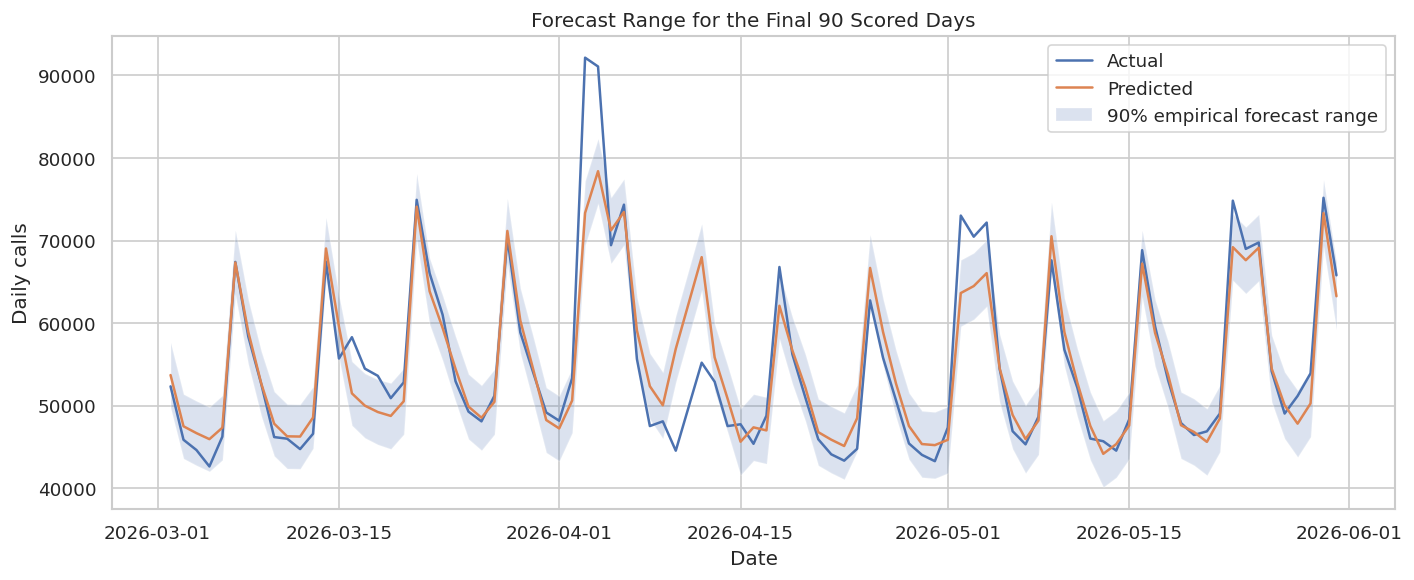

In [109]:
# Plot the final 90 scored days with the empirical forecast range

interval_plot = test_predictions[test_predictions["model_A01"].notna()].tail(90).copy()

plt.figure(figsize=(12, 5))
plt.plot(interval_plot["Date"], interval_plot["model_A01"], label="Actual")
plt.plot(interval_plot["Date"], interval_plot[selected_model], label="Predicted")
plt.fill_between(
    interval_plot["Date"],
    interval_plot["Lower_90"],
    interval_plot["Upper_90"],
    alpha=0.2,
    label="90% empirical forecast range"
)
plt.title("Forecast Range for the Final 90 Scored Days")
plt.xlabel("Date")
plt.ylabel("Daily calls")
plt.legend()
plt.tight_layout()
plt.savefig(Figures / "25_forecast_range.png", dpi=180, bbox_inches="tight")
plt.show()

In [110]:
# Check forecast range coverage

required_interval_columns = [
    "Target_Coverage",
    "Observed_Coverage",
    "Initial_Error_Count",
    "Median_Half_Width",
    "Scored_Days"
]

missing_interval_columns = [
    column for column in required_interval_columns
    if column not in interval_summary.columns
]

if missing_interval_columns:
    raise ValueError(f"Missing forecast range columns: {missing_interval_columns}")

interval_row = interval_summary.iloc[0]

print("Target coverage (%):", round(interval_row["Target_Coverage"] * 100, 1))
print("Observed coverage (%):", round(interval_row["Observed_Coverage"] * 100, 1))
print("Initial development errors:", int(interval_row["Initial_Error_Count"]))
print("Median range half width:", round(interval_row["Median_Half_Width"], 2))
print("Scored days:", int(interval_row["Scored_Days"]))

Target coverage (%): 90.0
Observed coverage (%): 89.6
Initial development errors: 280
Median range half width: 3988.67
Scored days: 278


# **22. Saving the Models and Final Outputs**

The selected forecasting model, the best boosting model, the final feature list and the main result files are saved to Google Drive.

The boosting model is also saved separately because it is used for the feature importance and SHAP analysis.


In [111]:
# Save the best boosting model

joblib.dump(interpretability_model, Models / "best_boosting_model.joblib")
joblib.dump(ml_features, Models / "ml_features.joblib")

# Save the pre-selected overall model

if selected_model in final_ml_models:
    selected_object = final_ml_models[selected_model]
elif selected_model == "Prophet":
    selected_object = final_prophet
elif selected_model == "SARIMAX":
    selected_object = final_sarimax_result
else:
    selected_object = None

if selected_object is not None:
    joblib.dump(selected_object, Models / "selected_forecasting_model.joblib")

selected_test_metrics = test_leaderboard[test_leaderboard["Model"] == selected_model].copy()

model_summary = pd.DataFrame({
    "Selected_Model": [selected_model],
    "Best_Boosting_Model": [best_boosting],
    "Forecast_Horizon": ["1 day ahead"],
    "Training_Start": [train_calendar["Date"].min()],
    "Training_End": [train_calendar["Date"].max()],
    "Test_Start": [test_calendar["Date"].min()],
    "Test_End": [test_calendar["Date"].max()],
    "Test_MAE": [selected_test_metrics["MAE"].iloc[0]],
    "Test_RMSE": [selected_test_metrics["RMSE"].iloc[0]],
    "Test_R2": [selected_test_metrics["R2"].iloc[0]],
    "Test_WAPE_pct": [selected_test_metrics["WAPE_pct"].iloc[0]],
    "Forecast_Range_Observed_Coverage": [inside.mean()]
})

display(model_summary.round(3))
model_summary.to_csv(Saved_Outputs / "final_model_summary.csv", index=False)

print("Models and final outputs saved to:", Saved_Outputs)

,Selected_Model,Best_Boosting_Model,Forecast_Horizon,Training_Start,Training_End,Test_Start,Test_End,Test_MAE,Test_RMSE,Test_R2,Test_WAPE_pct,Forecast_Range_Observed_Coverage
0,Tuned CatBoost,Tuned CatBoost,1 day ahead,2022-08-01,2025-08-24,2025-08-25,2026-05-31,2023.529,3353.832,0.898,3.654,0.896


Models and final outputs saved to: /content/drive/MyDrive/NHS111_Dissertation_Outputs


# **23. Streamlit Forecast App**

A simple Streamlit app is created to present the one day ahead forecasts in a clearer way.

The user selects a date and the app shows the predicted number of NHS 111 calls in England, the reported calls, the forecast error and the 90% empirical forecast range. A short chart is also included so the selected forecast can be viewed with the calls around that period.

The app is kept simple and does not display the technical model details on the main page.


In [112]:
# Create the Streamlit app

app_code = r'''
from pathlib import Path

import altair as alt
import pandas as pd
import streamlit as st

BASE = Path(__file__).parent

st.set_page_config(
    page_title="NHS 111 Call Forecast in England",
    page_icon="☎️",
    layout="centered"
)

st.markdown(
    """
    <style>
    .stApp {
        background: #ffffff;
        color: #111827;
    }

    .block-container {
        max-width: 920px;
        padding-top: 4.5rem;
        padding-bottom: 3rem;
    }

    h1, h2, h3, p, label {
        font-family: Arial, sans-serif;
        color: #111827;
    }

    .main-title {
        font-size: 2.15rem;
        font-weight: 700;
        margin-top: 1rem;
        margin-bottom: 0.35rem;
        color: #111827;
    }

    .subtitle {
        font-size: 1rem;
        color: #6b7280;
        margin-bottom: 1.8rem;
    }

    .forecast-card {
        background: #f8fbff;
        border: 1px solid #e4edf7;
        border-radius: 24px;
        padding: 28px;
        margin-top: 18px;
        margin-bottom: 18px;
        box-shadow: 0 8px 24px rgba(15, 23, 42, 0.06);
    }

    .date-label {
        color: #64748b;
        font-size: 0.95rem;
        margin-bottom: 6px;
    }

    .forecast-number {
        color: #0f172a;
        font-size: 3.2rem;
        font-weight: 750;
        line-height: 1.05;
        margin-top: 4px;
    }

    .forecast-label {
        color: #64748b;
        font-size: 1rem;
        margin-top: 5px;
    }

    .small-card {
        background: #ffffff;
        border: 1px solid #e7edf4;
        border-radius: 18px;
        padding: 18px;
        min-height: 118px;
        box-shadow: 0 4px 14px rgba(15, 23, 42, 0.04);
    }

    .small-label {
        color: #64748b;
        font-size: 0.88rem;
        margin-bottom: 6px;
    }

    .small-value {
        color: #111827;
        font-size: 1.45rem;
        font-weight: 700;
    }

    .small-note {
        color: #64748b;
        font-size: 0.78rem;
        margin-top: 5px;
    }

    .chart-title {
        color: #111111;
        font-size: 1.35rem;
        font-weight: 700;
        margin-top: 2rem;
        margin-bottom: 0.7rem;
    }

    div[data-baseweb="select"] > div {
        background: #ffffff;
        color: #111827;
        border-radius: 14px;
    }
    </style>
    """,
    unsafe_allow_html=True
)

prediction_file = BASE / "final_test_predictions_with_intervals.csv"

if not prediction_file.exists():
    st.error("Forecast results could not be found. Run the notebook cells that create the final results first.")
    st.stop()

pred = pd.read_csv(prediction_file, parse_dates=["Date"])

required = ["Date", "model_A01", "Lower_90", "Upper_90"]
missing = [column for column in required if column not in pred.columns]

if missing:
    st.error("The forecast results file is incomplete. Run the final notebook cells again.")
    st.stop()

summary_file = BASE / "final_model_summary.csv"

if summary_file.exists():
    summary = pd.read_csv(summary_file)
    selected_model = str(summary.loc[0, "Selected_Model"])
else:
    selected_model = "Tuned CatBoost"

if selected_model not in pred.columns:
    st.error("The selected forecast model is not available in the results file.")
    st.stop()

available = pred[
    pred["model_A01"].notna() &
    pred[selected_model].notna() &
    pred["Lower_90"].notna() &
    pred["Upper_90"].notna()
].copy()

available = available.sort_values("Date").reset_index(drop=True)

if available.empty:
    st.error("No complete forecast dates are available.")
    st.stop()

st.markdown(
    '<div class="main-title">NHS 111 Daily Call Forecast in England</div>',
    unsafe_allow_html=True
)

st.markdown(
    '<div class="subtitle">Choose a date to see the predicted and reported number of NHS 111 calls.</div>',
    unsafe_allow_html=True
)

date_labels = available["Date"].dt.strftime("%A %d %B %Y").tolist()

selected_text = st.selectbox(
    "Choose a date",
    date_labels,
    index=len(date_labels) - 1
)

selected_date = pd.to_datetime(
    selected_text,
    format="%A %d %B %Y"
)

row = available.loc[
    available["Date"] == selected_date
].iloc[0]

predicted = float(row[selected_model])
actual = float(row["model_A01"])
lower = float(row["Lower_90"])
upper = float(row["Upper_90"])

absolute_error = abs(actual - predicted)
percentage_error = 100 * absolute_error / actual if actual else 0

st.markdown(
    f"""
    <div class="forecast-card">
        <div class="date-label">{selected_date.strftime("%A %d %B %Y")}</div>
        <div class="forecast-number">{predicted:,.0f}</div>
        <div class="forecast-label">predicted calls</div>
    </div>
    """,
    unsafe_allow_html=True
)

col1, col2, col3 = st.columns(3)

with col1:
    st.markdown(
        f"""
        <div class="small-card">
            <div class="small-label">Reported calls</div>
            <div class="small-value">{actual:,.0f}</div>
            <div class="small-note">Actual calls recorded</div>
        </div>
        """,
        unsafe_allow_html=True
    )

with col2:
    st.markdown(
        f"""
        <div class="small-card">
            <div class="small-label">Forecast error</div>
            <div class="small-value">{absolute_error:,.0f}</div>
            <div class="small-note">{percentage_error:.1f}% of reported calls</div>
        </div>
        """,
        unsafe_allow_html=True
    )

with col3:
    st.markdown(
        f"""
        <div class="small-card">
            <div class="small-label">Expected range</div>
            <div class="small-value">{lower:,.0f} to {upper:,.0f}</div>
            <div class="small-note">90% empirical forecast range</div>
        </div>
        """,
        unsafe_allow_html=True
    )

st.markdown(
    '<div class="chart-title">Calls in this period</div>',
    unsafe_allow_html=True
)

chart_start = selected_date - pd.Timedelta(days=28)

chart = available[
    (available["Date"] >= chart_start) &
    (available["Date"] <= selected_date)
][["Date", "model_A01", selected_model]].copy()

chart = chart.rename(
    columns={
        "model_A01": "Reported calls",
        selected_model: "Predicted calls"
    }
)

chart_long = chart.melt(
    id_vars="Date",
    value_vars=["Reported calls", "Predicted calls"],
    var_name="Type",
    value_name="Calls"
)

calls_chart = (
    alt.Chart(chart_long)
    .mark_line(
        point=True,
        strokeWidth=2.5
    )
    .encode(
        x=alt.X(
            "Date:T",
            title=None,
            axis=alt.Axis(
                format="%d %b",
                labelColor="#111827",
                labelAngle=0,
                grid=False
            )
        ),
        y=alt.Y(
            "Calls:Q",
            title="Calls",
            scale=alt.Scale(zero=False),
            axis=alt.Axis(
                labelColor="#111827",
                titleColor="#111827",
                gridColor="#d7e9f7"
            )
        ),
        color=alt.Color(
            "Type:N",
            title=None,
            scale=alt.Scale(
                domain=["Reported calls", "Predicted calls"],
                range=["#111111", "#4da8e8"]
            ),
            legend=alt.Legend(
                orient="top",
                labelColor="#111827"
            )
        ),
        tooltip=[
            alt.Tooltip(
                "Date:T",
                title="Date",
                format="%A %d %B %Y"
            ),
            alt.Tooltip(
                "Type:N",
                title="Type"
            ),
            alt.Tooltip(
                "Calls:Q",
                title="Calls",
                format=","
            )
        ]
    )
  .properties(
    height=300,
    background="#f4f9ff"
)
.configure_view(
    stroke=None,
    fill="#f4f9ff"
)
)

st.altair_chart(
    calls_chart,
    use_container_width=True
)

st.caption(
    "The expected range is calculated from earlier one day ahead forecast errors. "
    "It is an empirical range and does not guarantee that every future value will fall inside it."
)
'''

app_path = Saved_Outputs / "streamlit_app.py"
app_path.write_text(app_code, encoding="utf-8")

print("Streamlit app saved to:", app_path)

Streamlit app saved to: /content/drive/MyDrive/NHS111_Dissertation_Outputs/streamlit_app.py


# **24. Final Research Outputs**

The final tables below bring together the three parts of the research question:

- how accurately daily NHS 111 demand can be forecast;
- whether the selected model improves on the seasonal baseline;
- which groups of factors contribute most to predictive performance.

The factor results must be interpreted as predictive associations rather than proof of causation.

In [113]:
# Final forecasting comparison

print("Selected model:")
print(selected_model)

print("\nFinal held-out performance:")
display(selected_test_metrics.round(3))

print("\nComparison with seasonal naive:")
display(test_leaderboard[test_leaderboard["Model"].isin([selected_model, "Seasonal Naive"])].round(3))

print("\nFeature-group influence:")
display(ablation_results.round(2))

print("\nTop SHAP features:")
display(shap_importance.head(10).round(3))

print("\nAll outputs saved to:")
print(Saved_Outputs)

# Save the frozen feature set used by the final boosting models

pd.DataFrame({"Selected_Feature": ml_features}).to_csv(
    Saved_Outputs / "final_selected_features.csv",
    index=False
)

print("Final selected feature count:", len(ml_features))


Selected model:
Tuned CatBoost

Final held-out performance:


,Model,Scored_Days,ME,MAE,RMSE,R2,MASE,RMSSE,WAPE_pct,MAE_Improvement_vs_Seasonal_Naive_pct
0,Tuned CatBoost,278,188.068,2023.529,3353.832,0.898,0.422,0.378,3.654,51.828



Comparison with seasonal naive:


,Model,Scored_Days,ME,MAE,RMSE,R2,MASE,RMSSE,WAPE_pct,MAE_Improvement_vs_Seasonal_Naive_pct
0,Tuned CatBoost,278,188.068,2023.529,3353.832,0.898,0.422,0.378,3.654,51.828
5,Seasonal Naive,278,280.489,4200.619,7120.953,0.539,0.877,0.803,7.585,0.000



Feature-group influence:


,Feature_Set,MAE_Mean,MAE_SD,MAE_Increase_vs_Full
0,Without demand history,2953.79,1877.64,982.19
1,Without calendar,2351.36,961.48,379.76
2,Without flu,2084.28,866.83,112.68
3,Full model,1971.60,738.18,0.00
4,Without weather,1937.52,730.24,-34.08



Top SHAP features:


,Feature,Mean_Abs_SHAP
0,lag_7,2770.356
1,day_of_week,2003.806
2,is_weekend,1527.444
3,lag_1,1265.170
4,weekly_change,1058.069
5,lag_21,1054.797
6,bank_holiday,579.633
7,trend_index,565.528
8,rolling_mean_7,512.786
9,lag_2,440.413



All outputs saved to:
/content/drive/MyDrive/NHS111_Dissertation_Outputs
Final selected feature count: 31


In [114]:
# Final result summary

selected_row = test_leaderboard[test_leaderboard["Model"] == selected_model].iloc[0]
numeric_best = test_leaderboard.iloc[0]
print("FINAL RESULT SUMMARY")
print("Selected model:", selected_model)
print("Held-out MAE:", round(selected_row["MAE"], 2))
print("Held-out RMSE:", round(selected_row["RMSE"], 2))
print("Held-out R2:", round(selected_row["R2"], 3))
print("Held-out WAPE (%):", round(selected_row["WAPE_pct"], 2))
print("Lowest numerical held-out MAE:", numeric_best["Model"], round(numeric_best["MAE"], 2))
print("See the tables and figures above for feature contribution, sensitivity and residual diagnostics.")


FINAL RESULT SUMMARY
Selected model: Tuned CatBoost
Held-out MAE: 2023.53
Held-out RMSE: 3353.83
Held-out R2: 0.898
Held-out WAPE (%): 3.65
Lowest numerical held-out MAE: Tuned CatBoost 2023.53
See the tables and figures above for feature contribution, sensitivity and residual diagnostics.


# **Method Used for the Final Analysis**

The modelling stages are separated by date. Feature screening is completed first, followed by tuning, model comparison and the final held out test.

All models answer the same one day ahead forecasting question. MAE is used as the main error measure. RMSE, Mean Error, R², MASE, RMSSE and WAPE are also reported to describe different parts of the forecast performance.

The final error analysis and sensitivity checks are used to explain where the selected model performs well and where larger errors remain.


# **End of Notebook**

This workflow keeps data preparation, chronological model development, final testing, interpretability and sensitivity analysis separate.

The final comparison uses a one-day-ahead forecasting design. Prophet, SARIMAX, the seasonal baseline and boosting models therefore answer the same operational question.

Known reporting-quality problems remain transparent. Same-day observed weather, same-day flu values and post-reporting quality information are excluded from the forecasting features.

Any large holiday errors or remaining residual autocorrelation found after final testing are reported as limitations and future work rather than being used to retrospectively improve the model.

# **Final App Design**

The app is designed to make the forecast easy to read without showing unnecessary technical information.

The selected date is shown with the predicted number of calls. The reported calls, forecast error and expected range are displayed underneath. The chart shows reported and predicted calls around the selected period so the forecast can be viewed in context.

Only dates with complete reported NHS 111 values are available for selection.


# **25. Launch the Streamlit App**

The first cell starts the Streamlit app in Google Colab.

The second cell creates a temporary link that can be opened in a browser.


In [115]:
# Start Streamlit in Google Colab

!pkill -f "streamlit run" || true
!streamlit run "/content/drive/MyDrive/NHS111_Dissertation_Outputs/streamlit_app.py" --server.port 8501 --server.headless true > /content/streamlit.log 2>&1 &
!sleep 3

print("Streamlit server started.")

^C
Streamlit server started.


In [ ]:
# Create the temporary public link

print("Tunnel password:")
!curl -s https://loca.lt/mytunnelpassword

print("\nOpen the loca.lt link printed below:")
!npx --yes localtunnel --port 8501

Tunnel password:
104.155.185.128
Open the loca.lt link printed below:
⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴your url is: https://salty-sites-wear.loca.lt
